# Очистка и подготовка user-course датасета для моделирования статуса

Этот ноутбук собирает рабочую основу для модельного датасета на уровне `user-course`.

Документ устроен так:

- сначала загружаются и типизируются основные таблицы LMS;
- затем проверяются ключи, связность, дубликаты и базовые аномалии;
- после этого строятся агрегаты по сырым логам до уровня `user-course`;
- в конце формируется единая витрина для следующего этапа feature engineering и обучения модели.

Важно: в этом ноутбуке не обрабатываются сырые `stats__module_*`. Вместо них используется уже подготовленная объединённая таблица `./modules/status_modules_complete.csv`, которая задаёт population на уровне модульного `user-course`, содержит фактический статус там, где он уже известен, и даёт лучшую эвристику статуса для модулей `1-3`.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from sksurv.ensemble import RandomSurvivalForest
from sksurv.util import Surv
from sklearn.metrics import (
    roc_auc_score,
    confusion_matrix,
    roc_curve,
    classification_report,
    f1_score,
)
from catboost import CatBoostClassifier, Pool

from sksurv.linear_model import CoxPHSurvivalAnalysis

from sklearn.feature_selection import mutual_info_classif


pd.options.display.max_columns = 200
pd.options.display.max_rows = 200


def resolve_base_dir() -> Path:
    candidates = [Path.cwd(), Path.cwd() / "hackathon"]
    for candidate in candidates:
        if (candidate / "src").exists() and (candidate / "modules").exists():
            return candidate.resolve()
    raise FileNotFoundError(
        "Не удалось найти папки ./src и ./modules относительно текущего ноутбука. "
        "Откройте ноутбук из каталога hackathon или проверьте рабочую директорию."
    )


BASE_DIR = resolve_base_dir()
SRC_DIR = BASE_DIR / "src"
MODULES_DIR = BASE_DIR / "modules"
OUTPUT_DIR = BASE_DIR / "artifacts"
OUTPUT_DIR.mkdir(exist_ok=True)

CSV_KWARGS = {
    "thousands": ",",
    "true_values": ["True"],
    "false_values": ["False"],
}


def read_typed_csv(
    path: Path,
    *,
    usecols: list[str],
    numeric_cols: dict[str, str] | None = None,
    bool_cols: list[str] | None = None,
    category_cols: list[str] | None = None,
    datetime_cols: dict[str, str] | None = None,
    extra_csv_kwargs: dict | None = None,
) -> pd.DataFrame:
    read_kwargs = dict(CSV_KWARGS)
    if extra_csv_kwargs:
        read_kwargs.update(extra_csv_kwargs)

    df = pd.read_csv(path, usecols=usecols, **read_kwargs)

    for col, fmt in (datetime_cols or {}).items():
        df[col] = pd.to_datetime(df[col], format=fmt, errors="coerce")

    for col, dtype in (numeric_cols or {}).items():
        df[col] = pd.to_numeric(df[col], errors="coerce").astype(dtype)

    for col in (bool_cols or []):
        df[col] = df[col].astype("boolean")

    for col in (category_cols or []):
        df[col] = df[col].astype("category")

    return df



def bool_sum(series: pd.Series) -> int:
    return int(series.fillna(False).astype("int8").sum())


def pct(numerator: int, denominator: int) -> float:
    return round(numerator / denominator * 100, 2) if denominator else np.nan


def fk_report(name: str, child: pd.Series, parent: pd.Series) -> dict:
    child_non_null = child.dropna()
    parent_index = pd.Index(parent.dropna().unique())
    total = int(child_non_null.shape[0])
    matched = int(child_non_null.isin(parent_index).sum())
    return {
        "check": name,
        "rows_checked": total,
        "matched_rows": matched,
        "unmatched_rows": total - matched,
        "coverage_pct": pct(matched, total),
    }




## Что именно загружаем и почему

Здесь читаются только те таблицы, которые реально помогают собрать витрину на уровне `user-course` или нужны для контроля качества связей.

Осознанные решения:

- `stats__module_*` исключены из ноутбука полностью: они обрабатываются отдельно;
- объединённый `modules/status_modules_complete.csv` используется как модульная population-таблица и источник фактического/эвристического статуса;
- загружаются только те поля, которые нужны для диагностики качества или дальнейших user-course агрегатов;
- таблицы наград здесь не используются: они не course-specific и легко создают риск временной утечки.

Ниже мы сначала подготавливаем typed DataFrame-ы, а затем строим признаки из сырых логов LMS.


In [2]:
users_df = read_typed_csv(
    SRC_DIR / "users.csv",
    usecols=[
        "id",
        "created_at",
        "updated_at",
        "sign_in_count",
        "last_sign_in_at",
        "timezone",
        "xp",
    ],
    numeric_cols={
        "id": "Int32",
        "sign_in_count": "Int16",
        "xp": "Int32",
    },
    category_cols=["timezone"],
    datetime_cols={
        "created_at": "%d %b, %Y, %H:%M",
        "updated_at": "%d %b, %Y, %H:%M",
        "last_sign_in_at": "%d %b, %Y, %H:%M",
    },
)

users_courses_df = read_typed_csv(
    SRC_DIR / "users_courses.csv",
    usecols=[
        "id",
        "user_id",
        "course_id",
        "created_at",
        "updated_at",
        "access_finished_at",
        "wk_points",
        "wk_max_points",
        "wk_max_task_count",
    ],
    numeric_cols={
        "id": "Int32",
        "user_id": "Int32",
        "course_id": "Int32",
        "wk_points": "Float32",
        "wk_max_points": "Float32",
        "wk_max_task_count": "Float32",
    },
    datetime_cols={
        "created_at": "%d %b, %Y, %H:%M",
        "updated_at": "%d %b, %Y, %H:%M",
        "access_finished_at": "%d %b, %Y",
    },
)
users_courses_df = users_courses_df.rename(columns={"id": "users_course_id"})

lessons_df = read_typed_csv(
    SRC_DIR / "lessons.csv",
    usecols=[
        "id",
        "course_id",
        "conspect_expected",
        "task_expected",
        "lesson_number",
        "wk_survival_training_expected",
        "wk_attendance_tracking_enabled",
        "wk_video_duration",
    ],
    numeric_cols={
        "id": "Int32",
        "course_id": "Int32",
        "lesson_number": "Int16",
        "wk_video_duration": "Float32",
    },
    bool_cols=[
        "conspect_expected",
        "task_expected",
        "wk_survival_training_expected",
        "wk_attendance_tracking_enabled",
    ],
)
lessons_df = lessons_df.rename(columns={"id": "lesson_id"})

groups_df = read_typed_csv(
    SRC_DIR / "groups.csv",
    usecols=[
        "id",
        "lesson_id",
        "duration",
        "group_template_id",
        "wk_actual_started_at",
        "wk_actual_finished_at",
    ],
    numeric_cols={
        "id": "Int32",
        "lesson_id": "Int32",
        "duration": "Int16",
        "group_template_id": "Int32",
    },
    datetime_cols={
        "wk_actual_started_at": "%d %b, %Y, %H:%M",
        "wk_actual_finished_at": "%d %b, %Y, %H:%M",
    },
)
groups_df = groups_df.rename(columns={"id": "group_id"})

trainings_df = read_typed_csv(
    SRC_DIR / "trainings.csv",
    usecols=["id", "lesson_id", "task_templates_count"],
    numeric_cols={
        "id": "Int32",
        "lesson_id": "Int32",
        "task_templates_count": "Int16",
    },
)
trainings_df = trainings_df.rename(columns={"id": "training_id"})

lesson_tasks_df = read_typed_csv(
    SRC_DIR / "lesson_tasks.csv",
    usecols=["id", "lesson_id", "task_id", "position", "task_required"],
    numeric_cols={
        "id": "Int32",
        "lesson_id": "Int32",
        "task_id": "Int32",
        "position": "Int16",
    },
    bool_cols=["task_required"],
)

homeworks_df = read_typed_csv(
    SRC_DIR / "homeworks.csv",
    usecols=["id", "resource_type", "resource_id"],
    numeric_cols={"id": "Int32", "resource_id": "Int32"},
    category_cols=["resource_type"],
)
homeworks_df = homeworks_df.rename(columns={"id": "homework_id"})

homework_items_df = read_typed_csv(
    SRC_DIR / "homework_items.csv",
    usecols=["id", "homework_id", "resource_id", "position"],
    numeric_cols={
        "id": "Int32",
        "homework_id": "Int32",
        "resource_id": "Int32",
        "position": "Int16",
    },
)

user_access_histories_df = read_typed_csv(
    SRC_DIR / "user_access_histories.csv",
    usecols=["users_course_id", "access_started_at", "access_expired_at", "activator_class"],
    numeric_cols={"users_course_id": "Int32"},
    category_cols=["activator_class"],
    datetime_cols={
        "access_started_at": "%d %b, %Y",
        "access_expired_at": "%d %b, %Y",
    },
)

user_lessons_df = read_typed_csv(
    SRC_DIR / "user_lessons.csv",
    usecols=[
        "id",
        "user_id",
        "lesson_id",
        "group_id",
        "video_visited",
        "video_viewed",
        "translation_visited",
        "users_course_id",
        "solved",
        "solved_tasks_count",
        "wk_points",
        "wk_solved_task_count",
    ],
    numeric_cols={
        "id": "Int32",
        "user_id": "Int32",
        "lesson_id": "Int32",
        "group_id": "Int32",
        "users_course_id": "Int32",
        "solved_tasks_count": "Int16",
        "wk_points": "Float32",
        "wk_solved_task_count": "Int16",
    },
    bool_cols=["video_visited", "video_viewed", "translation_visited", "solved"],
)
user_lessons_df = user_lessons_df.rename(columns={"id": "user_lesson_id"})

user_activity_histories_df = read_typed_csv(
    SRC_DIR / "user_activity_histories.csv",
    usecols=["user_lesson_id", "action", "created_at"],
    numeric_cols={"user_lesson_id": "Int32"},
    category_cols=["action"],
    datetime_cols={"created_at": "%Y-%m-%d %H:%M:%S"},
)

user_answers_df = read_typed_csv(
    SRC_DIR / "user_answers.csv",
    usecols=[
        "user_id",
        "task_id",
        "attempts",
        "solved",
        "points",
        "max_attempts",
        "skipped",
        "resource_type",
        "resource_id",
        "submitted_at",
        "wk_partial_answer",
        "async_check_status",
    ],
    numeric_cols={
        "user_id": "Int32",
        "task_id": "Int32",
        "attempts": "Int16",
        "points": "Float32",
        "max_attempts": "Int16",
        "resource_id": "Int32",
        "async_check_status": "Int8",
    },
    bool_cols=["solved", "skipped", "wk_partial_answer"],
    category_cols=["resource_type"],
    datetime_cols={"submitted_at": "%Y-%m-%d %H:%M:%S"},
)

user_trainings_df = read_typed_csv(
    SRC_DIR / "user_trainings.csv",
    usecols=[
        "user_id",
        "training_id",
        "solved_tasks_count",
        "earned_points",
        "submitted_answers_count",
        "started_at",
        "finished_at",
        "attempts",
        "mark",
    ],
    numeric_cols={
        "user_id": "Int32",
        "training_id": "Int32",
        "solved_tasks_count": "Int16",
        "earned_points": "Float32",
        "submitted_answers_count": "Int16",
        "attempts": "Int16",
        "mark": "Float32",
    },
    datetime_cols={
        "started_at": "%d %b, %Y, %H:%M",
        "finished_at": "%d %b, %Y, %H:%M",
    },
)

wk_users_courses_actions_df = read_typed_csv(
    SRC_DIR / "wk_users_courses_actions.csv",
    usecols=["user_id", "users_course_id", "action", "created_at", "updated_at", "lesson_id"],
    numeric_cols={"user_id": "Int32", "users_course_id": "Int32", "lesson_id": "Int32"},
    category_cols=["action"],
    datetime_cols={
        "created_at": "%Y-%m-%d %H:%M:%S",
        "updated_at": "%Y-%m-%d %H:%M:%S",
    },
)

wk_media_view_sessions_df = read_typed_csv(
    SRC_DIR / "wk_media_view_sessions.csv",
    usecols=["resource_type", "resource_id", "viewer_id", "segments_total", "viewed_segments_count", "started_at", "kind"],
    numeric_cols={
        "resource_id": "Int32",
        "viewer_id": "Int32",
        "segments_total": "Int16",
        "viewed_segments_count": "Int16",
    },
    category_cols=["resource_type", "kind"],
    datetime_cols={"started_at": "%d %b, %Y, %H:%M"},
)

modules_status_df = read_typed_csv(
    MODULES_DIR / "status_modules_complete.csv",
    usecols=[
        "module",
        "user_id",
        "club_name",
        "teacher_id",
        "course_id",
        "cohort_id",
        "level_bin",
        "enrollment_date",
        "status_actual",
        "status_by_best_heuristic",
    ],
    numeric_cols={
        "module": "Int8",
        "user_id": "Int32",
        "teacher_id": "Int32",
        "course_id": "Int32",
        "cohort_id": "Int32",
        "level_bin": "Int8",
    },
    category_cols=["club_name", "status_actual", "status_by_best_heuristic"],
    datetime_cols={"enrollment_date": "%Y-%m-%d"},
)

dataframes = {
    "users_df": users_df,
    "users_courses_df": users_courses_df,
    "lessons_df": lessons_df,
    "groups_df": groups_df,
    "trainings_df": trainings_df,
    "lesson_tasks_df": lesson_tasks_df,
    "homeworks_df": homeworks_df,
    "homework_items_df": homework_items_df,
    "user_access_histories_df": user_access_histories_df,
    "user_lessons_df": user_lessons_df,
    "user_activity_histories_df": user_activity_histories_df,
    "user_answers_df": user_answers_df,
    "user_trainings_df": user_trainings_df,
    "wk_users_courses_actions_df": wk_users_courses_actions_df,
    "wk_media_view_sessions_df": wk_media_view_sessions_df,
    "modules_status_df": modules_status_df,
}

inventory_df = pd.DataFrame(
    {
        "dataframe": list(dataframes.keys()),
        "rows": [df.shape[0] for df in dataframes.values()],
        "cols": [df.shape[1] for df in dataframes.values()],
    }
)

display(inventory_df.sort_values(["rows", "cols"], ascending=[False, False]).reset_index(drop=True))
display(modules_status_df.head())


,dataframe,rows,cols
0,user_answers_df,15176182,12
1,wk_users_courses_actions_df,12909207,6
2,user_lessons_df,3070664,12
3,user_activity_histories_df,3031137,3
4,wk_media_view_sessions_df,852358,7
5,user_access_histories_df,667124,4
6,user_trainings_df,427628,9
7,users_courses_df,290835,9
8,users_df,95395,7
9,lesson_tasks_df,29544,5


,module,user_id,club_name,teacher_id,course_id,cohort_id,level_bin,enrollment_date,status_actual,status_by_best_heuristic
0,1,701741,Python. Начальный уровень. Онлайн. 1 модуль,699869,1029,1149,0,2025-09-19,Завершил,Completed
1,1,737977,Python. Начальный уровень. Онлайн. 1 модуль,730341,1029,1216,0,2025-11-05,Завершил,Completed
2,1,722851,Python. Базовый уровень. Онлайн. 1 модуль,730208,1030,1186,1,2025-10-21,Отчислен,Dropped
3,1,709724,Python. Базовый уровень. Онлайн. 1 модуль,700089,1030,1108,1,2025-09-23,Завершил,Completed
4,1,717763,Python. Базовый уровень. Онлайн. 1 модуль,718519,1030,1055,1,2025-10-09,Отчислен,Dropped


## Первичная проверка качества

На этом шаге важно не просто посмотреть `shape`, а зафиксировать, что именно можно использовать как надёжную связь для user-course агрегатов.

Проверяем четыре группы вопросов:

- грубые дубликаты и нарушения ключей;
- покрытие FK между таблицами;
- временные аномалии и базовые sanity-checks;
- качество сигналов просмотра, событий внутри урока и стыковку `modules/status_modules_complete.csv` с `users_courses`.


In [3]:
duplicate_rows_df = pd.DataFrame(
    {
        "dataframe": list(dataframes.keys()),
        "duplicate_rows": [int(df.duplicated().sum()) for df in dataframes.values()],
        "rows": [df.shape[0] for df in dataframes.values()],
    }
)
duplicate_rows_df["duplicate_share_pct"] = (
    duplicate_rows_df["duplicate_rows"] / duplicate_rows_df["rows"] * 100
).round(2)

key_uniqueness_df = pd.DataFrame(
    [
        {"table": "users_df", "key": "user_id", "duplicates": int(users_df.duplicated(["id"]).sum())},
        {"table": "users_courses_df", "key": "users_course_id", "duplicates": int(users_courses_df.duplicated(["users_course_id"]).sum())},
        {"table": "users_courses_df", "key": "(user_id, course_id)", "duplicates": int(users_courses_df.duplicated(["user_id", "course_id"]).sum())},
        {"table": "lessons_df", "key": "lesson_id", "duplicates": int(lessons_df.duplicated(["lesson_id"]).sum())},
        {"table": "groups_df", "key": "group_id", "duplicates": int(groups_df.duplicated(["group_id"]).sum())},
        {"table": "trainings_df", "key": "training_id", "duplicates": int(trainings_df.duplicated(["training_id"]).sum())},
        {"table": "lesson_tasks_df", "key": "id", "duplicates": int(lesson_tasks_df.duplicated(["id"]).sum())},
        {"table": "homeworks_df", "key": "homework_id", "duplicates": int(homeworks_df.duplicated(["homework_id"]).sum())},
        {"table": "homework_items_df", "key": "id", "duplicates": int(homework_items_df.duplicated(["id"]).sum())},
        {"table": "user_lessons_df", "key": "user_lesson_id", "duplicates": int(user_lessons_df.duplicated(["user_lesson_id"]).sum())},
        {"table": "user_lessons_df", "key": "(user_id, users_course_id, lesson_id)", "duplicates": int(user_lessons_df.duplicated(["user_id", "users_course_id", "lesson_id"]).sum())},
        {"table": "user_activity_histories_df", "key": "(user_lesson_id, action, created_at)", "duplicates": int(user_activity_histories_df.duplicated(["user_lesson_id", "action", "created_at"]).sum())},
        {"table": "modules_status_df", "key": "(module, user_id, course_id)", "duplicates": int(modules_status_df.duplicated(["module", "user_id", "course_id"]).sum())},
    ]
)

fk_checks_df = pd.DataFrame(
    [
        fk_report("users_courses.user_id -> users.id", users_courses_df["user_id"], users_df["id"]),
        fk_report("user_lessons.user_id -> users.id", user_lessons_df["user_id"], users_df["id"]),
        fk_report("user_lessons.users_course_id -> users_courses.users_course_id", user_lessons_df["users_course_id"], users_courses_df["users_course_id"]),
        fk_report("user_lessons.lesson_id -> lessons.lesson_id", user_lessons_df["lesson_id"], lessons_df["lesson_id"]),
        fk_report("user_lessons.group_id -> groups.group_id", user_lessons_df["group_id"], groups_df["group_id"]),
        fk_report("user_activity_histories.user_lesson_id -> user_lessons.user_lesson_id", user_activity_histories_df["user_lesson_id"], user_lessons_df["user_lesson_id"]),
        fk_report("groups.lesson_id -> lessons.lesson_id", groups_df["lesson_id"], lessons_df["lesson_id"]),
        fk_report("trainings.lesson_id -> lessons.lesson_id", trainings_df["lesson_id"], lessons_df["lesson_id"]),
        fk_report("user_trainings.training_id -> trainings.training_id", user_trainings_df["training_id"], trainings_df["training_id"]),
        fk_report("wk_media_view_sessions.viewer_id -> users.id", wk_media_view_sessions_df["viewer_id"], users_df["id"]),
        fk_report(
            "wk_media_view_sessions.resource_id[Group] -> groups.group_id",
            wk_media_view_sessions_df.loc[wk_media_view_sessions_df["resource_type"].eq("Group"), "resource_id"],
            groups_df["group_id"],
        ),
        fk_report(
            "wk_media_view_sessions.resource_id[Lesson] -> lessons.lesson_id",
            wk_media_view_sessions_df.loc[wk_media_view_sessions_df["resource_type"].eq("Lesson"), "resource_id"],
            lessons_df["lesson_id"],
        ),
        fk_report("user_answers.user_id -> users.id", user_answers_df["user_id"], users_df["id"]),
        fk_report("modules_status.user_id -> users.id", modules_status_df["user_id"], users_df["id"]),
        fk_report("modules_status.course_id -> lessons.course_id", modules_status_df["course_id"], lessons_df["course_id"]),
        fk_report("modules_status.cohort_id -> groups.group_template_id", modules_status_df["cohort_id"], groups_df["group_template_id"]),
    ]
)

temporal_checks_df = pd.DataFrame(
    [
        {"table": "users_df", "check": "updated_at < created_at", "bad_rows": int((users_df["updated_at"] < users_df["created_at"]).sum())},
        {"table": "users_courses_df", "check": "updated_at < created_at", "bad_rows": int((users_courses_df["updated_at"] < users_courses_df["created_at"]).sum())},
        {"table": "users_courses_df", "check": "wk_points > wk_max_points", "bad_rows": int((users_courses_df["wk_points"] > users_courses_df["wk_max_points"]).sum())},
        {"table": "groups_df", "check": "wk_actual_finished_at < wk_actual_started_at", "bad_rows": int((groups_df["wk_actual_finished_at"] < groups_df["wk_actual_started_at"]).sum())},
        {"table": "lessons_df", "check": "lesson_number <= 0", "bad_rows": int((lessons_df["lesson_number"] <= 0).sum())},
        {"table": "lesson_tasks_df", "check": "position <= 0", "bad_rows": int((lesson_tasks_df["position"] <= 0).sum())},
        {"table": "homework_items_df", "check": "position <= 0", "bad_rows": int((homework_items_df["position"] <= 0).sum())},
        {"table": "user_answers_df", "check": "attempts > max_attempts", "bad_rows": int((user_answers_df["attempts"] > user_answers_df["max_attempts"]).sum())},
        {"table": "user_trainings_df", "check": "finished_at < started_at", "bad_rows": int((user_trainings_df["finished_at"] < user_trainings_df["started_at"]).sum())},
        {"table": "wk_users_courses_actions_df", "check": "updated_at < created_at", "bad_rows": int((wk_users_courses_actions_df["updated_at"] < wk_users_courses_actions_df["created_at"]).sum())},
        {"table": "wk_media_view_sessions_df", "check": "viewed_segments_count > segments_total", "bad_rows": int((wk_media_view_sessions_df["viewed_segments_count"] > wk_media_view_sessions_df["segments_total"]).sum())},
    ]
)

video_signal_df = pd.DataFrame(
    [
        {"metric": "rows_video_visited_true", "value": int(user_lessons_df["video_visited"].fillna(False).sum())},
        {"metric": "rows_video_viewed_true", "value": int(user_lessons_df["video_viewed"].fillna(False).sum())},
        {"metric": "video_visited_true_and_video_viewed_false", "value": int(((user_lessons_df["video_visited"] == True) & (user_lessons_df["video_viewed"] == False)).sum())},
        {"metric": "video_viewed_true_and_video_visited_false", "value": int(((user_lessons_df["video_viewed"] == True) & (user_lessons_df["video_visited"] == False)).sum())},
    ]
)

modules_backbone_df = modules_status_df.merge(
    users_courses_df[["users_course_id", "user_id", "course_id"]],
    on=["user_id", "course_id"],
    how="left",
)
module_users_course_coverage_df = (
    modules_backbone_df
    .groupby("module", dropna=False)
    .agg(
        rows=("module", "size"),
        matched_users_course=("users_course_id", lambda s: int(s.notna().sum())),
        unmatched_users_course=("users_course_id", lambda s: int(s.isna().sum())),
    )
    .reset_index()
)
module_users_course_coverage_df["matched_pct"] = module_users_course_coverage_df.apply(
    lambda row: pct(int(row["matched_users_course"]), int(row["rows"])),
    axis=1,
)

display(duplicate_rows_df.sort_values("duplicate_rows", ascending=False).reset_index(drop=True))
display(key_uniqueness_df)
display(fk_checks_df.sort_values("coverage_pct", ascending=True).reset_index(drop=True))
display(temporal_checks_df.sort_values(["bad_rows", "table"], ascending=[False, True]).reset_index(drop=True))
display(video_signal_df)
display(module_users_course_coverage_df)


,dataframe,duplicate_rows,rows,duplicate_share_pct
0,wk_users_courses_actions_df,5491157,12909207,42.54
1,user_answers_df,4950084,15176182,32.62
2,user_access_histories_df,355372,667124,53.27
3,user_activity_histories_df,33312,3031137,1.10
4,wk_media_view_sessions_df,3558,852358,0.42
5,users_df,0,95395,0.00
6,lessons_df,0,3369,0.00
7,users_courses_df,0,290835,0.00
8,homework_items_df,0,5901,0.00
9,homeworks_df,0,1226,0.00


,table,key,duplicates
0,users_df,user_id,0
1,users_courses_df,users_course_id,0
2,users_courses_df,"(user_id, course_id)",0
3,lessons_df,lesson_id,0
4,groups_df,group_id,0
5,trainings_df,training_id,0
6,lesson_tasks_df,id,0
7,homeworks_df,homework_id,0
8,homework_items_df,id,0
9,user_lessons_df,user_lesson_id,0


,check,rows_checked,matched_rows,unmatched_rows,coverage_pct
0,trainings.lesson_id -> lessons.lesson_id,256,252,4,98.44
1,user_activity_histories.user_lesson_id -> user...,3031137,3007406,23731,99.22
2,user_lessons.lesson_id -> lessons.lesson_id,3070664,3062469,8195,99.73
3,user_lessons.group_id -> groups.group_id,3070664,3062469,8195,99.73
4,groups.lesson_id -> lessons.lesson_id,13076,13068,8,99.94
5,user_lessons.users_course_id -> users_courses....,3070664,3070524,140,100.00
6,users_courses.user_id -> users.id,290835,290835,0,100.00
7,user_lessons.user_id -> users.id,3070664,3070615,49,100.00
8,user_trainings.training_id -> trainings.traini...,427628,427628,0,100.00
9,wk_media_view_sessions.viewer_id -> users.id,852358,852358,0,100.00


,table,check,bad_rows
0,user_answers_df,attempts > max_attempts,190
1,users_courses_df,wk_points > wk_max_points,179
2,wk_users_courses_actions_df,updated_at < created_at,1
3,groups_df,wk_actual_finished_at < wk_actual_started_at,0
4,homework_items_df,position <= 0,0
5,lesson_tasks_df,position <= 0,0
6,lessons_df,lesson_number <= 0,0
7,user_trainings_df,finished_at < started_at,0
8,users_courses_df,updated_at < created_at,0
9,users_df,updated_at < created_at,0


,metric,value
0,rows_video_visited_true,2471536
1,rows_video_viewed_true,99650
2,video_visited_true_and_video_viewed_false,2371889
3,video_viewed_true_and_video_visited_false,3


,module,rows,matched_users_course,unmatched_users_course,matched_pct
0,1,2972,2972,0,100.0
1,2,1955,1955,0,100.0
2,3,1785,1785,0,100.0
3,4,1689,0,1689,0.0


## Интерпретация промежуточных результатов

Здесь важно зафиксировать несколько практических выводов, которые будут влиять на итоговую витрину.

1. `video_viewed` действительно нужен.
   В текущих данных огромное число строк имеет `video_visited=True`, но `video_viewed=False`. Это означает, что одного признака захода в видео недостаточно: для модели важнее отделять факт открытия плеера от фактического просмотра.

2. `user_activity_histories` можно связать с `user_lessons` по `user_lesson_id`.
   Это позволяет использовать события внутри урока не только для ручной проверки, но и для построения user-course агрегатов. При этом покрытие по `course_id` всё равно чуть ниже 100%, потому что часть `user_lessons` не стыкуется с `lessons`, и это ограничение надо помнить при интерпретации признаков.

3. Для модулей 1, 2 и 3 записи из `modules/status_modules_complete.csv` хорошо стыкуются с `users_courses`, а для модуля 4 такого совпадения нет.
   Поэтому итоговую витрину нельзя строить только через `users_course_id`.
   В этом документе используется смешанный подход: где связь с `users_courses` есть, берём её напрямую; где её нет, восстанавливаем принадлежность к курсу через уроки, группы, тренинги и типы ресурсов в логах.


## Удаление точных дублей перед сборкой витрины

На этом шаге удаляются дубли событий в тех таблицах, где они завышают агрегаты.

В том числе дедуплицируется `user_activity_histories_df` по ключу `(user_lesson_id, action, created_at)`: именно в этой таблице точные повторы особенно заметно завышают activity-агрегаты.


In [4]:
def drop_exact_duplicates(df: pd.DataFrame, subset: list[str], dataframe_name: str) -> tuple[pd.DataFrame, dict]:
    duplicate_rows = int(df.duplicated(subset=subset).sum())
    deduped_df = df.drop_duplicates(subset=subset).copy()
    return deduped_df, {
        "dataframe": dataframe_name,
        "rows_before": int(df.shape[0]),
        "duplicate_rows_removed": duplicate_rows,
        "rows_after": int(deduped_df.shape[0]),
        "dedup_subset": ", ".join(subset),
    }


user_activity_histories_df, user_activity_dedup_report = drop_exact_duplicates(
    user_activity_histories_df,
    ["user_lesson_id", "action", "created_at"],
    "user_activity_histories_df",
)
wk_users_courses_actions_df, wk_users_courses_actions_dedup_report = drop_exact_duplicates(
    wk_users_courses_actions_df,
    ["user_id", "users_course_id", "action", "created_at", "updated_at", "lesson_id"],
    "wk_users_courses_actions_df",
)
wk_media_view_sessions_df, wk_media_view_sessions_dedup_report = drop_exact_duplicates(
    wk_media_view_sessions_df,
    ["resource_type", "resource_id", "viewer_id", "segments_total", "viewed_segments_count", "started_at", "kind"],
    "wk_media_view_sessions_df",
)
user_answers_df, user_answers_dedup_report = drop_exact_duplicates(
    user_answers_df,
    [
        "user_id",
        "task_id",
        "attempts",
        "solved",
        "points",
        "max_attempts",
        "skipped",
        "resource_type",
        "resource_id",
        "submitted_at",
        "wk_partial_answer",
        "async_check_status",
    ],
    "user_answers_df",
)
user_access_histories_df, user_access_histories_dedup_report = drop_exact_duplicates(
    user_access_histories_df,
    ["users_course_id", "access_started_at", "access_expired_at", "activator_class"],
    "user_access_histories_df",
)

deduplication_df = pd.DataFrame(
    [
        user_activity_dedup_report,
        wk_users_courses_actions_dedup_report,
        wk_media_view_sessions_dedup_report,
        user_answers_dedup_report,
        user_access_histories_dedup_report,
    ]
)
deduplication_df["removed_share_pct"] = deduplication_df.apply(
    lambda row: pct(int(row["duplicate_rows_removed"]), int(row["rows_before"])),
    axis=1,
)

dataframes.update(
    {
        "user_activity_histories_df": user_activity_histories_df,
        "wk_users_courses_actions_df": wk_users_courses_actions_df,
        "wk_media_view_sessions_df": wk_media_view_sessions_df,
        "user_answers_df": user_answers_df,
        "user_access_histories_df": user_access_histories_df,
    }
)

activity_probe_df = (
    user_activity_histories_df
    .merge(user_lessons_df[["user_lesson_id", "user_id", "lesson_id", "users_course_id"]], on="user_lesson_id", how="left")
    .merge(lessons_df[["lesson_id", "course_id"]], on="lesson_id", how="left")
)
activity_quality_df = pd.DataFrame(
    [
        {"metric": "user_activity rows with matched user_lesson", "value": int(activity_probe_df["user_id"].notna().sum())},
        {"metric": "user_activity rows with matched course_id", "value": int(activity_probe_df["course_id"].notna().sum())},
        {"metric": "user_lessons rows with any activity", "value": int(user_lessons_df["user_lesson_id"].isin(user_activity_histories_df["user_lesson_id"]).sum())},
        {"metric": "user_activity distinct actions", "value": int(user_activity_histories_df["action"].nunique(dropna=True))},
    ]
)
activity_actions_df = (
    user_activity_histories_df["action"]
    .astype("string")
    .value_counts(dropna=False)
    .rename_axis("action")
    .reset_index(name="rows")
)

print("Точные дубли удалены, включая user_activity_histories_df по ключу (user_lesson_id, action, created_at).")
display(deduplication_df)
display(activity_quality_df)
display(activity_actions_df)


Точные дубли удалены, включая user_activity_histories_df по ключу (user_lesson_id, action, created_at).


,dataframe,rows_before,duplicate_rows_removed,rows_after,dedup_subset,removed_share_pct
0,user_activity_histories_df,3031137,33312,2997825,"user_lesson_id, action, created_at",1.10
1,wk_users_courses_actions_df,12909207,5491157,7418050,"user_id, users_course_id, action, created_at, ...",42.54
2,wk_media_view_sessions_df,852358,3558,848800,"resource_type, resource_id, viewer_id, segment...",0.42
3,user_answers_df,15176182,4950084,10226098,"user_id, task_id, attempts, solved, points, ma...",32.62
4,user_access_histories_df,667124,355372,311752,"users_course_id, access_started_at, access_exp...",53.27


,metric,value
0,user_activity rows with matched user_lesson,2974403
1,user_activity rows with matched course_id,2966185
2,user_lessons rows with any activity,2525447
3,user_activity distinct actions,3


,action,rows
0,visit_video,2628514
1,show_conspect,267738
2,visit_translation,101573


## Сборка общей витрины и проверка ее качества

1. Сначала для разных сущностей восстанавливается `course_id`.
   Для этого используются цепочки `lesson -> course`, `group -> lesson -> course`, `training -> lesson -> course`, а также доступные связи для домашних заданий.
   Это нужно потому, что далеко не все сырые события сразу лежат на уровне курса.

2. Затем собираются признаки структуры самого курса.
   Считаются базовые характеристики курса, одинаковые для всех пользователей внутри одного `course_id`: суммарная и средняя длительность видео по урокам, а также признаки по `lesson_tasks`.

3. После этого подготавливаются user-level и users-course-level признаки.
   Из `users` берутся базовые характеристики пользователя, а из `users_courses` — признаки состояния прохождения курса, доступов и накопленных баллов.

4. Отдельно агрегируется `user_lessons`.
   Здесь строятся признаки по урокам внутри курса: число уроков, групп, просмотров, решённых уроков, суммарные баллы и т.д.

5. Далее агрегируется `user_activity_histories`.
   События внутри урока сначала связываются с `user_lessons`, затем через урок восстанавливается курс, после чего считаются признаки активности: число событий, число затронутых уроков, число дней активности и распределение по типам действий.

6. Затем агрегируются `wk_users_courses_actions`.
   Это уже course-level лог действий: он даёт число событий по курсу, активные дни, временные границы активности и частоты конкретных action-типов.

7. После этого агрегируются просмотры медиа из `wk_media_view_sessions`.
   Для них восстанавливается курс через урок или группу, а затем считаются признаки глубины просмотра: число сессий, средняя доля просмотра, максимальная доля, число просмотров на 80% и полных просмотров.

8. Следующим шагом агрегируются `user_trainings`.
   Это даёт признаки по тренингам: число прохождений, число решённых задач, баллы, попытки, оценки и временные границы активности.

9. Затем агрегируются `user_answers`.
   Перед этим для ответов восстанавливается `course_id` отдельно для ресурсов типа `Lesson`, `Training` и `Homework`.
   После этого считаются course-level признаки по ответам: число задач, успешных решений, пропусков, partial answers, баллов, попыток и границы по времени.

10. Когда все сырые источники агрегированы, формируется population-таблица.
    Она задаётся через `modules/status_modules_complete.csv`: одна строка на один объект `module + user_id + course_id`.
    На этом же шаге в population появляются два бинарных таргета: фактический `actual_target` и эвристический `heuristic_target` для модулей `1-3`.

11. На следующем шаге все агрегаты последовательно присоединяются к population-таблице.
    В результате сначала получается сырая витрина `raw_modeling_dataset_df` на уровне `user-course`.

12. После первичной сборки выполняется дополнительный QC-блок.
    В нём проверяются полностью пустые, константные и почти константные признаки, а также отдельно чинятся поля, которые можно восстановить из raw-источников.

13. На этом же этапе из итоговой витрины автоматически удаляются полностью пустые и константные признаки.
    Почти константные поля остаются в QC-отчёте для отдельного решения, а не удаляются автоматически.

14. В самом конце дополнительно считаются таблицы покрытия и пропусков уже для очищенной витрины.
    Таблица пропусков при этом строится без `module == 4`, чтобы известная особенность этого модуля не искажала общую картину по остальным данным.


In [5]:
lesson_course_df = lessons_df[["lesson_id", "course_id"]].copy()

group_course_df = groups_df[["group_id", "lesson_id"]].merge(
    lesson_course_df[["lesson_id", "course_id"]],
    on="lesson_id",
    how="left",
)

training_course_df = trainings_df[["training_id", "lesson_id", "task_templates_count"]].merge(
    lesson_course_df[["lesson_id", "course_id"]],
    on="lesson_id",
    how="left",
)

homework_course_df = (
    homeworks_df.loc[homeworks_df["resource_type"].eq("Lesson"), ["homework_id", "resource_id"]]
    .rename(columns={"resource_id": "lesson_id"})
    .merge(lesson_course_df[["lesson_id", "course_id"]], on="lesson_id", how="left")
)

homework_item_course_df = homework_items_df[["homework_id", "resource_id"]].merge(
    homework_course_df[["homework_id", "course_id"]],
    on="homework_id",
    how="left",
)

course_mapping_inventory_df = pd.DataFrame(
    [
        {"mapping": "groups -> course_id через lessons", "rows": int(group_course_df.shape[0]), "mapped_rows": int(group_course_df["course_id"].notna().sum())},
        {"mapping": "trainings -> course_id через lessons", "rows": int(training_course_df.shape[0]), "mapped_rows": int(training_course_df["course_id"].notna().sum())},
        {"mapping": "homeworks[Lesson] -> course_id через lessons", "rows": int(homework_course_df.shape[0]), "mapped_rows": int(homework_course_df["course_id"].notna().sum())},
        {"mapping": "homework_items -> course_id через homework_id", "rows": int(homework_item_course_df.shape[0]), "mapped_rows": int(homework_item_course_df["course_id"].notna().sum())},
    ]
)
course_mapping_inventory_df["coverage_pct"] = course_mapping_inventory_df.apply(
    lambda row: pct(int(row["mapped_rows"]), int(row["rows"])),
    axis=1,
)

course_structure_df = (
    lessons_df.groupby("course_id", observed=True)
    .agg(
        course_video_duration_total=("wk_video_duration", "sum"),
        course_video_duration_mean=("wk_video_duration", "mean"),
    )
    .reset_index()
)

course_tasks_df = (
    lesson_tasks_df.merge(lesson_course_df[["lesson_id", "course_id"]], on="lesson_id", how="left")
    .groupby("course_id", dropna=False, observed=True)
    .agg(
        course_lesson_tasks_total=("task_id", "size"),
        course_lesson_tasks_unique=("task_id", "nunique"),
        course_required_tasks_total=("task_required", bool_sum),
    )
    .reset_index()
)

course_features_df = (
    course_structure_df
    .merge(course_tasks_df, on="course_id", how="left")
)

user_profile_df = users_df.rename(
    columns={
        "id": "user_id",
        "created_at": "user_created_at",
        "updated_at": "user_updated_at",
        "last_sign_in_at": "user_last_sign_in_at",
    }
)

users_courses_feature_df = users_courses_df.copy()
users_courses_feature_df["course_points_ratio"] = (
    users_courses_feature_df["wk_points"]
    / users_courses_feature_df["wk_max_points"].replace({0: np.nan})
)

access_course_df = user_access_histories_df.merge(
    users_courses_feature_df[["users_course_id", "user_id", "course_id"]],
    on="users_course_id",
    how="left",
)
access_course_df["access_days"] = (
    access_course_df["access_expired_at"] - access_course_df["access_started_at"]
).dt.days
access_agg_df = (
    access_course_df.groupby(["user_id", "course_id"], observed=True)
    .agg(
        access_periods_count=("users_course_id", "size"),
        access_days_total=("access_days", "sum"),
        access_started_at_first=("access_started_at", "min"),
        access_expired_at_last=("access_expired_at", "max"),
    )
    .reset_index()
)

user_lessons_course_df = user_lessons_df.merge(
    lesson_course_df[["lesson_id", "course_id"]],
    on="lesson_id",
    how="left",
)
user_lessons_agg_df = (
    user_lessons_course_df.groupby(["user_id", "course_id"], dropna=False, observed=True)
    .agg(
        user_lessons_rows=("lesson_id", "size"),
        user_lessons_nunique=("user_lesson_id", "nunique"),
        lessons_logged_nunique=("lesson_id", "nunique"),
        groups_logged_nunique=("group_id", "nunique"),
        video_visited_lessons=("video_visited", bool_sum),
        video_viewed_lessons=("video_viewed", bool_sum),
        translation_visited_lessons=("translation_visited", bool_sum),
        solved_lessons_count=("solved", bool_sum),
        solved_tasks_total=("solved_tasks_count", "sum"),
        user_lessons_points_sum=("wk_points", "sum"),
        wk_solved_task_count_total=("wk_solved_task_count", "sum"),
    )
    .reset_index()
)
user_lessons_agg_df["video_viewed_share_by_logged_lessons"] = (
    user_lessons_agg_df["video_viewed_lessons"]
    / user_lessons_agg_df["lessons_logged_nunique"].replace({0: np.nan})
)

user_activity_course_df = user_activity_histories_df.merge(
    user_lessons_course_df[["user_lesson_id", "user_id", "lesson_id", "users_course_id", "course_id"]],
    on="user_lesson_id",
    how="left",
)
user_activity_agg_df = (
    user_activity_course_df.loc[user_activity_course_df["course_id"].notna()]
    .groupby(["user_id", "course_id"], observed=True)
    .agg(
        lesson_activity_events_total=("action", "size"),
        lesson_activity_user_lessons_nunique=("user_lesson_id", "nunique"),
        lesson_activity_days=("created_at", lambda s: s.dt.normalize().nunique()),
        lesson_activity_first_at=("created_at", "min"),
        lesson_activity_last_at=("created_at", "max"),
    )
    .reset_index()
)
activity_counts_wide_df = (
    user_activity_course_df.loc[user_activity_course_df["course_id"].notna(), ["user_id", "course_id", "action"]]
    .assign(event_count=1)
    .pivot_table(
        index=["user_id", "course_id"],
        columns="action",
        values="event_count",
        aggfunc="sum",
        fill_value=0,
    )
    .rename_axis(columns=None)
    .add_prefix("lesson_activity_count__")
    .reset_index()
)
user_activity_agg_df = user_activity_agg_df.merge(activity_counts_wide_df, on=["user_id", "course_id"], how="left")

actions_course_df = wk_users_courses_actions_df.merge(
    users_courses_feature_df[["users_course_id", "user_id", "course_id"]].rename(columns={"user_id": "user_id_from_uc"}),
    on="users_course_id",
    how="left",
)
actions_agg_df = (
    actions_course_df.loc[actions_course_df["course_id"].notna()]
    .groupby(["user_id_from_uc", "course_id"], observed=True)
    .agg(
        actions_total=("action", "size"),
        action_days=("created_at", lambda s: s.dt.normalize().nunique()),
        action_first_at=("created_at", "min"),
        action_last_at=("created_at", "max"),
    )
    .reset_index()
    .rename(columns={"user_id_from_uc": "user_id"})
)
action_counts_wide_df = (
    actions_course_df.loc[actions_course_df["course_id"].notna(), ["user_id_from_uc", "course_id", "action"]]
    .assign(event_count=1)
    .pivot_table(
        index=["user_id_from_uc", "course_id"],
        columns="action",
        values="event_count",
        aggfunc="sum",
        fill_value=0,
    )
    .rename_axis(columns=None)
    .add_prefix("action_count__")
    .reset_index()
    .rename(columns={"user_id_from_uc": "user_id"})
)
actions_agg_df = actions_agg_df.merge(action_counts_wide_df, on=["user_id", "course_id"], how="left")

media_group_df = (
    wk_media_view_sessions_df.loc[wk_media_view_sessions_df["resource_type"].eq("Group")]
    .merge(group_course_df[["group_id", "course_id"]], left_on="resource_id", right_on="group_id", how="left")
    .rename(columns={"viewer_id": "user_id"})
)
media_lesson_df = (
    wk_media_view_sessions_df.loc[wk_media_view_sessions_df["resource_type"].eq("Lesson")]
    .merge(lesson_course_df[["lesson_id", "course_id"]], left_on="resource_id", right_on="lesson_id", how="left")
    .rename(columns={"viewer_id": "user_id"})
)
media_course_df = pd.concat([media_group_df, media_lesson_df], ignore_index=True, sort=False)
media_course_df["watch_share"] = np.where(
    media_course_df["segments_total"].gt(0),
    media_course_df["viewed_segments_count"] / media_course_df["segments_total"],
    np.nan,
)
media_agg_df = (
    media_course_df.groupby(["user_id", "course_id"], dropna=False, observed=True)
    .agg(
        media_sessions_total=("resource_id", "size"),
        media_resources_nunique=("resource_id", "nunique"),
        media_watch_share_mean=("watch_share", "mean"),
        media_watch_share_max=("watch_share", "max"),
        media_sessions_80pct=("watch_share", lambda s: int((s >= 0.8).sum())),
        media_sessions_full=("watch_share", lambda s: int((s >= 1.0).sum())),
        media_started_at_first=("started_at", "min"),
        media_started_at_last=("started_at", "max"),
    )
    .reset_index()
)

user_trainings_course_df = user_trainings_df.merge(
    training_course_df[["training_id", "course_id"]],
    on="training_id",
    how="left",
)
user_trainings_agg_df = (
    user_trainings_course_df.groupby(["user_id", "course_id"], dropna=False, observed=True)
    .agg(
        trainings_rows=("training_id", "size"),
        trainings_unique_total=("training_id", "nunique"),
        training_solved_tasks_total=("solved_tasks_count", "sum"),
        training_earned_points_sum=("earned_points", "sum"),
        training_submitted_answers_sum=("submitted_answers_count", "sum"),
        training_attempts_sum=("attempts", "sum"),
        training_mark_max=("mark", "max"),
        training_started_at_first=("started_at", "min"),
        training_finished_at_last=("finished_at", "max"),
    )
    .reset_index()
)

answers_base_cols = [
    "user_id",
    "task_id",
    "attempts",
    "solved",
    "points",
    "max_attempts",
    "skipped",
    "resource_id",
    "submitted_at",
    "wk_partial_answer",
    "async_check_status",
]
answers_lesson_df = (
    user_answers_df.loc[user_answers_df["resource_type"].eq("Lesson"), answers_base_cols]
    .merge(lesson_course_df[["lesson_id", "course_id"]], left_on="resource_id", right_on="lesson_id", how="left")
)
answers_training_df = (
    user_answers_df.loc[user_answers_df["resource_type"].eq("Training"), answers_base_cols]
    .merge(training_course_df[["training_id", "course_id"]], left_on="resource_id", right_on="training_id", how="left")
)
answers_homework_df = (
    user_answers_df.loc[user_answers_df["resource_type"].eq("Homework"), answers_base_cols]
    .merge(homework_course_df[["homework_id", "course_id"]], left_on="resource_id", right_on="homework_id", how="left")
)
user_answers_course_df = pd.concat(
    [answers_lesson_df, answers_training_df, answers_homework_df],
    ignore_index=True,
    sort=False,
)
answer_mapping_coverage_df = pd.DataFrame(
    [
        {"resource_type": "Lesson", "rows": int(answers_lesson_df.shape[0]), "mapped_rows": int(answers_lesson_df["course_id"].notna().sum())},
        {"resource_type": "Training", "rows": int(answers_training_df.shape[0]), "mapped_rows": int(answers_training_df["course_id"].notna().sum())},
        {"resource_type": "Homework", "rows": int(answers_homework_df.shape[0]), "mapped_rows": int(answers_homework_df["course_id"].notna().sum())},
    ]
)
answer_mapping_coverage_df["coverage_pct"] = answer_mapping_coverage_df.apply(
    lambda row: pct(int(row["mapped_rows"]), int(row["rows"])),
    axis=1,
)
user_answers_agg_df = (
    user_answers_course_df.groupby(["user_id", "course_id"], dropna=False, observed=True)
    .agg(
        answer_rows=("task_id", "size"),
        answer_tasks_nunique=("task_id", "nunique"),
        answer_solved_count=("solved", bool_sum),
        answer_skipped_count=("skipped", bool_sum),
        answer_partial_count=("wk_partial_answer", bool_sum),
        answer_points_sum=("points", "sum"),
        answer_attempts_sum=("attempts", "sum"),
        answer_max_attempts_sum=("max_attempts", "sum"),
        answer_async_nonzero_count=("async_check_status", lambda s: int((s.fillna(0) != 0).sum())),
        answer_first_submitted_at=("submitted_at", "min"),
        answer_last_submitted_at=("submitted_at", "max"),
    )
    .reset_index()
)

# В population сохраняем два бинарных таргета: фактический и эвристический для модулей 1-3.
modeling_population_df = modules_status_df[
    [
        "module",
        "user_id",
        "course_id",
        "club_name",
        "teacher_id",
        "cohort_id",
        "level_bin",
        "enrollment_date",
        "status_actual",
        "status_by_best_heuristic",
    ]
].copy()
modeling_population_df["actual_target"] = modeling_population_df["status_actual"].map(
    {"Отчислен": 0, "Завершил": 1}
).astype("Int8")
modeling_population_df["heuristic_target"] = modeling_population_df["status_by_best_heuristic"].map(
    {"Dropped": 0, "Completed": 1}
).astype("Int8")
modeling_population_df = modeling_population_df.drop(columns=["status_actual", "status_by_best_heuristic"])

raw_modeling_dataset_df = (
    modeling_population_df
    .merge(users_courses_feature_df, on=["user_id", "course_id"], how="left")
    .merge(user_profile_df, on="user_id", how="left")
    .merge(course_features_df, on="course_id", how="left")
    .merge(access_agg_df, on=["user_id", "course_id"], how="left")
    .merge(user_lessons_agg_df, on=["user_id", "course_id"], how="left")
    .merge(user_activity_agg_df, on=["user_id", "course_id"], how="left")
    .merge(actions_agg_df, on=["user_id", "course_id"], how="left")
    .merge(media_agg_df, on=["user_id", "course_id"], how="left")
    .merge(user_trainings_agg_df, on=["user_id", "course_id"], how="left")
    .merge(user_answers_agg_df, on=["user_id", "course_id"], how="left")
)

print("Для какой доли строк удалось восстановить course_id?")
display(course_mapping_inventory_df)
display(answer_mapping_coverage_df)


C:\Users\toxan\AppData\Local\Temp\ipykernel_68216\2224545548.py:146: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  .pivot_table(
C:\Users\toxan\AppData\Local\Temp\ipykernel_68216\2224545548.py:179: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  .pivot_table(


Для какой доли строк удалось восстановить course_id?


,mapping,rows,mapped_rows,coverage_pct
0,groups -> course_id через lessons,13076,13068,99.94
1,trainings -> course_id через lessons,410,252,61.46
2,homeworks[Lesson] -> course_id через lessons,1207,332,27.51
3,homework_items -> course_id через homework_id,5901,997,16.90


,resource_type,rows,mapped_rows,coverage_pct
0,Lesson,6669122,6657186,99.82
1,Training,3263364,3237117,99.20
2,Homework,293612,293610,100.00


## Дополнительная очистка и финализация витрины

После первичной сборки `raw_modeling_dataset_df` переводим её в финальную `modeling_dataset_df`.

На этом шаге делаем три вещи:

1. проводим аудит качества признаков;
2. чиним те поля, которые реально можно восстановить из raw-источников;
3. автоматически удаляем полностью пустые и константные признаки, а почти константные оставляем в QC-отчёте для отдельной оценки.


In [6]:
def top_share(series: pd.Series) -> float:
    counts = series.astype("string").fillna("<NA>").value_counts(dropna=False, normalize=True)
    if counts.empty:
        return 1.0
    return float(counts.iloc[0])


def build_quality_report(df: pd.DataFrame) -> pd.DataFrame:
    label_col = "actual_target" if "actual_target" in df.columns else "target" if "target" in df.columns else None
    labeled_df = df.loc[df[label_col].notna()].copy() if label_col is not None else df.copy()
    rows = []

    for column in df.columns:
        all_series = df[column]
        labeled_series = labeled_df[column] if column in labeled_df.columns else all_series.iloc[0:0]
        rows.append(
            {
                "column": column,
                "dtype": str(all_series.dtype),
                "na_share_all": round(float(all_series.isna().mean()), 6),
                "na_share_labeled": round(float(labeled_series.isna().mean()), 6),
                "nunique_all": int(all_series.nunique(dropna=False)),
                "nunique_labeled": int(labeled_series.nunique(dropna=False)),
                "top_share_all": round(top_share(all_series), 6),
                "top_share_labeled": round(top_share(labeled_series), 6),
            }
        )

    report_df = pd.DataFrame(rows)
    report_df["flag_all_null_all"] = report_df["na_share_all"].eq(1.0)
    report_df["flag_constant_all"] = report_df["nunique_all"].eq(1)
    report_df["flag_constant_labeled"] = report_df["nunique_labeled"].eq(1)
    report_df["flag_near_constant_labeled"] = report_df["top_share_labeled"].ge(0.995)
    report_df["problem_flag"] = report_df[
        [
            "flag_all_null_all",
            "flag_constant_all",
            "flag_constant_labeled",
            "flag_near_constant_labeled",
        ]
    ].any(axis=1)
    return report_df.sort_values(["problem_flag", "na_share_all", "top_share_labeled"], ascending=[False, False, False]).reset_index(drop=True)


def build_course_duration_proxy(lessons_df: pd.DataFrame, groups_df: pd.DataFrame) -> pd.DataFrame:
    lessons_duration_df = lessons_df[["lesson_id", "course_id", "wk_video_duration"]].copy()
    groups_duration_df = groups_df[["lesson_id", "duration"]].copy()

    lesson_duration_proxy_df = (
        groups_duration_df.groupby("lesson_id", dropna=False)
        .agg(
            lesson_group_duration_median=("duration", "median"),
        )
        .reset_index()
    )

    lesson_duration_proxy_df = lessons_duration_df.merge(
        lesson_duration_proxy_df,
        on="lesson_id",
        how="left",
    )
    lesson_duration_proxy_df["lesson_duration_proxy"] = lesson_duration_proxy_df["wk_video_duration"].fillna(
        lesson_duration_proxy_df["lesson_group_duration_median"]
    )

    return (
        lesson_duration_proxy_df.groupby("course_id", dropna=False)
        .agg(
            course_video_duration_total_fixed=("lesson_duration_proxy", "sum"),
            course_video_duration_mean_fixed=("lesson_duration_proxy", "mean"),
        )
        .reset_index()
    )


manual_drop_reasons = {}


def build_drop_plan(df: pd.DataFrame, quality_report_df: pd.DataFrame) -> pd.DataFrame:
    rows = []

    for column, reason in manual_drop_reasons.items():
        if column in df.columns:
            rows.append({"column": column, "reason": reason, "source": "manual"})

    planned = {row["column"] for row in rows}
    auto_problem_df = quality_report_df.loc[
        quality_report_df["flag_all_null_all"] | quality_report_df["flag_constant_all"],
        ["column", "flag_all_null_all", "flag_constant_all"],
    ]
    for record in auto_problem_df.itertuples(index=False):
        if record.column in planned:
            continue
        reason = "Поле полностью пустое." if record.flag_all_null_all else "Поле константно во всей витрине."
        rows.append({"column": record.column, "reason": reason, "source": "auto"})

    if not rows:
        return pd.DataFrame(columns=["column", "reason", "source"])
    return pd.DataFrame(rows).drop_duplicates(subset=["column"]).sort_values("column").reset_index(drop=True)


quality_before_df = build_quality_report(raw_modeling_dataset_df)
problem_before_df = quality_before_df.loc[quality_before_df["problem_flag"]].copy()

course_duration_proxy_df = build_course_duration_proxy(lessons_df, groups_df)
repaired_modeling_dataset_df = raw_modeling_dataset_df.merge(course_duration_proxy_df, on="course_id", how="left")

total_replace_mask = (
    repaired_modeling_dataset_df["course_video_duration_total"].fillna(0).eq(0)
    & repaired_modeling_dataset_df["course_video_duration_total_fixed"].notna()
)
mean_replace_mask = (
    repaired_modeling_dataset_df["course_video_duration_mean"].isna()
    & repaired_modeling_dataset_df["course_video_duration_mean_fixed"].notna()
)

repaired_modeling_dataset_df.loc[total_replace_mask, "course_video_duration_total"] = repaired_modeling_dataset_df.loc[
    total_replace_mask, "course_video_duration_total_fixed"
]
repaired_modeling_dataset_df.loc[mean_replace_mask, "course_video_duration_mean"] = repaired_modeling_dataset_df.loc[
    mean_replace_mask, "course_video_duration_mean_fixed"
]

repair_log_df = pd.DataFrame(
    [
        {
            "column": "course_video_duration_total",
            "action": "replace_zero_with_proxy",
            "affected_rows": int(total_replace_mask.sum()),
            "reason": "Использован proxy из median(groups.duration) по lesson_id.",
        },
        {
            "column": "course_video_duration_mean",
            "action": "replace_nan_with_proxy",
            "affected_rows": int(mean_replace_mask.sum()),
            "reason": "Использован тот же proxy-duration.",
        },
    ]
)

repaired_modeling_dataset_df = repaired_modeling_dataset_df.drop(
    columns=[
        "course_video_duration_total_fixed",
        "course_video_duration_mean_fixed",
    ],
    errors="ignore",
)

quality_repaired_df = build_quality_report(repaired_modeling_dataset_df)
drop_plan_df = build_drop_plan(repaired_modeling_dataset_df, quality_repaired_df)

modeling_dataset_df = repaired_modeling_dataset_df.drop(columns=drop_plan_df["column"].tolist(), errors="ignore")
quality_after_df = build_quality_report(modeling_dataset_df)
problem_after_df = quality_after_df.loc[quality_after_df["problem_flag"]].copy()

coverage_by_module_df = (
    modeling_dataset_df.groupby("module", dropna=False)
    .agg(
        rows=("module", "size"),
        labeled_rows=("actual_target", lambda s: int(s.notna().sum())),
        users_course_rows=("users_course_id", lambda s: int(s.notna().sum())),
        access_feature_rows=("access_periods_count", lambda s: int(s.notna().sum())),
        user_lessons_feature_rows=("user_lessons_rows", lambda s: int(s.notna().sum())),
        user_activity_feature_rows=("lesson_activity_events_total", lambda s: int(s.notna().sum())),
        actions_feature_rows=("actions_total", lambda s: int(s.notna().sum())),
        media_feature_rows=("media_sessions_total", lambda s: int(s.notna().sum())),
        trainings_feature_rows=("trainings_rows", lambda s: int(s.notna().sum())),
        answers_feature_rows=("answer_rows", lambda s: int(s.notna().sum())),
    )
    .reset_index()
)
for col in [
    "labeled_rows",
    "users_course_rows",
    "access_feature_rows",
    "user_lessons_feature_rows",
    "user_activity_feature_rows",
    "actions_feature_rows",
    "media_feature_rows",
    "trainings_feature_rows",
    "answers_feature_rows",
]:
    coverage_by_module_df[col.replace("_rows", "_pct")] = coverage_by_module_df.apply(
        lambda row, src=col: pct(int(row[src]), int(row["rows"])),
        axis=1,
    )

missingness_base_df = modeling_dataset_df.loc[modeling_dataset_df["module"] != 4].copy()
missingness_df = (
    missingness_base_df.isna()
    .mean()
    .sort_values(ascending=False)
    .rename("na_share")
    .reset_index()
    .rename(columns={"index": "column"})
)

summary_df = pd.DataFrame(
    [
        {
            "rows": int(raw_modeling_dataset_df.shape[0]),
            "columns_before": int(raw_modeling_dataset_df.shape[1]),
            "columns_after": int(modeling_dataset_df.shape[1]),
            "dropped_columns": int(drop_plan_df.shape[0]),
            "quality_flags_before": int(problem_before_df.shape[0]),
            "quality_flags_after": int(problem_after_df.shape[0]),
        }
    ]
)

export_path = OUTPUT_DIR / "user_course_modeling_base.csv"
modeling_dataset_df.to_csv(export_path, index=False)

print("QC по витрине до и после очистки:")
display(summary_df)
print("Какие признаки удалось починить:")
display(repair_log_df)
print("Какие признаки удаляем из финальной витрины:")
display(drop_plan_df)
print("Проблемные признаки до очистки:")
display(problem_before_df.head(40))
print("Проблемные признаки после очистки:")
display(problem_after_df.head(20))
print("Таблица покрытия итоговой очищенной user-course витрины по модулям:")
display(coverage_by_module_df)
print("Таблица пропусков по итоговой очищенной витрине без module == 4.")
display(missingness_df.head(40))


QC по витрине до и после очистки:


,rows,columns_before,columns_after,dropped_columns,quality_flags_before,quality_flags_after
0,8401,91,91,0,2,0


Какие признаки удалось починить:


,column,action,affected_rows,reason
0,course_video_duration_total,replace_zero_with_proxy,8401,Использован proxy из median(groups.duration) п...
1,course_video_duration_mean,replace_nan_with_proxy,8401,Использован тот же proxy-duration.


Какие признаки удаляем из финальной витрины:


...

,column,dtype,na_share_all,na_share_labeled,nunique_all,nunique_labeled,top_share_all,top_share_labeled,flag_all_null_all,flag_constant_all,flag_constant_labeled,flag_near_constant_labeled,problem_flag


Таблица покрытия итоговой очищенной user-course витрины по модулям:


,module,rows,labeled_rows,users_course_rows,access_feature_rows,user_lessons_feature_rows,user_activity_feature_rows,actions_feature_rows,media_feature_rows,trainings_feature_rows,answers_feature_rows,labeled_pct,users_course_pct,access_feature_pct,user_lessons_feature_pct,user_activity_feature_pct,actions_feature_pct,media_feature_pct,trainings_feature_pct,answers_feature_pct
0,1,2972,2972,2972,2972,2494,2472,2486,2415,2116,2393,100.0,100.0,100.0,83.92,83.18,83.65,81.26,71.20,80.52
1,2,1955,1955,1955,1955,1915,1913,1913,1908,1846,1870,100.0,100.0,100.0,97.95,97.85,97.85,97.60,94.42,95.65
2,3,1785,0,1785,1785,1770,1768,1774,1748,1321,1744,0.0,100.0,100.0,99.16,99.05,99.38,97.93,74.01,97.70
3,4,1689,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.00


Таблица пропусков по итоговой очищенной витрине без module == 4.


,column,na_share
0,enrollment_date,0.557211
1,actual_target,0.265942
2,training_mark_max,0.215137
3,training_finished_at_last,0.215137
4,training_attempts_sum,0.212902
5,training_submitted_answers_sum,0.212902
6,trainings_unique_total,0.212902
7,training_solved_tasks_total,0.212902
8,training_earned_points_sum,0.212902
9,trainings_rows,0.212902


# Превью готового датасета


In [7]:

display(modeling_dataset_df.head())


,module,user_id,course_id,club_name,teacher_id,cohort_id,level_bin,enrollment_date,actual_target,heuristic_target,users_course_id,created_at,updated_at,access_finished_at,wk_points,wk_max_points,wk_max_task_count,course_points_ratio,user_created_at,user_updated_at,sign_in_count,user_last_sign_in_at,timezone,xp,course_video_duration_total,course_video_duration_mean,course_lesson_tasks_total,course_lesson_tasks_unique,course_required_tasks_total,access_periods_count,access_days_total,access_started_at_first,access_expired_at_last,user_lessons_rows,user_lessons_nunique,lessons_logged_nunique,groups_logged_nunique,video_visited_lessons,video_viewed_lessons,translation_visited_lessons,solved_lessons_count,solved_tasks_total,user_lessons_points_sum,wk_solved_task_count_total,video_viewed_share_by_logged_lessons,lesson_activity_events_total,lesson_activity_user_lessons_nunique,lesson_activity_days,lesson_activity_first_at,lesson_activity_last_at,lesson_activity_count__show_conspect,lesson_activity_count__visit_translation,lesson_activity_count__visit_video,actions_total,action_days,action_first_at,action_last_at,action_count__scratch_playground_visited,action_count__start_training,action_count__user_answer,action_count__visit_preparation_material,action_count__visit_translation,action_count__visit_video,media_sessions_total,media_resources_nunique,media_watch_share_mean,media_watch_share_max,media_sessions_80pct,media_sessions_full,media_started_at_first,media_started_at_last,trainings_rows,trainings_unique_total,training_solved_tasks_total,training_earned_points_sum,training_submitted_answers_sum,training_attempts_sum,training_mark_max,training_started_at_first,training_finished_at_last,answer_rows,answer_tasks_nunique,answer_solved_count,answer_skipped_count,answer_partial_count,answer_points_sum,answer_attempts_sum,answer_max_attempts_sum,answer_async_nonzero_count,answer_first_submitted_at,answer_last_submitted_at
0,1,701741,1029,Python. Начальный уровень. Онлайн. 1 модуль,699869,1149,0,2025-09-19,1,1,588595,2025-10-28 17:22:00,2025-12-05 12:20:00,2026-04-28,138.0,140.0,153.0,0.985714,2025-09-08 02:41:00,2026-03-27 09:25:00,13,2026-03-25 08:24:00,Asia/Krasnoyarsk,649,1037.0,45.086956,110,110.0,110.0,1,182.0,2025-10-28,2026-04-28,23,23.0,23.0,23.0,20.0,13.0,0.0,23.0,153,138.0,153,0.565217,24.0,20.0,1.0,2025-12-05 10:37:00,2025-12-05 11:35:00,0.0,0.0,24.0,51.0,1.0,2025-12-05 10:36:00,2025-12-05 12:16:00,0.0,3.0,35.0,0.0,0.0,13.0,23,20.0,0.869565,1.0,20.0,17.0,2025-12-05 07:38:00,2025-12-05 08:34:00,3,3.0,43,30.0,43,3,5.0,2025-12-05 11:10:00,2025-12-05 12:20:00,117,117.0,116.0,0.0,0.0,116.0,117,117,9,2025-12-05 10:36:00,2025-12-05 12:19:00
1,1,737977,1029,Python. Начальный уровень. Онлайн. 1 модуль,730341,1216,0,2025-11-05,1,1,623160,2025-11-13 16:40:00,2025-11-29 13:54:00,2026-05-13,118.5,140.0,153.0,0.846429,2025-11-12 10:16:00,2026-03-25 10:14:00,59,2026-03-24 21:14:00,Asia/Yekaterinburg,1094,1037.0,45.086956,110,110.0,110.0,1,181.0,2025-11-13,2026-05-13,23,23.0,23.0,23.0,13.0,10.0,19.0,23.0,153,118.5,153,0.434783,67.0,20.0,12.0,2025-11-14 12:27:00,2025-11-29 13:31:00,0.0,39.0,28.0,123.0,12.0,2025-11-14 12:27:00,2025-11-29 13:32:00,0.0,3.0,58.0,0.0,39.0,23.0,30,20.0,0.652770,1.0,14.0,9.0,2025-11-14 09:28:00,2025-11-28 01:29:00,3,3.0,43,27.0,43,3,5.0,2025-11-24 13:29:00,2025-11-29 13:54:00,191,191.0,165.0,0.0,0.0,153.899994,191,191,19,2025-11-17 13:52:00,2025-11-28 03:43:00
2,1,722851,1030,Python. Базовый уровень. Онлайн. 1 модуль,730208,1186,1,2025-10-21,0,0,602174,2025-11-07 08:23:00,2025-11-28 15:46:00,2026-05-07,<NA>,151.0,164.0,<NA>,2025-10-19 10:33:00,2025-12-26 11:20:00,8,2025-11-04 10:06:00,Europe/Moscow,0,1041.0,45.260868,121,121.0,121.0,1,181.0,2025-11-07,2026-05-07,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN,NaN,NaT,NaT,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,NaT,NaT,<NA>,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>,NaT,NaT
3,1,709724,

## Итоги и основные выводы

### Базовая витрина

- Для задачи предсказания статуса правильная гранулярность — `user-course`, а не просто `user`.
- Основная витрина собирается из population-таблицы `modules/status_modules_complete.csv` и агрегатов по сырым LMS-логам.
- В ней хранятся два таргета: фактический `actual_target` и эвристический `heuristic_target` для модулей `1-3`.
- После сборки она проходит через QC: чинятся восстанавливаемые поля и автоматически удаляются только полностью пустые и константные признаки.

### Temporal-витрина

- В ноутбуке дополнительно строится отдельная длинная temporal-витрина уровня `module + user_id + course_id + cutoff_rule`.
- В ней есть четыре среза: `7_days`, `14_days`, `21_days`, `midpoint`.
- В temporal-версию включаются только признаки, которые можно честно посчитать на момент cutoff без future leakage.
- Фактический и эвристический таргеты также прокидываются в snapshot-строки как population-поля.

### Что получилось

- Итоговый базовый файл: `./artifacts/user_course_modeling_base.csv`.
- Итоговый temporal-файл: `./artifacts/user_course_modeling_snapshots_long.csv`.
- В ноутбуке дополнительно сохраняются QC-таблицы по дублям, связям, покрытию, пропускам, ремонту признаков и snapshot-срезам.


# Temporal-витрина

Ниже строится отдельная long-таблица со snapshot-срезами по ходу модуля.

Чтобы не тащить future leakage, в temporal-версию пока не включаются:

- агрегаты из `user_lessons`;
- user-level state-поля вроде `last_sign_in_at`, `sign_in_count`, `xp`;
- users-course state-поля вроде `wk_points`, `wk_max_points` и производных от них.

В snapshot-таблицу попадают только population-поля, включая `actual_target` и `heuristic_target`, статичные признаки курса и event-based агрегаты, которые можно честно посчитать на момент выбранного cutoff.


## Temporal snapshots: 7 / 14 / 21 дней и midpoint

Ниже строится отдельная long-таблица уровня `module + user_id + course_id + cutoff_rule`.

Идея простая: для одной и той же пары `user-course` мы сохраняем четыре версии признаков на разных этапах модуля.

Что здесь важно:

- `cutoff_rule` принимает значения `7_days`, `14_days`, `21_days`, `midpoint`;
- в каждой строке остаются только те события, которые произошли не позже `cutoff_at`;
- статичные признаки курса можно переносить как есть;
- population-поля `actual_target` и `heuristic_target` просто копируются в каждый snapshot;
- event-признаки нужно каждый раз пересчитывать на момент cutoff;
- признаки, которые уже знают итог модуля или итог курса, в temporal-витрину не попадают.

Ниже шаги разбиты так, чтобы было видно: откуда берутся даты модуля, как строятся четыре среза и как затем к ним присоединяются безопасные агрегаты.


### Шаг 1. Восстанавливаем даты начала и конца модуля

Сначала для каждой строки population строим временное окно модуля.

Логика старта:

- сначала берём `enrollment_date`;
- если он пустой, пробуем `users_courses.created_at`;
- если и он пустой, берём `cohort_started_at`;
- если даже этого нет, восстанавливаем старт через медиану внутри `module + course_id`, затем через медиану по модулю.

Логика конца:

- для `module 1-3` используем фактический `users_courses.access_finished_at`;
- для `module 4` прямого конца в LMS нет, поэтому берём дату из документации: `2026-05-15`.

Ниже же считаем QC по этим anchor-датам: откуда они были взяты и какой длины получилось окно модуля.


In [8]:
def to_eod(value: pd.Series | pd.Timestamp) -> pd.Series | pd.Timestamp:
    value = pd.to_datetime(value)
    if isinstance(value, pd.Series):
        return value.dt.normalize() + pd.Timedelta(days=1) - pd.Timedelta(seconds=1)
    return value.normalize() + pd.Timedelta(days=1) - pd.Timedelta(seconds=1)


# Ключ long-таблицы и список snapshot-правил.
snapshot_keys = ["module", "user_id", "course_id", "cutoff_rule"]
snapshot_specs_df = pd.DataFrame({"cutoff_rule": ["7_days", "14_days", "21_days", "midpoint"]})

# Если enrollment_date пустой, пробуем восстановить старт через cohort + course.
cohort_start_df = (
    groups_df
    .merge(lesson_course_df[["lesson_id", "course_id"]], on="lesson_id", how="left")
    .groupby(["group_template_id", "course_id"], dropna=False, observed=True)["wk_actual_started_at"]
    .min()
    .reset_index()
    .rename(columns={"group_template_id": "cohort_id", "wk_actual_started_at": "cohort_started_at"})
)

# Собираем в одну таблицу все кандидаты на старт и конец модуля.
snapshot_population_base_df = (
    modeling_population_df
    .merge(
        users_courses_df[["user_id", "course_id", "created_at", "access_finished_at"]]
        .rename(columns={"created_at": "users_course_created_at"}),
        on=["user_id", "course_id"],
        how="left",
    )
    .merge(cohort_start_df, on=["cohort_id", "course_id"], how="left")
)

# Приоритет старта: enrollment_date -> users_courses.created_at -> cohort_started_at.
snapshot_population_base_df["module_start_at"] = snapshot_population_base_df["enrollment_date"].dt.normalize()
snapshot_population_base_df["module_start_at"] = snapshot_population_base_df["module_start_at"].fillna(
    snapshot_population_base_df["users_course_created_at"].dt.normalize()
)
snapshot_population_base_df["module_start_at"] = snapshot_population_base_df["module_start_at"].fillna(
    snapshot_population_base_df["cohort_started_at"].dt.normalize()
)

# Фоллбэки нужны только там, где прямой даты старта нет.
module_course_start_df = (
    snapshot_population_base_df.loc[snapshot_population_base_df["module_start_at"].notna()]
    .groupby(["module", "course_id"], observed=True)["module_start_at"]
    .median()
    .reset_index()
    .rename(columns={"module_start_at": "module_course_start_at"})
)
module_start_fallback_df = (
    snapshot_population_base_df.loc[snapshot_population_base_df["module_start_at"].notna()]
    .groupby("module", observed=True)["module_start_at"]
    .median()
    .reset_index()
    .rename(columns={"module_start_at": "module_start_fallback_at"})
)

snapshot_population_base_df = (
    snapshot_population_base_df
    .merge(module_course_start_df, on=["module", "course_id"], how="left")
    .merge(module_start_fallback_df, on="module", how="left")
)

# Дозаполняем старт сначала медианой внутри module + course, потом медианой по модулю.
start_missing_mask = snapshot_population_base_df["module_start_at"].isna()
snapshot_population_base_df.loc[start_missing_mask, "module_start_at"] = snapshot_population_base_df.loc[
    start_missing_mask, "module_course_start_at"
]
start_missing_mask = snapshot_population_base_df["module_start_at"].isna()
snapshot_population_base_df.loc[start_missing_mask, "module_start_at"] = snapshot_population_base_df.loc[
    start_missing_mask, "module_start_fallback_at"
]

snapshot_population_base_df["module_start_source"] = np.select(
    [
        snapshot_population_base_df["enrollment_date"].notna(),
        snapshot_population_base_df["users_course_created_at"].notna(),
        snapshot_population_base_df["cohort_started_at"].notna(),
        snapshot_population_base_df["module_course_start_at"].notna(),
        snapshot_population_base_df["module_start_fallback_at"].notna(),
    ],
    [
        "enrollment_date",
        "users_courses.created_at",
        "cohort_started_at",
        "module_course_start_median",
        "module_start_median",
    ],
    default="missing",
)

# Конец модуля берём из документации, а не из users_courses.access_finished_at.
# Для module 1 в docs есть три волны завершения: 2025-11-30, 2025-12-15 и 2025-12-31.
# Пока в population нет явного признака волны, используем latest documented end,
# чтобы midpoint и clipping не зависели от post-hoc course access-поля.
module_end_dates_from_docs = {
    1: pd.Timestamp("2025-12-31 23:59:59"),
    2: pd.Timestamp("2026-02-15 23:59:59"),
    3: pd.Timestamp("2026-03-31 23:59:59"),
    4: pd.Timestamp("2026-05-15 23:59:59"),
}
module_end_source_from_docs = {
    1: "docs.schedule.module_1_latest_wave",
    2: "docs.schedule",
    3: "docs.schedule",
    4: "docs.schedule",
}
snapshot_population_base_df["module_end_at"] = pd.to_datetime(
    snapshot_population_base_df["module"].map(module_end_dates_from_docs)
)
snapshot_population_base_df["module_end_source"] = (
    snapshot_population_base_df["module"]
    .map(module_end_source_from_docs)
    .fillna("missing")
)

# Страховка от отрицательного окна: конец не может быть раньше старта.
invalid_window_mask = snapshot_population_base_df["module_end_at"] < to_eod(snapshot_population_base_df["module_start_at"])
snapshot_population_base_df.loc[invalid_window_mask, "module_end_at"] = to_eod(
    snapshot_population_base_df.loc[invalid_window_mask, "module_start_at"]
)
snapshot_population_base_df.loc[invalid_window_mask, "module_end_source"] = (
    snapshot_population_base_df.loc[invalid_window_mask, "module_end_source"] + "_clipped_to_start"
)

snapshot_population_base_df["module_days"] = (
    snapshot_population_base_df["module_end_at"].dt.normalize()
    - snapshot_population_base_df["module_start_at"].dt.normalize()
).dt.days + 1

snapshot_anchor_quality_df = pd.DataFrame(
    [
        {"metric": "rows_total", "value": int(snapshot_population_base_df.shape[0])},
        {"metric": "module_start_at_nonnull", "value": int(snapshot_population_base_df["module_start_at"].notna().sum())},
        {"metric": "module_end_at_nonnull", "value": int(snapshot_population_base_df["module_end_at"].notna().sum())},
        {"metric": "invalid_windows_clipped", "value": int(invalid_window_mask.sum())},
        {"metric": "module_1_latest_end_at_from_docs", "value": module_end_dates_from_docs[1]},
        {"metric": "module_4_end_at_from_docs", "value": module_end_dates_from_docs[4]},
    ]
)

snapshot_anchor_sources_df = (
    snapshot_population_base_df
    .groupby(["module", "module_start_source", "module_end_source"], dropna=False, observed=True)
    .agg(
        rows=("module", "size"),
        module_days_median=("module_days", "median"),
        module_days_min=("module_days", "min"),
        module_days_max=("module_days", "max"),
    )
    .reset_index()
    .sort_values(["module", "rows"], ascending=[True, False])
    .reset_index(drop=True)
)

display(snapshot_anchor_quality_df)
display(snapshot_anchor_sources_df)


,metric,value
0,rows_total,8401
1,module_start_at_nonnull,8401
2,module_end_at_nonnull,8401
3,invalid_windows_clipped,0
4,module_1_latest_end_at_from_docs,2025-12-31 23:59:59
5,module_4_end_at_from_docs,2026-05-15 23:59:59


,module,module_start_source,module_end_source,rows,module_days_median,module_days_min,module_days_max
0,1,enrollment_date,docs.schedule.module_1_latest_wave,2972,91.0,48,104
1,2,users_courses.created_at,docs.schedule,1955,67.0,26,68
2,3,users_courses.created_at,docs.schedule,1785,44.0,43,48
3,4,cohort_started_at,docs.schedule,1374,42.0,39,43
4,4,module_course_start_median,docs.schedule,315,41.0,41,42


### Шаг 2. Строим population для четырёх cutoff-срезов

Теперь каждую строку population разворачиваем в четыре snapshot-версии:

- `7_days`
- `14_days`
- `21_days`
- `midpoint`

Для каждой версии считаем `requested_cutoff_at`, а затем берём `cutoff_at = min(requested_cutoff_at, module_end_at)`.

Это нужно, чтобы early-cutoff не выходил за границы модуля, а midpoint всегда оставался внутри реального окна.

В конце шага строим маленький инвентарь, который показывает число строк и диапазон дат по каждому `cutoff_rule`.


In [9]:
# Эти поля остаются в каждой snapshot-строке как базовая population-часть.
snapshot_population_export_cols = [
    "module",
    "user_id",
    "course_id",
    "cutoff_rule",
    "club_name",
    "teacher_id",
    "cohort_id",
    "level_bin",
    "actual_target",
    "heuristic_target",
    "module_start_at",
    "cutoff_at",
]

# Разворачиваем каждую строку population в четыре cutoff-версии.
snapshot_population_df = snapshot_population_base_df.merge(snapshot_specs_df, how="cross")

# Для fixed-day cutoff ставим конец соответствующего дня от старта модуля.
snapshot_population_df["requested_cutoff_at"] = pd.NaT
snapshot_population_df.loc[snapshot_population_df["cutoff_rule"].eq("7_days"), "requested_cutoff_at"] = to_eod(
    snapshot_population_df.loc[snapshot_population_df["cutoff_rule"].eq("7_days"), "module_start_at"] + pd.Timedelta(days=6)
)
snapshot_population_df.loc[snapshot_population_df["cutoff_rule"].eq("14_days"), "requested_cutoff_at"] = to_eod(
    snapshot_population_df.loc[snapshot_population_df["cutoff_rule"].eq("14_days"), "module_start_at"] + pd.Timedelta(days=13)
)
snapshot_population_df.loc[snapshot_population_df["cutoff_rule"].eq("21_days"), "requested_cutoff_at"] = to_eod(
    snapshot_population_df.loc[snapshot_population_df["cutoff_rule"].eq("21_days"), "module_start_at"] + pd.Timedelta(days=20)
)

# Для midpoint берём середину между module_start_at и module_end_at.
midpoint_days = (
    (
        snapshot_population_df.loc[snapshot_population_df["cutoff_rule"].eq("midpoint"), "module_end_at"].dt.normalize()
        - snapshot_population_df.loc[snapshot_population_df["cutoff_rule"].eq("midpoint"), "module_start_at"].dt.normalize()
    ).dt.days // 2
).clip(lower=0)
snapshot_population_df.loc[snapshot_population_df["cutoff_rule"].eq("midpoint"), "requested_cutoff_at"] = to_eod(
    snapshot_population_df.loc[snapshot_population_df["cutoff_rule"].eq("midpoint"), "module_start_at"]
    + pd.to_timedelta(midpoint_days, unit="D")
)

# Итоговый cutoff не должен выходить за конец модуля.
snapshot_population_df["cutoff_at"] = snapshot_population_df[["requested_cutoff_at", "module_end_at"]].min(axis=1)

# Небольшой QC: сколько строк и какой диапазон дат получился по каждому правилу.
snapshot_cutoff_inventory_df = (
    snapshot_population_df.groupby(["cutoff_rule", "module"], dropna=False, observed=True)
    .agg(
        rows=("module", "size"),
        min_cutoff_at=("cutoff_at", "min"),
        max_cutoff_at=("cutoff_at", "max"),
    )
    .reset_index()
)

display(snapshot_cutoff_inventory_df)


,cutoff_rule,module,rows,min_cutoff_at,max_cutoff_at
0,14_days,1,2972,2025-10-02 23:59:59,2025-11-27 23:59:59
1,14_days,2,1955,2025-12-23 23:59:59,2026-02-03 23:59:59
2,14_days,3,1785,2026-02-25 23:59:59,2026-03-02 23:59:59
3,14_days,4,1689,2026-04-16 23:59:59,2026-04-20 23:59:59
4,21_days,1,2972,2025-10-09 23:59:59,2025-12-04 23:59:59
5,21_days,2,1955,2025-12-30 23:59:59,2026-02-10 23:59:59
6,21_days,3,1785,2026-03-04 23:59:59,2026-03-09 23:59:59
7,21_days,4,1689,2026-04-23 23:59:59,2026-04-27 23:59:59
8,7_days,1,2972,2025-09-25 23:59:59,2025-11-20 23:59:59
9,7_days,2,1955,2025-12-16 23:59:59,2026-01-27 23:59:59


### Шаг 3. Подготавливаем безопасные источники

На этом шаге мы ещё не считаем финальные признаки. Мы только готовим источники, из которых их потом можно честно собрать на момент cutoff.

Что здесь происходит:

- дочиняются статичные course-level признаки;
- сырые event-таблицы сужаются до ключей population;
- из каждого источника оставляются только нужные колонки;
- выкидываются признаки, которые знают будущее и поэтому опасны для temporal-срезов.

Важно: здесь мы сознательно не тащим в snapshot-витрину `user_lessons`, user-level state-поля и users-course state-поля, потому что в текущем виде они отражают итоговое состояние, а не состояние на конкретный день модуля.


In [10]:
# Course-level признаки статичны, поэтому их можно подготовить один раз.
snapshot_course_features_df = course_features_df.merge(course_duration_proxy_df, on="course_id", how="left")

snapshot_total_replace_mask = (
    snapshot_course_features_df["course_video_duration_total"].fillna(0).eq(0)
    & snapshot_course_features_df["course_video_duration_total_fixed"].notna()
)
snapshot_mean_replace_mask = (
    snapshot_course_features_df["course_video_duration_mean"].isna()
    & snapshot_course_features_df["course_video_duration_mean_fixed"].notna()
)

snapshot_course_features_df.loc[snapshot_total_replace_mask, "course_video_duration_total"] = snapshot_course_features_df.loc[
    snapshot_total_replace_mask, "course_video_duration_total_fixed"
]
snapshot_course_features_df.loc[snapshot_mean_replace_mask, "course_video_duration_mean"] = snapshot_course_features_df.loc[
    snapshot_mean_replace_mask, "course_video_duration_mean_fixed"
]
snapshot_course_features_df = snapshot_course_features_df.drop(
    columns=["course_video_duration_total_fixed", "course_video_duration_mean_fixed"],
    errors="ignore",
)

# В actions приводим user_id к одному имени, чтобы дальше все merge были одинаковыми.
snapshot_actions_course_df = actions_course_df.drop(columns=["user_id"], errors="ignore").rename(
    columns={"user_id_from_uc": "user_id"}
)

# Дальше режем каждый сырой источник до population-ключей и минимального набора колонок.
snapshot_population_keys_df = modeling_population_df[["user_id", "course_id"]].drop_duplicates()

snapshot_access_course_df = access_course_df[[
    "users_course_id",
    "user_id",
    "course_id",
    "access_started_at",
    "access_expired_at",
]].merge(snapshot_population_keys_df, on=["user_id", "course_id"], how="inner")

snapshot_user_activity_course_df = user_activity_course_df.loc[
    user_activity_course_df["course_id"].notna(),
    ["user_lesson_id", "user_id", "course_id", "action", "created_at"],
].merge(snapshot_population_keys_df, on=["user_id", "course_id"], how="inner")

snapshot_actions_course_df = snapshot_actions_course_df.loc[
    snapshot_actions_course_df["course_id"].notna(),
    ["user_id", "course_id", "action", "created_at"],
].merge(snapshot_population_keys_df, on=["user_id", "course_id"], how="inner")

snapshot_media_course_df = media_course_df.loc[
    media_course_df["course_id"].notna(),
    ["user_id", "course_id", "resource_id", "watch_share", "started_at"],
].merge(snapshot_population_keys_df, on=["user_id", "course_id"], how="inner")

snapshot_user_trainings_course_df = user_trainings_course_df.loc[
    user_trainings_course_df["course_id"].notna(),
    [
        "user_id",
        "course_id",
        "training_id",
        "solved_tasks_count",
        "earned_points",
        "submitted_answers_count",
        "started_at",
        "finished_at",
        "attempts",
        "mark",
    ],
].merge(snapshot_population_keys_df, on=["user_id", "course_id"], how="inner")

snapshot_user_answers_course_df = user_answers_course_df.loc[
    user_answers_course_df["course_id"].notna(),
    [
        "user_id",
        "course_id",
        "task_id",
        "attempts",
        "solved",
        "points",
        "max_attempts",
        "skipped",
        "submitted_at",
        "wk_partial_answer",
        "async_check_status",
    ],
].merge(snapshot_population_keys_df, on=["user_id", "course_id"], how="inner")


### Шаг 4. Описываем агрегации на момент cutoff

Дальше идут функции-агрегаторы. Каждая из них делает одну и ту же базовую операцию:

1. берёт один источник;
2. матчится к snapshot-population;
3. оставляет только события не позже `cutoff_at`;
4. считает агрегаты на уровне `module + user_id + course_id + cutoff_rule`.

Ниже функции разбиты по источникам:

- `aggregate_access_snapshot` — доступы;
- `aggregate_user_activity_snapshot` — lesson activity;
- `aggregate_actions_snapshot` — course actions;
- `aggregate_media_snapshot` — просмотры media;
- `aggregate_answers_snapshot` — ответы на задания;
- `aggregate_trainings_snapshot` — старты и завершения trainings.

Так temporal-логика остаётся прозрачной: каждый блок признаков собирается отдельно и не смешивает события из будущего.


**ИЗМЕНЕНИЯ**    
Модифицировал функции агрегации `aggregate_actions_snapshot` и `aggregate_answers_snapshot`. 
Теперь они на лету (с учетом `cutoff_at` текущего среза) вычисляют базовые блоки для добавления фичей:
* Расписание (ночь, выходные)
* Паттерны упрямства и поиска помощи (N-граммы)
* Физику времени (клики за последние 14 дней и 15-30 дней назад)
* Безошибочные прохождения (One-shot kills)

In [11]:
# Удобный шаблон: если по источнику нет событий до cutoff, возвращаем пустой DataFrame с правильной схемой.
def empty_snapshot_df(value_columns: list[str]) -> pd.DataFrame:
    return pd.DataFrame(columns=snapshot_keys + value_columns)


# Access-агрегаты считаются не по полному окну доступа, а по наблюдаемой части до cutoff.
def aggregate_access_snapshot(snapshot_pop_slice_df: pd.DataFrame) -> pd.DataFrame:
    joined_df = snapshot_access_course_df.merge(
        snapshot_pop_slice_df[snapshot_keys + ["cutoff_at"]],
        on=["user_id", "course_id"],
        how="inner",
    )
    joined_df = joined_df.loc[
        joined_df["access_started_at"].notna()
        & joined_df["access_started_at"].le(joined_df["cutoff_at"])
    ].copy()
    if joined_df.empty:
        return empty_snapshot_df(
            ["access_periods_count", "access_days_observed_total", "access_started_at_first", "access_observed_at_last"]
        )

    # Если доступ длится дольше cutoff или дата конца пустая, обрезаем период по cutoff.
    joined_df["observed_access_end_at"] = joined_df["access_expired_at"]
    end_fill_mask = (
        joined_df["observed_access_end_at"].isna()
        | joined_df["observed_access_end_at"].gt(joined_df["cutoff_at"])
    )
    joined_df.loc[end_fill_mask, "observed_access_end_at"] = joined_df.loc[end_fill_mask, "cutoff_at"]
    joined_df["observed_access_days"] = (
        joined_df["observed_access_end_at"].dt.normalize()
        - joined_df["access_started_at"].dt.normalize()
    ).dt.days.clip(lower=0)

    return (
        joined_df.groupby(snapshot_keys, observed=True)
        .agg(
            access_periods_count=("users_course_id", "size"),
            access_days_observed_total=("observed_access_days", "sum"),
            access_started_at_first=("access_started_at", "min"),
            access_observed_at_last=("observed_access_end_at", "max"),
        )
        .reset_index()
    )


# Lesson activity: считаем общий объём событий, активные дни и раскладку по action.
def aggregate_user_activity_snapshot(snapshot_pop_slice_df: pd.DataFrame) -> pd.DataFrame:
    joined_df = snapshot_user_activity_course_df.merge(
        snapshot_pop_slice_df[snapshot_keys + ["cutoff_at"]],
        on=["user_id", "course_id"],
        how="inner",
    )
    joined_df = joined_df.loc[
        joined_df["created_at"].notna()
        & joined_df["created_at"].le(joined_df["cutoff_at"])
    ].copy()
    if joined_df.empty:
        return empty_snapshot_df(
            [
                "lesson_activity_events_total",
                "lesson_activity_user_lessons_nunique",
                "lesson_activity_days",
                "lesson_activity_first_at",
                "lesson_activity_last_at",
            ]
        )

    agg_df = (
        joined_df.groupby(snapshot_keys, observed=True)
        .agg(
            lesson_activity_events_total=("action", "size"),
            lesson_activity_user_lessons_nunique=("user_lesson_id", "nunique"),
            lesson_activity_days=("created_at", lambda s: s.dt.normalize().nunique()),
            lesson_activity_first_at=("created_at", "min"),
            lesson_activity_last_at=("created_at", "max"),
        )
        .reset_index()
    )
    # Отдельно разворачиваем counts по каждому action в wide-формат.
    counts_wide_df = (
        joined_df[snapshot_keys + ["action"]]
        .assign(event_count=1)
        .pivot_table(
            index=snapshot_keys,
            columns="action",
            values="event_count",
            aggfunc="sum",
            fill_value=0,
        )
        .rename_axis(columns=None)
        .add_prefix("lesson_activity_count__")
        .reset_index()
    )
    return agg_df.merge(counts_wide_df, on=snapshot_keys, how="left")


# Course actions: та же схема (с некоторыми изменениями, я бы сказал), но уже на логе действий по user-course.
def aggregate_actions_snapshot(snapshot_pop_slice_df: pd.DataFrame) -> pd.DataFrame:
    """Агрегация логов действий с учетом расписания, физики времени и N-грамм"""
    joined_df = snapshot_actions_course_df.merge(
        snapshot_pop_slice_df[snapshot_keys + ["cutoff_at"]],
        on=["user_id", "course_id"],
        how="inner",
    )
    joined_df = joined_df.loc[
        joined_df["created_at"].notna()
        & joined_df["created_at"].le(joined_df["cutoff_at"])
    ].copy()
    
    if joined_df.empty:
        return empty_snapshot_df([
            "actions_total", "action_days", "action_first_at", "action_last_at",
            "LMS_night_clicks", "LMS_weekend_clicks", "LMS_recent_15d_clicks",
            "SEQ_stubbornness", "SEQ_seeking_help", "W1_Past", "W2_Recent", "LMS_max_daily_clicks"
        ])

    # Подготовка временных флагов
    joined_df['days_to_snapshot'] = (joined_df['cutoff_at'] - joined_df['created_at']).dt.days
    joined_df['date_only'] = joined_df['created_at'].dt.date
    joined_df['is_night'] = joined_df['created_at'].dt.hour.isin([0, 1, 2, 3, 4, 5]).astype(int)
    joined_df['is_weekend'] = joined_df['created_at'].dt.dayofweek.isin([5, 6]).astype(int)
    joined_df['is_recent_15d'] = (joined_df['days_to_snapshot'] <= 15).astype(int)
    
    # Физика времени (окна по 15 дней)
    joined_df['window'] = pd.cut(
        joined_df['days_to_snapshot'], 
        bins=[-1, 14, 30, 9999], 
        labels=['W2_Recent', 'W1_Past', 'W0_Ancient']
    )
    
    # Секвенции (N-граммы)
    joined_df = joined_df.sort_values(snapshot_keys + ['created_at'])
    joined_df['prev_action'] = joined_df.groupby(snapshot_keys)['action'].shift(1)
    joined_df['is_repeat'] = (joined_df['action'] == joined_df['prev_action']).astype(int)
    joined_df['is_seeking_help'] = (
        joined_df['prev_action'].isin(['user_answer']) & 
        joined_df['action'].isin(['visit_video', 'visit_translation'])
    ).astype(int)

    # Пиковые нагрузки (Cramming)
    max_daily_df = joined_df.groupby(snapshot_keys + ['date_only']).size()\
                            .groupby(snapshot_keys).max().reset_index(name='LMS_max_daily_clicks')

    # Окна активности для физики
    window_clicks = pd.crosstab([joined_df[k] for k in snapshot_keys], joined_df['window']).reset_index()

    # ---> ИСПРАВЛЕНИЕ: Гарантируем наличие колонок W1_Past и W2_Recent <---
    for expected_col in ['W1_Past', 'W2_Recent']:
        if expected_col not in window_clicks.columns:
            window_clicks[expected_col] = 0
    # -----------------------------------------------------------------------

    # Базовая агрегация
    agg_df = (
        joined_df.groupby(snapshot_keys, observed=True)
        .agg(
            actions_total=("action", "size"),
            action_days=("date_only", "nunique"),
            action_first_at=("created_at", "min"),
            action_last_at=("created_at", "max"),
            LMS_night_clicks=('is_night', 'sum'),
            LMS_weekend_clicks=('is_weekend', 'sum'),
            LMS_recent_15d_clicks=('is_recent_15d', 'sum'),
            SEQ_stubbornness=('is_repeat', 'sum'),
            SEQ_seeking_help=('is_seeking_help', 'sum')
        )
        .reset_index()
    )
    
    # Склейка
    agg_df = agg_df.merge(max_daily_df, on=snapshot_keys, how='left')
    agg_df = agg_df.merge(window_clicks[['W1_Past', 'W2_Recent'] + snapshot_keys], on=snapshot_keys, how='left')

    # Wide-формат счетчиков действий
    counts_wide_df = (
        joined_df[snapshot_keys + ["action"]]
        .assign(event_count=1)
        .pivot_table(
            index=snapshot_keys, columns="action", values="event_count", aggfunc="sum", fill_value=0
        )
        .rename_axis(columns=None)
        .add_prefix("action_count__")
        .reset_index()
    )
    return agg_df.merge(counts_wide_df, on=snapshot_keys, how="left")

In [12]:
# Media: считаем количество сессий, разнообразие ресурсов и глубину просмотра.
def aggregate_media_snapshot(snapshot_pop_slice_df: pd.DataFrame) -> pd.DataFrame:
    joined_df = snapshot_media_course_df.merge(
        snapshot_pop_slice_df[snapshot_keys + ["cutoff_at"]],
        on=["user_id", "course_id"],
        how="inner",
    )
    joined_df = joined_df.loc[
        joined_df["started_at"].notna()
        & joined_df["started_at"].le(joined_df["cutoff_at"])
    ].copy()
    if joined_df.empty:
        return empty_snapshot_df(
            [
                "media_sessions_total",
                "media_resources_nunique",
                "media_watch_share_mean",
                "media_watch_share_max",
                "media_sessions_80pct",
                "media_sessions_full",
                "media_started_at_first",
                "media_started_at_last",
            ]
        )

    return (
        joined_df.groupby(snapshot_keys, observed=True)
        .agg(
            media_sessions_total=("resource_id", "size"),
            media_resources_nunique=("resource_id", "nunique"),
            media_watch_share_mean=("watch_share", "mean"),
            media_watch_share_max=("watch_share", "max"),
            media_sessions_80pct=("watch_share", lambda s: int((s >= 0.8).sum())),
            media_sessions_full=("watch_share", lambda s: int((s >= 1.0).sum())),
            media_started_at_first=("started_at", "min"),
            media_started_at_last=("started_at", "max"),
        )
        .reset_index()
    )


# Answers: фиксируем объём попыток, solved/skipped/partial и суммарные очки на момент cutoff. Добавил One-shot, Fails.
def aggregate_answers_snapshot(snapshot_pop_slice_df: pd.DataFrame) -> pd.DataFrame: #ИЗМЕНЁН
    joined_df = snapshot_user_answers_course_df.merge(
        snapshot_pop_slice_df[snapshot_keys + ["cutoff_at"]],
        on=["user_id", "course_id"],
        how="inner",
    )
    joined_df = joined_df.loc[
        joined_df["submitted_at"].notna()
        & joined_df["submitted_at"].le(joined_df["cutoff_at"])
    ].copy()

    if joined_df.empty:
        return empty_snapshot_df(
            [
                "answer_rows",
                "answer_tasks_nunique",
                "answer_solved_count",
                "answer_skipped_count",
                "answer_partial_count",
                "answer_points_sum",
                "answer_attempts_sum",
                "answer_max_attempts_sum",
                "answer_async_nonzero_count",
                "answer_first_submitted_at",
                "answer_last_submitted_at",
                "ANS_one_shot_kills",
                "ANS_failed_max_attempts",
            ]
        )

    joined_df["is_one_shot"] = (
        (joined_df["solved"] == True) & (joined_df["attempts"] == 1)
    ).astype(int)
    joined_df["is_failed_max_attempts"] = (
        (joined_df["solved"] == False)
        & (joined_df["attempts"] >= joined_df["max_attempts"])
    ).astype(int)

    return (
        joined_df.groupby(snapshot_keys, observed=True)
        .agg(
            answer_rows=("task_id", "size"),
            answer_tasks_nunique=("task_id", "nunique"),
            answer_solved_count=("solved", bool_sum),
            answer_skipped_count=("skipped", bool_sum),
            answer_partial_count=("wk_partial_answer", bool_sum),
            answer_points_sum=("points", "sum"),
            answer_attempts_sum=("attempts", "sum"),
            answer_max_attempts_sum=("max_attempts", "sum"),
            answer_async_nonzero_count=(
                "async_check_status",
                lambda s: int((s.fillna(0) != 0).sum()),
            ),
            answer_first_submitted_at=("submitted_at", "min"),
            answer_last_submitted_at=("submitted_at", "max"),
            ANS_one_shot_kills=("is_one_shot", "sum"),
            ANS_failed_max_attempts=("is_failed_max_attempts", "sum"),
        )
        .reset_index()
    )


# Trainings разделяем на два потока: что уже стартовало и что уже успело завершиться к cutoff.
def aggregate_trainings_snapshot(snapshot_pop_slice_df: pd.DataFrame) -> pd.DataFrame:
    joined_df = snapshot_user_trainings_course_df.merge(
        snapshot_pop_slice_df[snapshot_keys + ["cutoff_at"]],
        on=["user_id", "course_id"],
        how="inner",
    )
    started_df = joined_df.loc[
        joined_df["started_at"].notna()
        & joined_df["started_at"].le(joined_df["cutoff_at"])
    ].copy()
    finished_df = joined_df.loc[
        joined_df["finished_at"].notna()
        & joined_df["finished_at"].le(joined_df["cutoff_at"])
    ].copy()

    # Стартовавшие trainings дают ранний сигнал вовлечённости, даже если они ещё не завершены.
    started_agg_df = empty_snapshot_df(
        ["trainings_started_total", "trainings_started_nunique", "training_started_at_first"]
    )
    if not started_df.empty:
        started_agg_df = (
            started_df.groupby(snapshot_keys, observed=True)
            .agg(
                trainings_started_total=("training_id", "size"),
                trainings_started_nunique=("training_id", "nunique"),
                training_started_at_first=("started_at", "min"),
            )
            .reset_index()
        )

    # Outcome-метрики считаем только по тем trainings, которые завершились не позже cutoff.
    finished_agg_df = empty_snapshot_df(
        [
            "trainings_finished_total",
            "trainings_finished_nunique",
            "training_solved_tasks_total",
            "training_earned_points_sum",
            "training_submitted_answers_sum",
            "training_attempts_sum",
            "training_mark_max",
            "training_finished_at_last",
        ]
    )
    if not finished_df.empty:
        finished_agg_df = (
            finished_df.groupby(snapshot_keys, observed=True)
            .agg(
                trainings_finished_total=("training_id", "size"),
                trainings_finished_nunique=("training_id", "nunique"),
                training_solved_tasks_total=("solved_tasks_count", "sum"),
                training_earned_points_sum=("earned_points", "sum"),
                training_submitted_answers_sum=("submitted_answers_count", "sum"),
                training_attempts_sum=("attempts", "sum"),
                training_mark_max=("mark", "max"),
                training_finished_at_last=("finished_at", "max"),
            )
            .reset_index()
        )

    return started_agg_df.merge(finished_agg_df, on=snapshot_keys, how="outer")


** Добавлено, с кодом **
### Шаг 5.1: Kitchen Sink Ensemble (Генерация 40+ сложных признаков)    
Применяем расчет производных признаков, индексов выгорания, Z-оценок и метрик социального графа.    
**Важно:** Чтобы избежать утечек, метрики когорты (Social) и Z-оценки вычисляются строго с группировкой по `course_id` и **`cutoff_rule`**.     
Студент из среза `7_days` сравнивается только с другими студентами на их `7_days`.    
Все `NaN` и `Inf` заменяются на 0.    

In [13]:
def generate_kitchen_sink_features(df: pd.DataFrame) -> pd.DataFrame:
    """Генерирует 40+ производных фичей для всех срезов"""
    res = df.copy()
    
    base_counters = [
        'actions_total', 'action_days', 'LMS_night_clicks', 'LMS_weekend_clicks', 
        'LMS_recent_15d_clicks', 'SEQ_stubbornness', 'SEQ_seeking_help', 
        'W1_Past', 'W2_Recent', 'LMS_max_daily_clicks', 'answer_rows', 
        'answer_tasks_nunique', 'answer_solved_count', 'answer_skipped_count',
        'answer_partial_count', 'answer_points_sum', 'answer_attempts_sum', 
        'answer_max_attempts_sum', 'ANS_one_shot_kills', 'ANS_failed_max_attempts'
    ]
    base_counters += [c for c in res.columns if str(c).startswith('action_count__')]
    existing_counters = [c for c in base_counters if c in res.columns]
    
    for col in existing_counters:
        if str(res[col].dtype) in ['boolean', 'bool']:
            res[col] = res[col].astype('Float32')
        res[col] = res[col].fillna(0)

    res['LMS_days_to_first_action'] = (pd.to_datetime(res['action_first_at']) - pd.to_datetime(res['module_start_at'])).dt.days
    res['LMS_days_since_last_action'] = (pd.to_datetime(res['cutoff_at']) - pd.to_datetime(res['action_last_at'])).dt.days
    
    safe_clicks = res['actions_total'].replace(0, 1)
    res['LMS_ratio_night'] = (res['LMS_night_clicks'] / safe_clicks).astype('float32')
    res['LMS_ratio_weekend'] = (res['LMS_weekend_clicks'] / safe_clicks).astype('float32')
    
    early_clicks = res['actions_total'] - res['LMS_recent_15d_clicks']
    res['LMS_burnout_index'] = (res['LMS_recent_15d_clicks'] / (early_clicks + 1)).astype('float32')

    days_since_enrolled = (pd.to_datetime(res['cutoff_at']) - pd.to_datetime(res['action_first_at'])).dt.days
    days_since_enrolled = days_since_enrolled.replace(0, 1).fillna(1)
    res['LMS_activity_density'] = (res['action_days'] / days_since_enrolled).astype('float32')

    res['Velocity_W1'] = (res['W1_Past'] / 15.0).astype('float32')
    res['Velocity_W2'] = (res['W2_Recent'] / 15.0).astype('float32')
    res['PHYS_Acceleration'] = res['Velocity_W2'] - res['Velocity_W1']
    
    res['SEQ_stubbornness_ratio'] = (res['SEQ_stubbornness'] / safe_clicks).astype('float32')
    res['SEQ_seeking_help_ratio'] = (res['SEQ_seeking_help'] / safe_clicks).astype('float32')

    safe_tasks = res['answer_tasks_nunique'].replace(0, 1)
    res['ANS_winrate'] = (res['answer_solved_count'] / safe_tasks).astype('float32')
    res['ANS_one_shot_ratio'] = (res['ANS_one_shot_kills'] / safe_tasks).astype('float32')
    res['ANS_avg_points'] = (res['answer_points_sum'] / safe_tasks).astype('float32')

    group_cols_social = ['module', 'course_id', 'cohort_id', 'cutoff_rule']
    
    cohort_stats = res.groupby(group_cols_social).agg(
        cohort_total_clicks=('actions_total', 'sum'),
        cohort_size=('user_id', 'count')
    ).reset_index()
    
    res = res.merge(cohort_stats, on=group_cols_social, how='left')
    res['group_size'] = res['cohort_size'].fillna(0)

    res['SOC_peer_avg_clicks'] = np.where(
        res['group_size'] > 1, 
        (res['cohort_total_clicks'] - res['actions_total']) / (res['group_size'] - 1), 
        0.0
    ).astype('float32')

    res['SOC_peer_activity_ratio'] = (res['actions_total'] / res['SOC_peer_avg_clicks'].replace(0, 1)).astype('float32')

    group_cols_z = ['course_id', 'cutoff_rule']
    cols_to_normalize = [
        'actions_total', 'LMS_days_since_last_action', 'LMS_burnout_index', 
        'LMS_max_daily_clicks', 'Velocity_W2', 'PHYS_Acceleration', 
        'ANS_winrate', 'answer_tasks_nunique'
    ]
    
    for col in cols_to_normalize:
        if col in res.columns:
            course_mean = res.groupby(group_cols_z)[col].transform('mean')
            course_std = res.groupby(group_cols_z)[col].transform('std').replace(0, 1)
            res[f'{col}_zscore'] = ((res[col] - course_mean) / course_std).astype('float32')
            res[f'{col}_zscore'] = res[f'{col}_zscore'].fillna(0)

    leak_cols = ['cohort_total_clicks', 'cohort_size', 'group_size', 'SOC_peer_avg_clicks', 'W1_Past', 'W2_Recent']
    res = res.drop(columns=[c for c in leak_cols if c in res.columns], errors='ignore')
    
    res = res.replace([np.inf, -np.inf], np.nan)
    
    fill_zero_cols = [c for c in res.columns if c.startswith('LMS_') or c.startswith('ANS_') or 
                      c.startswith('SEQ_') or c.startswith('SOC_') or c.startswith('PHYS_') or 
                      c.startswith('Velocity_') or c.endswith('_zscore')]
    
    for col in fill_zero_cols:
        if str(res[col].dtype) in ['boolean', 'bool']:
            res[col] = res[col].astype('Float32')
        res[col] = res[col].fillna(0)
    

    MAX_MODULE_DAYS = 60 

    res['is_missing_first_action'] = res['LMS_days_to_first_action'].isna().astype(int)
    res['is_missing_last_action'] = res['LMS_days_since_last_action'].isna().astype(int)

    missing_action = res['LMS_days_to_first_action'].isna()
    res.loc[missing_action, 'LMS_days_to_first_action'] = MAX_MODULE_DAYS
    res.loc[missing_action, 'LMS_days_since_last_action'] = MAX_MODULE_DAYS
    
    return res

### Шаг 5. Собираем long-таблицу, QC и экспорт

В финале:

- считаем snapshot-витрину отдельно для каждого `cutoff_rule`;
- склеиваем их в одну long-таблицу;
- считаем QC по размеру, покрытию и пропускам;
- для проверок заполненности исключаем `module == 4`, потому что по нему в LMS-источниках структурно нет event-данных;
- сохраняем итоговый файл `./artifacts/user_course_modeling_snapshots_long.csv`.

Что показывают итоговые таблицы:

- `snapshot_summary_df` — размер long-таблицы и диапазон cutoff-дат;
- в саму snapshot-витрину, кроме признаков, попадают и population-поля `actual_target` / `heuristic_target`;
- `snapshot_coverage_df` — покрытие основных блоков признаков;
- `snapshot_missingness_preview_df` — самые проблемные поля по `na_share` внутри каждого cutoff;
- `snapshot_feature_policy_df` — какие блоки включены, а какие сознательно исключены и почему.


In [14]:
# Для каждого cutoff_rule собираем отдельный snapshot-слой, а потом склеиваем их в одну long-таблицу.
def build_snapshot_dataset_for_rule(cutoff_rule: str) -> pd.DataFrame:
    snapshot_pop_slice_df = snapshot_population_df.loc[
        snapshot_population_df["cutoff_rule"].eq(cutoff_rule)
    ].copy()

    # Сначала берём population-часть, затем по очереди присоединяем статичные и event-блоки.
    return (
        snapshot_pop_slice_df[snapshot_population_export_cols]
        .merge(snapshot_course_features_df, on="course_id", how="left")
        .merge(aggregate_access_snapshot(snapshot_pop_slice_df), on=snapshot_keys, how="left")
        .merge(aggregate_user_activity_snapshot(snapshot_pop_slice_df), on=snapshot_keys, how="left")
        .merge(aggregate_actions_snapshot(snapshot_pop_slice_df), on=snapshot_keys, how="left")
        .merge(aggregate_media_snapshot(snapshot_pop_slice_df), on=snapshot_keys, how="left")
        .merge(aggregate_trainings_snapshot(snapshot_pop_slice_df), on=snapshot_keys, how="left")
        .merge(aggregate_answers_snapshot(snapshot_pop_slice_df), on=snapshot_keys, how="left")
    )


# Собираем четыре среза и склеиваем их в один long DataFrame.
snapshot_frames = [build_snapshot_dataset_for_rule(cutoff_rule) for cutoff_rule in snapshot_specs_df["cutoff_rule"]]
snapshot_modeling_dataset_df = pd.concat(snapshot_frames, ignore_index=True, sort=False)

#ИЗМЕНЁН (на самом деле просто добавил строку)
snapshot_modeling_dataset_df = generate_kitchen_sink_features(snapshot_modeling_dataset_df) 
#

print(f"Размер итоговой temporal-витрины (со всеми 40+ фичами): {snapshot_modeling_dataset_df.shape}")
snapshot_modeling_dataset_df = snapshot_modeling_dataset_df.sort_values(
    ["module", "user_id", "course_id", "cutoff_rule"]
).reset_index(drop=True)

# Summary показывает размер итоговой таблицы и диапазон cutoff-дат по каждому правилу.
snapshot_summary_df = (
    snapshot_modeling_dataset_df.groupby("cutoff_rule", dropna=False, observed=True)
    .agg(
        rows=("cutoff_rule", "size"),
        modules=("module", "nunique"),
        labeled_rows=("actual_target", lambda s: int(s.notna().sum())),
        min_cutoff_at=("cutoff_at", "min"),
        max_cutoff_at=("cutoff_at", "max"),
    )
    .reset_index()
)
snapshot_summary_df["columns"] = int(snapshot_modeling_dataset_df.shape[1])

# Для coverage/missingness исключаем module 4: по нему в LMS-источниках структурно нет event-данных.
snapshot_quality_base_df = snapshot_modeling_dataset_df.loc[
    snapshot_modeling_dataset_df["module"] != 4
].copy()

# Coverage показывает, у какой доли строк есть хотя бы какое-то заполнение по каждому блоку признаков.
snapshot_coverage_df = (
    snapshot_quality_base_df.groupby("cutoff_rule", dropna=False, observed=True)
    .agg(
        rows=("cutoff_rule", "size"),
        course_feature_rows=("course_video_duration_total", lambda s: int(s.notna().sum())),
        access_feature_rows=("access_periods_count", lambda s: int(s.notna().sum())),
        user_activity_feature_rows=("lesson_activity_events_total", lambda s: int(s.notna().sum())),
        actions_feature_rows=("actions_total", lambda s: int(s.notna().sum())),
        media_feature_rows=("media_sessions_total", lambda s: int(s.notna().sum())),
        trainings_feature_rows=("trainings_started_total", lambda s: int(s.notna().sum())),
        answers_feature_rows=("answer_rows", lambda s: int(s.notna().sum())),
    )
    .reset_index()
)
for col in [
    "course_feature_rows",
    "access_feature_rows",
    "user_activity_feature_rows",
    "actions_feature_rows",
    "media_feature_rows",
    "trainings_feature_rows",
    "answers_feature_rows",
]:
    snapshot_coverage_df[col.replace("_rows", "_pct")] = snapshot_coverage_df.apply(
        lambda row, src=col: pct(int(row[src]), int(row["rows"])),
        axis=1,
    )

# Missingness считаем уже на базе без module 4 и оставляем только na_share.
snapshot_missingness_frames = []
for cutoff_rule, frame in snapshot_quality_base_df.groupby("cutoff_rule", dropna=False, observed=True):
    missingness_df = (
        frame.isna()
        .mean()
        .sort_values(ascending=False)
        .rename("na_share")
        .reset_index()
        .rename(columns={"index": "column"})
    )
    missingness_df["cutoff_rule"] = cutoff_rule
    snapshot_missingness_frames.append(missingness_df)
snapshot_missingness_df = pd.concat(snapshot_missingness_frames, ignore_index=True)
snapshot_missingness_preview_df = (
    snapshot_missingness_df.sort_values(["cutoff_rule", "na_share"], ascending=[True, False])
    .groupby("cutoff_rule", group_keys=False)
    .head(15)
    .reset_index(drop=True)
)

# Отдельно фиксируем, какие блоки попали в temporal-витрину, а какие сознательно исключены.
snapshot_feature_policy_df = pd.DataFrame(
    [
        {"feature_block": "course_features_df + duration proxy", "status": "included", "reason": "Статичные признаки курса не зависят от будущих событий пользователя."},
        {"feature_block": "access_course_df", "status": "included", "reason": "Используются только периоды, начавшиеся не позже cutoff; длительность обрезается по cutoff."},
        {"feature_block": "user_activity_histories_df", "status": "included", "reason": "События фильтруются по created_at <= cutoff_at."},
        {"feature_block": "wk_users_courses_actions_df", "status": "included", "reason": "События фильтруются по created_at <= cutoff_at."},
        {"feature_block": "wk_media_view_sessions_df", "status": "included", "reason": "События фильтруются по started_at <= cutoff_at."},
        {"feature_block": "user_trainings_df", "status": "included", "reason": "Outcome-признаки считаются только для finished_at <= cutoff_at; отдельно сохраняется число стартовавших тренировок."},
        {"feature_block": "user_answers_df", "status": "included", "reason": "События фильтруются по submitted_at <= cutoff_at."},
        {"feature_block": "user_lessons_agg_df", "status": "excluded", "reason": "В текущем виде это итоговое состояние уроков без честной temporal-логики на выбранный cutoff."},
        {"feature_block": "user_profile_df", "status": "excluded", "reason": "Поля вроде last_sign_in_at и sign_in_count знают будущее относительно ранних snapshot-срезов."},
        {"feature_block": "users_courses_feature_df", "status": "excluded", "reason": "Поля вроде wk_points и производных отражают итоговое состояние курса, а не состояние на cutoff."},
    ]
)

# Сохраняем готовую long-таблицу и выводим ключевые QC-таблицы для чтения в ноутбуке.
snapshot_export_path = OUTPUT_DIR / "user_course_modeling_snapshots_long.csv"
snapshot_modeling_dataset_df.to_csv(snapshot_export_path, index=False)

display(snapshot_summary_df)
display(snapshot_coverage_df)
display(snapshot_missingness_preview_df)
display(snapshot_feature_policy_df)
display(snapshot_modeling_dataset_df.head())


C:\Users\toxan\AppData\Local\Temp\ipykernel_68216\3620565405.py:83: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  .pivot_table(
C:\Users\toxan\AppData\Local\Temp\ipykernel_68216\3620565405.py:178: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  .pivot_table(
C:\Users\toxan\AppData\Local\Temp\ipykernel_68216\3620565405.py:83: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  .pivot_table(
C:\Users\toxan\AppData\Local\Temp\ipykernel_68216\3620565405.py:178: FutureWarning: The default value of observed=False is 

Размер итоговой temporal-витрины (со всеми 40+ фичами): (33604, 102)


,cutoff_rule,rows,modules,labeled_rows,min_cutoff_at,max_cutoff_at,columns
0,14_days,8401,4,4927,2025-10-02 23:59:59,2026-04-20 23:59:59,102
1,21_days,8401,4,4927,2025-10-09 23:59:59,2026-04-27 23:59:59,102
2,7_days,8401,4,4927,2025-09-25 23:59:59,2026-04-13 23:59:59,102
3,midpoint,8401,4,4927,2025-11-09 23:59:59,2026-04-26 23:59:59,102


,cutoff_rule,rows,course_feature_rows,access_feature_rows,user_activity_feature_rows,actions_feature_rows,media_feature_rows,trainings_feature_rows,answers_feature_rows,course_feature_pct,access_feature_pct,user_activity_feature_pct,actions_feature_pct,media_feature_pct,trainings_feature_pct,answers_feature_pct
0,14_days,6712,6712.0,4757,2991,6712,2868,23,6712,100.0,70.87,44.56,100.0,42.73,0.34,100.0
1,21_days,6712,6712.0,5050,3551,6712,3455,262,6712,100.0,75.24,52.91,100.0,51.47,3.90,100.0
2,7_days,6712,6712.0,4243,1942,6712,1883,2,6712,100.0,63.22,28.93,100.0,28.05,0.03,100.0
3,midpoint,6712,6712.0,6690,4956,6712,4804,811,6712,100.0,99.67,73.84,100.0,71.57,12.08,100.0


,column,na_share,cutoff_rule
0,trainings_finished_total,0.996573,14_days
1,trainings_finished_nunique,0.996573,14_days
2,training_solved_tasks_total,0.996573,14_days
3,training_earned_points_sum,0.996573,14_days
4,training_submitted_answers_sum,0.996573,14_days
5,trainings_started_total,0.996573,14_days
6,training_mark_max,0.996573,14_days
7,training_finished_at_last,0.996573,14_days
8,trainings_started_nunique,0.996573,14_days
9,training_attempts_sum,0.996573,14_days


,feature_block,status,reason
0,course_features_df + duration proxy,included,Статичные признаки курса не зависят от будущих...
1,access_course_df,included,"Используются только периоды, начавшиеся не поз..."
2,user_activity_histories_df,included,События фильтруются по created_at <= cutoff_at.
3,wk_users_courses_actions_df,included,События фильтруются по created_at <= cutoff_at.
4,wk_media_view_sessions_df,included,События фильтруются по started_at <= cutoff_at.
5,user_trainings_df,included,Outcome-признаки считаются только для finished...
6,user_answers_df,included,События фильтруются по submitted_at <= cutoff_at.
7,user_lessons_agg_df,excluded,В текущем виде это итоговое состояние уроков б...
8,user_profile_df,excluded,Поля вроде last_sign_in_at и sign_in_count зна...
9,users_courses_feature_df,excluded,Поля вроде wk_points и производных отражают ит...


,module,user_id,course_id,cutoff_rule,club_name,teacher_id,cohort_id,level_bin,actual_target,heuristic_target,module_start_at,cutoff_at,course_video_duration_total,course_video_duration_mean,course_lesson_tasks_total,course_lesson_tasks_unique,course_required_tasks_total,access_periods_count,access_days_observed_total,access_started_at_first,access_observed_at_last,lesson_activity_events_total,lesson_activity_user_lessons_nunique,lesson_activity_days,lesson_activity_first_at,lesson_activity_last_at,lesson_activity_count__show_conspect,lesson_activity_count__visit_translation,lesson_activity_count__visit_video,actions_total,action_days,action_first_at,action_last_at,LMS_night_clicks,LMS_weekend_clicks,LMS_recent_15d_clicks,SEQ_stubbornness,SEQ_seeking_help,LMS_max_daily_clicks,action_count__scratch_playground_visited,action_count__start_training,action_count__user_answer,action_count__visit_preparation_material,action_count__visit_translation,action_count__visit_video,media_sessions_total,media_resources_nunique,media_watch_share_mean,media_watch_share_max,media_sessions_80pct,media_sessions_full,media_started_at_first,media_started_at_last,trainings_started_total,trainings_started_nunique,training_started_at_first,trainings_finished_total,trainings_finished_nunique,training_solved_tasks_total,training_earned_points_sum,training_submitted_answers_sum,training_attempts_sum,training_mark_max,training_finished_at_last,answer_rows,answer_tasks_nunique,answer_solved_count,answer_skipped_count,answer_partial_count,answer_points_sum,answer_attempts_sum,answer_max_attempts_sum,answer_async_nonzero_count,answer_first_submitted_at,answer_last_submitted_at,ANS_one_shot_kills,ANS_failed_max_attempts,LMS_days_to_first_action,LMS_days_since_last_action,LMS_ratio_night,LMS_ratio_weekend,LMS_burnout_index,LMS_activity_density,Velocity_W1,Velocity_W2,PHYS_Acceleration,SEQ_stubbornness_ratio,SEQ_seeking_help_ratio,ANS_winrate,ANS_one_shot_ratio,ANS_avg_points,SOC_peer_activity_ratio,actions_total_zscore,LMS_days_since_last_action_zscore,LMS_burnout_index_zscore,LMS_max_daily_clicks_zscore,Velocity_W2_zscore,PHYS_Acceleration_zscore,ANS_winrate_zscore,answer_tasks_nunique_zscore,is_missing_first_action,is_missing_last_action
0,1,700083,1029,14_days,Python. Начальный уровень. Онлайн. 1 модуль,732430,1190,0,0,0,2025-09-19,2025-10-02 23:59:59,1037.0,45.086956,110,110.0,110.0,<NA>,NaN,NaT,NaT,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,0.0,0.0,NaT,NaT,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,<NA>,NaN,NaN,NaN,NaN,NaN,NaT,NaT,<NA>,NaN,NaT,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,NaT,0,0.0,0.0,0.0,0.0,0.0,0,0,<NA>,NaT,NaT,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.355660,0.0,-0.355660,-0.386171,-0.355660,-0.355660,-0.446910,-0.340336,0,0
1,1,700083,1029,21_days,Python. Начальный уровень. Онлайн. 1 модуль,732430,1190,0,0,0,2025-09-19,2025-10-09 23:59:59,1037.0,45.086956,110,110.0,110.0,<NA>,NaN,NaT,NaT,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,0.0,0.0,NaT,NaT,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,<NA>,NaN,NaN,NaN,NaN,NaN,NaT,NaT,<NA>,NaN,NaT,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,NaT,0,0.0,0.0,0.0,0.0,0.0,0,0,<NA>,NaT,NaT,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.428524,0.0,-0.423600,-0.453966,-0.427623,-0.422734,-0.576432,-0.409365,0,0
2,1,700083,1029,7_days,Python. Начальный уровень. Онлайн. 1 модуль,732430,1190,0,0,0,2025-09-19,2025-09-25 23:59:59,1037.0,45.086956,110,110.0,110.0,<NA>,NaN,NaT,NaT,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,0.0,0.0,NaT,NaT,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,<NA>,NaN,NaN,NaN,NaN,NaN,NaT,NaT,<NA>,NaN,NaT,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,NaT,0,0.0,0.0,0.0,0.0,0.0,0,0,<NA>,NaT,NaT,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.135119,0.0,-0.135119,-0.140058,-0.135119,-0.135119,-0.153918,-0.131763,0,0
3,1,700083,1029,midpoint,Python. Начальный уровень. Онлайн. 1 модуль,732430,1190,0,0,0,2025-09-19,2025-11-09 23:59:59,1037.0,45.086956,110,110.0,110.0,1,2.0,202

## Спецификация итоговых таблиц

Ниже собраны две самодостаточные спецификации итоговых CSV. Их цель — дать проверяющему, моделлеру и feature engineer понятное описание таблиц без необходимости читать код ноутбука.

Как читать эти спецификации:

- `ID` и `Label` поля обычно не идут напрямую в feature matrix;
- `Population-атрибуты` описывают контекст строки;
- `Static course feature` одинаковы для всех пользователей одного курса;
- `Aggregated ... feature` посчитаны из сырых логов LMS;
- для low-cardinality категорий значения перечислены явно, для high-cardinality указана кардинальность и смысл.


### Спецификация 1. Базовая витрина `user_course_modeling_base.csv`

| Параметр | Значение |
|---|---|
| Файл | `./artifacts/user_course_modeling_base.csv` |
| Строк | `8401` |
| Столбцов | `91` |
| Гранулярность | 1 строка = 1 объект `module + user_id + course_id`. |
| Ключ | `module + user_id + course_id` |

Ключевые замечания:

- Это полная user-course витрина без temporal-отсечения: в event- и state-полях используется вся доступная история на момент выгрузки.
- Все count-, sum- и ratio-поля в CSV могут выглядеть как `float`, потому что после left join пропуски кодируются через `NaN`.
- `actual_target` — основной фактический label; `heuristic_target` — отдельная proxy-разметка. Оба поля служебные и не должны идти в обучение как feature.
- Поля `users_course_id`, `teacher_id`, `cohort_id`, `club_name`, `timezone` и другие идентификаторы/категории полезны как grouping/context, но требуют отдельного решения перед обучением модели.

| Атрибут | Тип / роль | Смысл | Категории / важные примечания |
|---|---|---|---|
| `module` | Категория / часть ключа | Номер модуля в общей population. | Категории: {1, 2, 3, 4}. |
| `user_id` | ID / часть ключа | Идентификатор пользователя LMS. | Первичный user-level идентификатор. |
| `course_id` | ID / часть ключа | Идентификатор курса, к которому привязана строка. | Курс внутри LMS. |
| `club_name` | Категориальный population-атрибут | Текстовое название потока/клуба/группы из population-таблицы. | Высокая кардинальность: 141 значений. |
| `teacher_id` | ID / population-атрибут | Идентификатор преподавателя в population. | Можно использовать как cohort-like grouping id. |
| `cohort_id` | ID / population-атрибут | Идентификатор набора/кохорты внутри population. | Связан с group_template_id. |
| `level_bin` | Категориальный population-атрибут | Бинарный уровень программы из population. | Категории: {0, 1}. |
| `enrollment_date` | Дата / population-атрибут | Дата старта пользователя в модуле из status-таблицы. | Базовая дата начала модуля, если она известна. |
| `actual_target` | Label | Фактический бинарный таргет по известному статусу модуля. | Категории: {0.0, 1.0}; 1 = завершил, 0 = отчислен, NA = фактический статус неизвестен. Не использовать как feature. |
| `heuristic_target` | Proxy label | Эвристический бинарный таргет из `status_by_best_heuristic`. | Категории: {0.0, 1.0}; 1 = эвристически завершил, 0 = эвристически отчислен, NA = эвристики нет. Не использовать как feature. |
| `users_course_id` | ID / bridge | Идентификатор связи пользователя и курса в таблице `users_courses`. | Для `module 4` часто отсутствует. |
| `created_at` | Datetime / users_courses | Время создания записи `users_courses`. | По сути техническая дата старта course-enrollment. |
| `updated_at` | Datetime / users_courses | Время последнего обновления записи `users_courses`. | Stateful поле; может знать будущее. |
| `access_finished_at` | Дата / users_courses | Дата окончания доступа по `users_courses`. | Stateful поле; для `module 4` отсутствует. |
| `wk_points` | Numeric feature / users_courses | Текущие накопленные баллы пользователя в курсе. | Stateful поле полной витрины. |
| `wk_max_points` | Numeric feature / users_courses | Максимально возможные баллы по курсу. | Нормирующая величина для course points. |
| `wk_max_task_count` | Numeric feature / users_courses | Максимальное число задач по курсу. | Структурная course-progress величина. |
| `course_points_ratio` | Numeric feature / users_courses | Отношение `wk_points` к `wk_max_points`. | Нормализованный прогресс по баллам. |
| `user_created_at` | Datetime / user profile | Время создания пользовательского аккаунта. | Глобальный user-level атрибут. |
| `user_updated_at` | Datetime / user profile | Время последнего обновления пользовательского профиля. | Stateful поле полной витрины. |
| `sign_in_count` | Numeric feature / user profile | Число входов пользователя в LMS. | Глобальная user-level активность. |
| `user_last_sign_in_at` | Datetime / user profile | Время последнего входа пользователя в LMS. | Stateful поле полной витрины. |
| `timezone` | Категориальный user-атрибут | Часовой пояс пользователя из профиля. | Высокая кардинальность: 51 IANA/UTC значений. |
| `xp` | Numeric feature / user profile | Глобальные пользовательские XP в LMS. | Stateful поле полной витрины. |
| `course_video_duration_total` | Static course feature | Суммарная длительность видео по урокам курса. | При необходимости восстановлена через proxy из groups.duration. |
| `course_video_duration_mean` | Static course feature | Средняя длительность видео-урока в курсе. | При необходимости восстановлена через proxy из groups.duration. |
| `course_lesson_tasks_total` | Static course feature | Общее число lesson-task строк в курсе. | Структура курса, одинакова для всех пользователей курса. |
| `course_lesson_tasks_unique` | Static course feature | Число уникальных task_id в lesson_tasks курса. | Структура курса. |
| `course_required_tasks_total` | Static course feature | Число обязательных lesson-task в курсе. | Структура курса. |
| `access_periods_count` | Aggregated access feature | Число периодов доступа, привязанных к user-course. | Полная история по всем найденным access-периодам. |
| `access_days_total` | Aggregated access feature | Суммарная длительность всех access-периодов в днях. | Полная длительность доступа в базовой витрине. |
| `access_started_at_first` | Aggregated access feature | Самая ранняя дата начала доступа. | Минимум по всем access-периодам. |
| `access_expired_at_last` | Aggregated access feature | Самая поздняя дата окончания доступа. | Максимум по всем access-периодам. |
| `user_lessons_rows` | Aggregated lesson feature | Число строк `user_lessons`, связанных с user-course. | Есть только в полной витрине; в snapshot сознательно исключено. |
| `user_lessons_nunique` | Aggregated lesson feature | Число уникальных `user_lesson_id` в курсе. | Есть только в полной витрине. |
| `lessons_logged_nunique` | Aggregated lesson feature | Число уникальных уроков, где у пользователя есть `user_lessons`-лог. | Есть только в полной витрине. |
| `groups_logged_nunique` | Aggregated lesson feature | Число уникальных групп в `user_lessons` для user-course. | Есть только в полной витрине. |
| `video_visited_lessons` | Aggregated lesson feature | Число уроков, где `video_visited = True`. | Есть только в полной витрине. |
| `video_viewed_lessons` | Aggregated lesson feature | Число уроков, где `video_viewed = True`. | Есть только в полной витрине. |
| `translation_visited_lessons` | Aggregated lesson feature | Число уроков, где `translation_visited = True`. | Есть только в полной витрине. |
| `solved_lessons_count` | Aggregated lesson feature | Число уроков, отмеченных как solved. | Есть только в полной витрине. |
| `solved_tasks_total` | Aggregated lesson feature | Сумма `solved_tasks_count` по `user_lessons`. | Есть только в полной витрине. |
| `user_lessons_points_sum` | Aggregated lesson feature | Сумма `wk_points` по `user_lessons`. | Есть только в полной витрине. |
| `wk_solved_task_count_total` | Aggregated lesson feature | Сумма `wk_solved_task_count` по `user_lessons`. | Есть только в полной витрине. |
| `video_viewed_share_by_logged_lessons` | Aggregated lesson ratio | Доля просмотренных уроков среди уроков, где вообще есть лог. | Есть только в полной витрине. |
| `lesson_activity_events_total` | Aggregated event feature | Общее число событий из `user_activity_histories`, привязанных к user-course. | Полная история событий внутри уроков. |
| `lesson_activity_user_lessons_nunique` | Aggregated event feature | Число уникальных `user_lesson_id`, затронутых событиями. | Ширина активности внутри курса по полной истории. |
| `lesson_activity_days` | Aggregated event feature | Число календарных дней с lesson-activity. | Считается по полной истории `created_at`. |
| `lesson_activity_first_at` | Aggregated event feature | Первое событие `user_activity_histories` в курсе. | Минимум по полной истории `created_at`. |
| `lesson_activity_last_at` | Aggregated event feature | Последнее событие `user_activity_histories` в курсе. | Максимум по полной истории `created_at`. |
| `lesson_activity_count__show_conspect` | Aggregated event feature | Число событий `user_activity_histories` с action = `show_conspect`. | Полная история по курсу. |
| `lesson_activity_count__visit_translation` | Aggregated event feature | Число событий `user_activity_histories` с action = `visit_translation`. | Полная история по курсу. |
| `lesson_activity_count__visit_video` | Aggregated event feature | Число событий `user_activity_histories` с action = `visit_video`. | Полная история по курсу. |
| `actions_total` | Aggregated event feature | Общее число course-level действий из `wk_users_courses_actions`. | Полная история действий по курсу. |
| `action_days` | Aggregated event feature | Число календарных дней с course-level действиями. | Считается по полной истории `created_at`. |
| `action_first_at` | Aggregated event feature | Самое раннее действие в `wk_users_courses_actions`. | Минимум по полной истории `created_at`. |
| `action_last_at` | Aggregated event feature | Самое позднее действие в `wk_users_courses_actions`. | Максимум по полной истории `created_at`. |
| `action_count__scratch_playground_visited` | Aggregated event feature | Число событий `wk_users_courses_actions` с action = `scratch_playground_visited`. | Полная история по курсу. |
| `action_count__start_training` | Aggregated event feature | Число событий `wk_users_courses_actions` с action = `start_training`. | Полная история по курсу. |
| `action_count__user_answer` | Aggregated event feature | Число событий `wk_users_courses_actions` с action = `user_answer`. | Полная история по курсу. |
| `action_count__visit_preparation_material` | Aggregated event feature | Число событий `wk_users_courses_actions` с action = `visit_preparation_material`. | Полная история по курсу. |
| `action_count__visit_translation` | Aggregated event feature | Число событий `wk_users_courses_actions` с action = `visit_translation`. | Полная история по курсу. |
| `action_count__visit_video` | Aggregated event feature | Число событий `wk_users_courses_actions` с action = `visit_video`. | Полная история по курсу. |
| `media_sessions_total` | Aggregated media feature | Число media-сессий, привязанных к user-course. | Полная история media-сессий. |
| `media_resources_nunique` | Aggregated media feature | Число уникальных media-ресурсов в просмотре. | Разнообразие просмотренного контента по полной истории. |
| `media_watch_share_mean` | Aggregated media feature | Средняя доля просмотра media-сессий. | `watch_share` усредняется по сессиям. |
| `media_watch_share_max` | Aggregated media feature | Максимальная доля просмотра media-сессий. | Максимум по `watch_share`. |
| `media_sessions_80pct` | Aggregated media feature | Число media-сессий с `watch_share >= 0.8`. | Порог полного/достаточного просмотра. |
| `media_sessions_full` | Aggregated media feature | Число media-сессий с `watch_share >= 1.0`. | Фактически полные просмотры. |
| `media_started_at_first` | Aggregated media feature | Самый ранний старт media-сессии. | Минимум по `started_at`. |
| `media_started_at_last` | Aggregated media feature | Самый поздний старт media-сессии. | Максимум по `started_at`. |
| `trainings_rows` | Aggregated training feature | Число строк `user_trainings`, связанных с user-course. | Есть только в полной витрине. |
| `trainings_unique_total` | Aggregated training feature | Число уникальных trainings у пользователя в курсе. | Есть только в полной витрине. |
| `training_solved_tasks_total` | Aggregated training feature | Сумма решённых задач в trainings. | Полная история trainings. |
| `training_earned_points_sum` | Aggregated training feature | Сумма заработанных points в trainings. | Полная история trainings. |
| `training_submitted_answers_sum` | Aggregated training feature | Сумма отправленных ответов в trainings. | Полная история trainings. |
| `training_attempts_sum` | Aggregated training feature | Сумма попыток в trainings. | Полная история trainings. |
| `training_mark_max` | Aggregated training feature | Максимальная оценка по trainings. | Максимум по полной истории trainings. |
| `training_started_at_first` | Aggregated training feature | Самый ранний старт training в курсе. | Минимум по полной истории trainings. |
| `training_finished_at_last` | Aggregated training feature | Самое позднее завершение training. | Максимум по полной истории trainings. |
| `answer_rows` | Aggregated answer feature | Число строк `user_answers`, привязанных к user-course. | Полная история ответов по курсу. |
| `answer_tasks_nunique` | Aggregated answer feature | Число уникальных `task_id` в ответах. | Покрытие заданий ответами по полной истории. |
| `answer_solved_count` | Aggregated answer feature | Число ответов с `solved = True`. | Сумма solved по полной истории ответов. |
| `answer_skipped_count` | Aggregated answer feature | Число ответов с `skipped = True`. | Сумма skipped по полной истории ответов. |
| `answer_partial_count` | Aggregated answer feature | Число ответов с `wk_partial_answer = True`. | Частичные ответы по полной истории. |
| `answer_points_sum` | Aggregated answer feature | Сумма points по ответам. | Полная история course-level результатов по ответам. |
| `answer_attempts_sum` | Aggregated answer feature | Сумма attempts по ответам. | Полная история интенсивности попыток. |
| `answer_max_attempts_sum` | Aggregated answer feature | Сумма max_attempts по ответам. | Полная история доступных попыток. |
| `answer_async_nonzero_count` | Aggregated answer feature | Число ответов с ненулевым `async_check_status`. | Полная история асинхронной проверки. |
| `answer_first_submitted_at` | Aggregated answer feature | Самая ранняя отправка ответа. | Минимум по полной истории `submitted_at`. |
| `answer_last_submitted_at` | Aggregated answer feature | Самая поздняя отправка ответа. | Максимум по полной истории `submitted_at`. |

### Спецификация 2. Temporal-витрина `user_course_modeling_snapshots_long.csv`

| Параметр | Значение |
|---|---|
| Файл | `./artifacts/user_course_modeling_snapshots_long.csv` |
| Строк | `33604` |
| Столбцов | `100` |
| Гранулярность | 1 строка = 1 объект `module + user_id + course_id + cutoff_rule`. |
| Ключ | `module + user_id + course_id + cutoff_rule` |

Ключевые замечания:

- Это long-таблица snapshot-срезов: каждая пара `module + user_id + course_id` повторяется 4 раза с разными значениями `cutoff_rule`.
- Все event-признаки посчитаны только по событиям `<= cutoff_at`; поэтому `NaN` здесь часто означает не ошибку, а отсутствие события к моменту отсечения.
- Snapshot-витрина намеренно не включает `user_lessons`, user-profile state-поля и users-course state-поля, чтобы не тащить future leakage.
- `actual_target` и `heuristic_target` в snapshot-таблице — это reference labels, они копируются из population и не зависят от cutoff.

| Атрибут | Тип / роль | Смысл | Категории / важные примечания |
|---|---|---|---|
| `module` | Категория / часть ключа | Номер модуля в общей population. | Категории: {1, 2, 3, 4}. |
| `user_id` | ID / часть ключа | Идентификатор пользователя LMS. | Первичный user-level идентификатор. |
| `course_id` | ID / часть ключа | Идентификатор курса, к которому привязана строка. | Курс внутри LMS. |
| `cutoff_rule` | Категория / часть ключа | Правило temporal-отсечения, определяющее момент snapshot. | Категории: {7_days, 14_days, 21_days, midpoint}. |
| `club_name` | Категориальный population-атрибут | Текстовое название потока/клуба/группы из population-таблицы. | Высокая кардинальность: 141 значений. |
| `teacher_id` | ID / population-атрибут | Идентификатор преподавателя в population. | Можно использовать как cohort-like grouping id. |
| `cohort_id` | ID / population-атрибут | Идентификатор набора/кохорты внутри population. | Связан с group_template_id. |
| `level_bin` | Категориальный population-атрибут | Бинарный уровень программы из population. | Категории: {0, 1}. |
| `actual_target` | Label | Фактический бинарный таргет по известному статусу модуля. | Категории: {0.0, 1.0}; 1 = завершил, 0 = отчислен, NA = фактический статус неизвестен. Не использовать как feature. |
| `heuristic_target` | Proxy label | Эвристический бинарный таргет из `status_by_best_heuristic`. | Категории: {0.0, 1.0}; 1 = эвристически завершил, 0 = эвристически отчислен, NA = эвристики нет. Не использовать как feature. |
| `module_start_at` | Snapshot anchor | Восстановленная дата старта модуля для строки population. | Используется как точка отсчёта для всех cutoff. |
| `cutoff_at` | Snapshot anchor | Фактический момент отсечения, до которого разрешены события. | Все event-признаки в snapshot ограничены этой датой. |
| `course_video_duration_total` | Static course feature | Суммарная длительность видео по урокам курса. | При необходимости восстановлена через proxy из groups.duration. |
| `course_video_duration_mean` | Static course feature | Средняя длительность видео-урока в курсе. | При необходимости восстановлена через proxy из groups.duration. |
| `course_lesson_tasks_total` | Static course feature | Общее число lesson-task строк в курсе. | Структура курса, одинакова для всех пользователей курса. |
| `course_lesson_tasks_unique` | Static course feature | Число уникальных task_id в lesson_tasks курса. | Структура курса. |
| `course_required_tasks_total` | Static course feature | Число обязательных lesson-task в курсе. | Структура курса. |
| `access_periods_count` | Aggregated access feature | Число периодов доступа, привязанных к user-course. | В snapshot считаются только периоды, начавшиеся не позже cutoff. |
| `access_days_observed_total` | Aggregated access feature / snapshot | Суммарная наблюдаемая длительность доступа до `cutoff_at`. | Периоды обрезаются по cutoff. |
| `access_started_at_first` | Aggregated access feature | Самая ранняя дата начала доступа. | Минимум по всем access-периодам. |
| `access_observed_at_last` | Aggregated access feature / snapshot | Последний наблюдаемый момент доступа на `cutoff_at`. | Это `min(access_expired_at, cutoff_at)` в агрегате. |
| `lesson_activity_events_total` | Aggregated event feature | Общее число событий из `user_activity_histories`, привязанных к user-course. | Только события не позже cutoff. |
| `lesson_activity_user_lessons_nunique` | Aggregated event feature | Число уникальных `user_lesson_id`, затронутых событиями. | Только события не позже cutoff. |
| `lesson_activity_days` | Aggregated event feature | Число календарных дней с lesson-activity. | Считается только по `created_at <= cutoff_at`. |
| `lesson_activity_first_at` | Aggregated event feature | Первое событие `user_activity_histories` в курсе. | Минимум по событиям не позже cutoff. |
| `lesson_activity_last_at` | Aggregated event feature | Последнее событие `user_activity_histories` в курсе. | Максимум по событиям не позже cutoff. |
| `lesson_activity_count__show_conspect` | Aggregated event feature | Число событий `user_activity_histories` с action = `show_conspect`. | В snapshot считаются только события не позже cutoff. |
| `lesson_activity_count__visit_translation` | Aggregated event feature | Число событий `user_activity_histories` с action = `visit_translation`. | В snapshot считаются только события не позже cutoff. |
| `lesson_activity_count__visit_video` | Aggregated event feature | Число событий `user_activity_histories` с action = `visit_video`. | В snapshot считаются только события не позже cutoff. |
| `actions_total` | Aggregated event feature | Общее число course-level действий из `wk_users_courses_actions`. | Только действия не позже cutoff. |
| `action_days` | Aggregated event feature | Число календарных дней с course-level действиями. | Считается только по `created_at <= cutoff_at`. |
| `action_first_at` | Aggregated event feature | Самое раннее действие в `wk_users_courses_actions`. | Минимум по действиям не позже cutoff. |
| `action_last_at` | Aggregated event feature | Самое позднее действие в `wk_users_courses_actions`. | Максимум по действиям не позже cutoff. |
| `action_count__scratch_playground_visited` | Aggregated event feature | Число событий `wk_users_courses_actions` с action = `scratch_playground_visited`. | В snapshot считаются только события не позже cutoff. |
| `action_count__start_training` | Aggregated event feature | Число событий `wk_users_courses_actions` с action = `start_training`. | В snapshot считаются только события не позже cutoff. |
| `action_count__user_answer` | Aggregated event feature | Число событий `wk_users_courses_actions` с action = `user_answer`. | В snapshot считаются только события не позже cutoff. |
| `action_count__visit_preparation_material` | Aggregated event feature | Число событий `wk_users_courses_actions` с action = `visit_preparation_material`. | В snapshot считаются только события не позже cutoff. |
| `action_count__visit_translation` | Aggregated event feature | Число событий `wk_users_courses_actions` с action = `visit_translation`. | В snapshot считаются только события не позже cutoff. |
| `action_count__visit_video` | Aggregated event feature | Число событий `wk_users_courses_actions` с action = `visit_video`. | В snapshot считаются только события не позже cutoff. |
| `media_sessions_total` | Aggregated media feature | Число media-сессий, привязанных к user-course. | Только сессии, начавшиеся не позже cutoff. |
| `media_resources_nunique` | Aggregated media feature | Число уникальных media-ресурсов в просмотре. | Только ресурсы, встречающиеся до cutoff. |
| `media_watch_share_mean` | Aggregated media feature | Средняя доля просмотра media-сессий. | `watch_share` усредняется по сессиям. |
| `media_watch_share_max` | Aggregated media feature | Максимальная доля просмотра media-сессий. | Максимум по `watch_share`. |
| `media_sessions_80pct` | Aggregated media feature | Число media-сессий с `watch_share >= 0.8`. | Порог полного/достаточного просмотра. |
| `media_sessions_full` | Aggregated media feature | Число media-сессий с `watch_share >= 1.0`. | Фактически полные просмотры. |
| `media_started_at_first` | Aggregated media feature | Самый ранний старт media-сессии. | Минимум по `started_at`. |
| `media_started_at_last` | Aggregated media feature | Самый поздний старт media-сессии. | Максимум по `started_at`. |
| `trainings_started_total` | Aggregated training feature / snapshot | Число training-строк, которые уже стартовали к cutoff. | Ранний сигнал вовлечённости. |
| `trainings_started_nunique` | Aggregated training feature / snapshot | Число уникальных trainings, стартовавших к cutoff. | Snapshot-версия тренировочной активности. |
| `training_started_at_first` | Aggregated training feature | Самый ранний старт training в курсе. | Минимум по trainings, стартовавшим не позже cutoff. |
| `trainings_finished_total` | Aggregated training feature / snapshot | Число training-строк, завершённых к cutoff. | Outcome-часть training-активности. |
| `trainings_finished_nunique` | Aggregated training feature / snapshot | Число уникальных trainings, завершённых к cutoff. | Snapshot-версия завершённых trainings. |
| `training_solved_tasks_total` | Aggregated training feature | Сумма решённых задач в trainings. | Только по trainings, завершённым не позже cutoff. |
| `training_earned_points_sum` | Aggregated training feature | Сумма заработанных points в trainings. | Только по trainings, завершённым не позже cutoff. |
| `training_submitted_answers_sum` | Aggregated training feature | Сумма отправленных ответов в trainings. | Только по trainings, завершённым не позже cutoff. |
| `training_attempts_sum` | Aggregated training feature | Сумма попыток в trainings. | Только по trainings, завершённым не позже cutoff. |
| `training_mark_max` | Aggregated training feature | Максимальная оценка по trainings. | Только по trainings, завершённым не позже cutoff. |
| `training_finished_at_last` | Aggregated training feature | Самое позднее завершение training. | Максимум по trainings, завершённым не позже cutoff. |
| `answer_rows` | Aggregated answer feature | Число строк `user_answers`, привязанных к user-course. | Только ответы не позже cutoff. |
| `answer_tasks_nunique` | Aggregated answer feature | Число уникальных `task_id` в ответах. | Только задачи, по которым есть ответы до cutoff. |
| `answer_solved_count` | Aggregated answer feature | Число ответов с `solved = True`. | Только ответы не позже cutoff. |
| `answer_skipped_count` | Aggregated answer feature | Число ответов с `skipped = True`. | Только ответы не позже cutoff. |
| `answer_partial_count` | Aggregated answer feature | Число ответов с `wk_partial_answer = True`. | Только ответы не позже cutoff. |
| `answer_points_sum` | Aggregated answer feature | Сумма points по ответам. | Только ответы не позже cutoff. |
| `answer_attempts_sum` | Aggregated answer feature | Сумма attempts по ответам. | Только ответы не позже cutoff. |
| `answer_max_attempts_sum` | Aggregated answer feature | Сумма max_attempts по ответам. | Только ответы не позже cutoff. |
| `answer_async_nonzero_count` | Aggregated answer feature | Число ответов с ненулевым `async_check_status`. | Только ответы не позже cutoff. |
| `answer_first_submitted_at` | Aggregated answer feature | Самая ранняя отправка ответа. | Минимум по `submitted_at <= cutoff_at`. |
| `answer_last_submitted_at` | Aggregated answer feature | Самая поздняя отправка ответа. | Максимум по `submitted_at <= cutoff_at`. |

### **Приложение Б: Реестр производных бизнес-признаков (Kitchen Sink Ensemble)**

В данной таблице описаны сложные агрегаты и метрики, вычисляемые на лету для каждого временного среза (`cutoff_rule`).

| Атрибут | Группа / Тип | Смысл и бизнес-логика | Технические детали |
|---|---|---|---|
| **Блок 1: Ритм и Расписание** | | | |
| `LMS_days_to_first_action` | Ритм (Time) | Скорость «включения» в модуль. | Дней от старта модуля до 1-го действия. Если нет действий = **999**. |
| `LMS_days_since_last_action` | Отток (Churn) | Текущий период «тишины». | Дней от последнего действия до даты среза. Если нет действий = **999**. |
| `LMS_ratio_night` | Ритм (Ratio) | Склонность к ночной учебе. | Доля кликов в интервале 00:00 – 06:00 от общего числа действий. |
| `LMS_ratio_weekend` | Ритм (Ratio) | Студент «выходного дня». | Доля кликов в субботу и воскресенье. |
| `LMS_burnout_index` | Риск (Ratio) | Динамический индекс выгорания. | Отношение кликов за последние 14 дней к активности в предыдущий период. |
| `LMS_activity_density` | Ритм (Rate) | Плотность учебного процесса. | `action_days` / количество дней с момента первого захода на платформу. |
| `LMS_max_daily_clicks` | Нагрузка | Склонность к «штурмовщине». | Максимальное количество действий, совершенных за один календарный день. |
| **Блок 2: Физика времени** | | | |
| `Velocity_W1` | Физика (W1) | Прошлая скорость обучения. | Среднее кол-во кликов в день в окне [30-15] дней до среза. |
| `Velocity_W2` | Физика (W2) | Текущая скорость обучения. | Среднее кол-во кликов в день в окне [14-0] дней до среза. |
| `PHYS_Acceleration` | Физика (Acc) | Ускорение / Замедление. | Разница скоростей `Velocity_W2 - Velocity_W1`. Отрицательное = замедление. |
| **Блок 3: Поведенческие секвенции** | | | |
| `SEQ_stubbornness` | N-граммы | Индекс «упрямства». | Количество подряд идущих одинаковых действий (например, попыток ответа). |
| `SEQ_seeking_help` | N-граммы | Поиск помощи. | Кол-во паттернов: «Ошибка в задаче» -> «Переход к видео/конспекту». |
| `SEQ_stubbornness_ratio` | Поведение | Склонность к повторам. | Доля повторяющихся действий в общем объеме кликов. |
| `SEQ_seeking_help_ratio` | Поведение | Конструктивность. | Доля паттернов поиска помощи относительно всех действий. |
| **Блок 4: Академические успехи** | | | |
| `ANS_winrate` | Успех (Ratio) | Результативность задач. | Отношение успешно решенных задач к общему числу затронутых задач. |
| `ANS_one_shot_kills` | Успех (Count) | «Снайпер». | Количество задач, решенных верно с самой первой попытки. |
| `ANS_one_shot_ratio` | Успех (Ratio) | Индекс уверенности. | Доля задач, решенных с первой попытки, от общего объема. |
| `ANS_failed_max_attempts` | Провал (Count) | «Тупик». | Кол-во задач, где все попытки исчерпаны, но решение не найдено. |
| `ANS_avg_points` | Успех (Score) | Средний балл за задачу. | Сумма баллов, деленная на количество уникальных задач. |
| **Блок 5: Социальный Граф** | | | |
| `SOC_peer_avg_clicks` | Социум (Avg) | Норма кохорты. | Среднее кол-во кликов у всех студентов в этом `cohort_id` на этом этапе. |
| `SOC_peer_activity_ratio` | Социум (Ratio) | Социальный статус. | Отношение кликов студента к среднему по его группе. < 1.0 = «отстающий». |
| **Блок 6: Z-Нормирование** | | | |
| `actions_total_zscore` | Z-Score | Аномалия объема. | Отклонение объема кликов от среднего по курсу в единицах std. |
| `LMS_days_since_last_action_zscore`| Z-Score | Аномалия тишины. | Насколько аномально долго молчит студент относительно курса. |
| `LMS_burnout_index_zscore` | Z-Score | Аномалия выгорания. | Сравнение темпа угасания студента с нормой по курсу. |
| `LMS_max_daily_clicks_zscore` | Z-Score | Аномалия пиков. | Выделяет студентов с экстремальной разовой нагрузкой. |
| `Velocity_W2_zscore` | Z-Score | Аномалия темпа. | Насколько текущая скорость студента выше/ниже нормы курса. |
| `PHYS_Acceleration_zscore` | Z-Score | Аномалия динамики. | Выделяет тех, кто замедляется или ускоряется сильнее других. |
| `ANS_winrate_zscore` | Z-Score | Аномалия успеха. | Успеваемость относительно среднего уровня сложности курса. |
| `answer_tasks_nunique_zscore` | Z-Score | Аномалия охвата. | Насколько больше/меньше задач решает студент относительно других. |   
    
> **Бизнес-примечание:**
> Признаки **Social** и **Z-Score** вычисляются с группировкой по `course_id` и `cutoff_rule`. Это гарантирует, что студент на 14-м дне обучения сравнивается только с результатами других студентов на их 14-м дне. Это критически важно для предотвращения *Data Leakage* (утечки данных из будущего).

## Очистка выборки от неактивных пользователей

Для повышения точности прогнозирования из анализа исключаются студенты, не оставившие цифрового следа в LMS на момент среза. Обучение модели на пользователях с нулевой активностью создает «шум», так как алгоритм не может выявить паттерны выгорания при отсутствии действий.

**Бизнес-примечание:** Студенты с нулевой активностью, но имеющие статус «Завершил», требуют отдельной обработки.Вероятно, они обучаются вне платформы (оффлайн-группы, экстернат) или столкнулись с техническими ошибками логирования.

In [15]:
# Порог активности для включения в модель
min_actions_threshold = 0 
before_count = snapshot_modeling_dataset_df.shape[0]

# Удаление записей без активности
snapshot_modeling_dataset_df = snapshot_modeling_dataset_df[
    snapshot_modeling_dataset_df['actions_total'].fillna(0) > min_actions_threshold
].copy()

after_count = snapshot_modeling_dataset_df.shape[0]

print(f"Фильтрация завершена:")
print(f"- Удалено записей: {before_count - after_count}")
print(f"- Осталось в работе: {after_count}")
print(f"- Исключены пользователи без зафиксированной активности.")
print("="*50)

Фильтрация завершена:
- Удалено записей: 20123
- Осталось в работе: 13481
- Исключены пользователи без зафиксированной активности.


## Анализ значимости признаков (Mutual Information)

На данном этапе мы оцениваем индивидуальную прогностическую силу каждого признака. В отличие от простой корреляции, **Mutual Information (MI)** способен улавливать нелинейные зависимости, что критически важно для анализа сложного поведения студентов на платформе.

Итоговое количество числовых признаков для анализа: 78
Расчет Mutual Information...


C:\Users\toxan\AppData\Local\Temp\ipykernel_68216\4245764631.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Mutual_Information', y='Feature', data=mi_df.head(30), palette='mako')


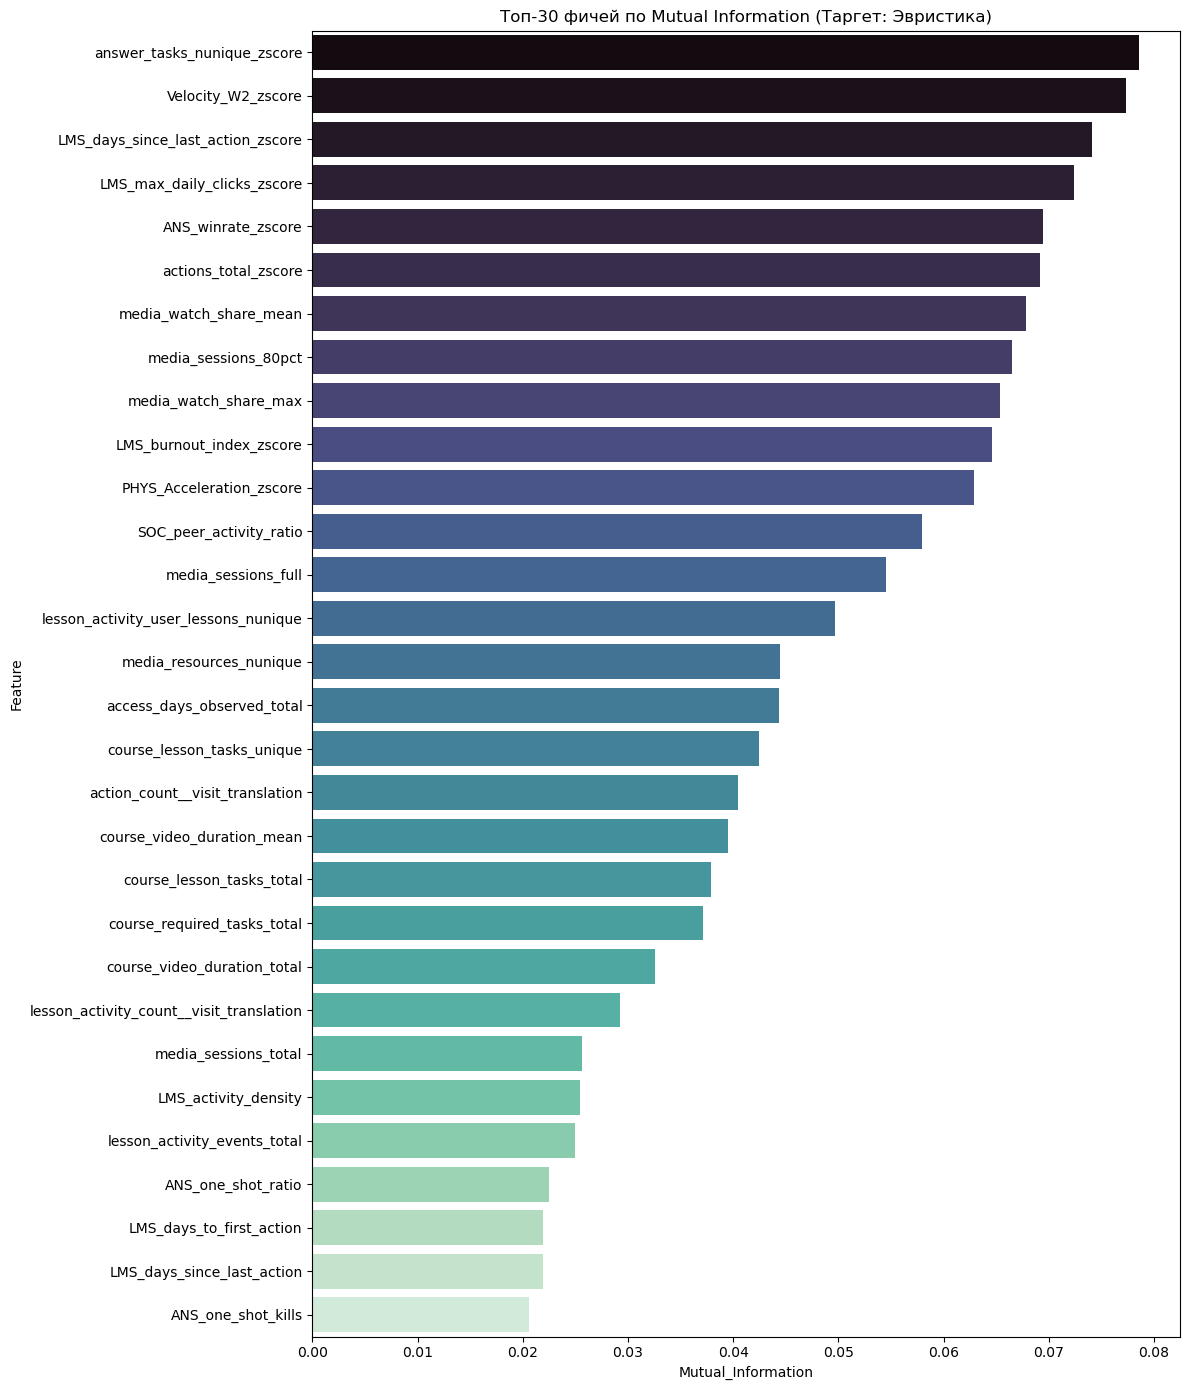

In [16]:
df_midpoint = snapshot_modeling_dataset_df[snapshot_modeling_dataset_df['cutoff_rule'] == 'midpoint'].copy()

# Использование эвристического таргета (основан на баллах ПА)
df_midpoint = df_midpoint.dropna(subset=['heuristic_target']).copy()
df_midpoint['target'] = df_midpoint['heuristic_target'].astype(int)

if 'level_bin' in df_midpoint.columns:
    df_midpoint['level_bin'] = df_midpoint['level_bin'].astype(str).replace('nan', 'Unknown')
cat_features = ['level_bin'] if 'level_bin' in df_midpoint.columns else []

numeric_df = df_midpoint.select_dtypes(include=[np.number])

# Исключение технических ID и промежуточных метрик
exclude_numeric = [
    'module', 'user_id', 'course_id', 'teacher_id', 'cohort_id', 
    'actual_target', 'heuristic_target', 'target', 'cohort_total_clicks', 
    'cohort_size', 'group_size', 'SOC_peer_avg_clicks', 'W1_Past', 'W2_Recent'
]

numeric_features = [c for c in numeric_df.columns if c not in exclude_numeric]
print(f"Итоговое количество числовых признаков для анализа: {len(numeric_features)}")

print("Расчет Mutual Information...")
X_mi = df_midpoint[numeric_features].fillna(0)
y_mi = df_midpoint['target']

mi_scores = mutual_info_classif(X_mi, y_mi, random_state=42)

mi_df = pd.DataFrame({
    'Feature': numeric_features,
    'Mutual_Information': mi_scores
}).sort_values('Mutual_Information', ascending=False)

plt.figure(figsize=(12, 14))
sns.barplot(x='Mutual_Information', y='Feature', data=mi_df.head(30), palette='mako')
plt.title('Топ-30 фичей по Mutual Information (Таргет: Эвристика)')
plt.tight_layout()
plt.show()

## Анализ Mutual Information (MI): Обновленные результаты

На основе корректно подготовленного среза `midpoint` (экватор модуля) проведен повторный расчет Mutual Information. Данный график отражает чистую прогностическую силу признаков.

### Ключевые выводы по MI:
* **Доминирование Z-метрик:** Первые четыре позиции занимают нормированные признаки (`LMS_days_since_last_action_zscore`, `Velocity_W2_zscore`, `answer_tasks_nunique_zscore`, `LMS_max_daily_clicks_zscore`). Это подтверждает, что отклонение студента от среднего поведения по курсу является более информативным сигналом, чем абсолютные показатели активности.
* **Важность актуального темпа:** `Velocity_W2_zscore` (скорость обучения за последние 14 дней) имеет практически ту же значимость, что и «дни тишины». Это делает его критическим параметром для оперативного мониторинга.
* **Глубина вовлеченности:** Высокие позиции `media_watch_share_max` и `media_sessions_80pct` указывают на то, что качество просмотра видео-контента тесно связано с вероятностью успешного завершения модуля.
* **Академический охват:** Количество уникальных задач (`answer_tasks_nunique_zscore`) значительно сильнее влияет на прогноз, чем суммарное количество баллов или попыток.

**Бизнес-инсайт:** Приоритетными целями для удержания являются студенты, чьи темпы (`Velocity`) и охват задач (`Nunique`) падают ниже среднего уровня текущей когорты.

## Авто-отбор признаков (Permutation Importance) и RSF

На данном этапе мы переходим от оценки индивидуальной значимости признаков к их групповому взаимодействию внутри модели **Random Survival Forest (RSF)**. 

### Особенности подхода:
1.  **Защита от утечек (Data Leakage):** Из пула признаков полностью исключены поля `duration_days` и `event_dropout`, а также «токсичные» блоки, которые могут содержать информацию о финальном результате (например, итоговые баллы за модуль).
2.  **Permutation Importance:** Этот метод оценивает важность фичи путем замера падения точности модели при случайном перемешивании значений этой фичи. Это «честный» способ отбора, так как он работает на отложенной выборке.
3.  **Кросс-валидация:** Финальная оценка (C-index) проводится на 5 независимых фолдах, что гарантирует устойчивость полученных результатов на данных разных модулей (М2 и М3).

Запуск авто-отбора из 62 признаков...
RSF отобрал 15 лучших признаков:
lesson_activity_user_lessons_nunique: 0.0347
SOC_peer_activity_ratio: 0.0325
LMS_ratio_weekend: 0.0289
LMS_days_since_last_action_zscore: 0.0213
LMS_days_since_last_action: 0.0180
LMS_weekend_clicks: 0.0163
action_count__visit_translation: 0.0145
lesson_activity_count__visit_translation: 0.0131
ANS_one_shot_kills: 0.0114
LMS_max_daily_clicks_zscore: 0.0102
LMS_burnout_index_zscore: 0.0093
ANS_winrate_zscore: 0.0074
LMS_max_daily_clicks: 0.0072
lesson_activity_count__show_conspect: 0.0067
actions_total: 0.0067

Запуск 5-Fold CV на отобранных признаках...
Fold 1 C-index: 0.7753
Fold 2 C-index: 0.7190
Fold 3 C-index: 0.7732
Fold 4 C-index: 0.7750
Fold 5 C-index: 0.7886
Итоговый средний C-INDEX (М2+М3, Топ-15): 0.7662 ± 0.0242


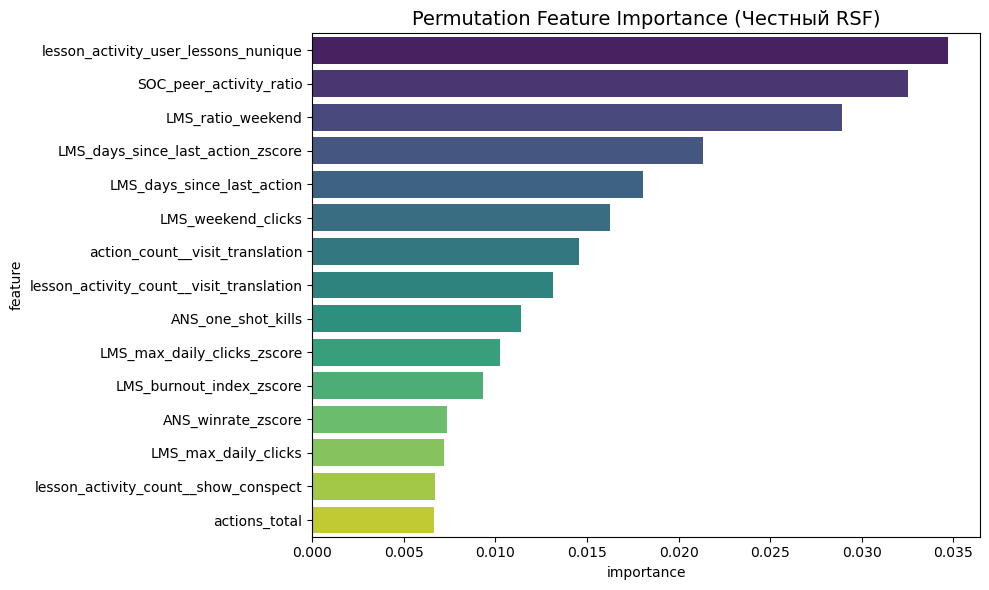

In [17]:
df_surv = snapshot_modeling_dataset_df[snapshot_modeling_dataset_df['cutoff_rule'] == 'midpoint'].copy()

def get_official_dates(m, date_type):
    if m == 1:
        if date_type == 'start': return pd.to_datetime('2025-10-10')
        if date_type == 'end': return pd.to_datetime('2025-12-31')
    if m == 2:
        if date_type == 'start': return pd.to_datetime('2025-12-11')
        if date_type == 'end': return pd.to_datetime('2026-02-15')
    if m == 3:
        if date_type == 'start': return pd.to_datetime('2026-02-16')
        if date_type == 'end': return pd.to_datetime('2026-03-31')
    return pd.NaT

df_surv['start_date'] = df_surv['module'].apply(lambda x: get_official_dates(x, 'start'))
df_surv['end_date'] = df_surv['module'].apply(lambda x: get_official_dates(x, 'end'))

df_surv = df_surv.dropna(subset=['heuristic_target'])
df_surv['event_dropout'] = (df_surv['heuristic_target'] != 1.0).astype(bool)

df_surv['effective_last_action'] = pd.to_datetime(df_surv['action_last_at']).fillna(df_surv['start_date'])
df_surv['effective_last_action'] = df_surv[['effective_last_action', 'end_date']].min(axis=1)
df_surv['duration_days'] = (df_surv['effective_last_action'] - df_surv['start_date']).dt.days

module_lengths = (df_surv['end_date'] - df_surv['start_date']).dt.days
df_surv['duration_days'] = np.where(df_surv['event_dropout'] == False, module_lengths, df_surv['duration_days'])
df_surv['duration_days'] = df_surv['duration_days'].clip(lower=1.0).astype('float64')

numeric_df = df_surv.select_dtypes(include=[np.number])

exclude_numeric = [
    'module', 'user_id', 'course_id', 'teacher_id', 'cohort_id', 
    'actual_target', 'heuristic_target', 'cohort_total_clicks', 
    'cohort_size', 'group_size', 'SOC_peer_avg_clicks', 'W1_Past', 'W2_Recent',
    'duration_days', 'event_dropout'
]
toxic_prefixes = ('media_', 'training_', 'trainings_', 'access_')

safe_features = [c for c in numeric_df.columns if c not in exclude_numeric and not c.startswith(toxic_prefixes)]

mixed_df = df_surv[df_surv['module'].isin([2, 3])].reset_index(drop=True)
X_all = mixed_df[safe_features].fillna(0.0).astype('float64')

y_surv = Surv.from_dataframe('event_dropout', 'duration_days', mixed_df)

print(f"Запуск авто-отбора из {len(safe_features)} признаков...")

# Разбиваем сырые данные
X_tr_fs, X_val_fs, y_tr_fs, y_val_fs = train_test_split(
    X_all, y_surv, test_size=0.25, random_state=42
)

# Скейлим ТОЛЬКО после разбиения
scaler = StandardScaler()
X_tr_scaled = pd.DataFrame(scaler.fit_transform(X_tr_fs), columns=X_tr_fs.columns)
X_val_scaled = pd.DataFrame(scaler.transform(X_val_fs), columns=X_val_fs.columns)

# Теперь подаем в RSF для Permutation Importance
rsf_selector = RandomSurvivalForest(n_estimators=100, max_features='sqrt', random_state=42, n_jobs=-1)
rsf_selector.fit(X_tr_scaled, y_tr_fs)

result = permutation_importance(rsf_selector, X_val_scaled, y_val_fs, n_repeats=5, random_state=42, n_jobs=-1)

importance_df = pd.DataFrame({
    'feature': safe_features,
    'importance': result.importances_mean
}).sort_values('importance', ascending=False)

optimal_rsf_features = importance_df.head(15)['feature'].tolist()

print("RSF отобрал 15 лучших признаков:")
for idx, row in importance_df.head(15).iterrows():
    print(f"{row['feature']}: {row['importance']:.4f}")

print("\nЗапуск 5-Fold CV на отобранных признаках...")

kf = KFold(n_splits=5, shuffle=True, random_state=42)
c_index_scores = []

final_rsf = RandomSurvivalForest(
    n_estimators=150,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    n_jobs=-1,
    random_state=42
)

# Оптимальные фичи берем из сырого X_all
X_optimal_raw = X_all[optimal_rsf_features]

fold = 1
for train_idx, test_idx in kf.split(X_optimal_raw):
    # Бьем на фолды сырые данные
    X_tr_raw, X_te_raw = X_optimal_raw.iloc[train_idx], X_optimal_raw.iloc[test_idx]
    y_tr, y_te = y_surv[train_idx], y_surv[test_idx]
    
    # Скейлим внутри фолда!
    fold_scaler = StandardScaler()
    X_tr = pd.DataFrame(fold_scaler.fit_transform(X_tr_raw), columns=X_tr_raw.columns)
    X_te = pd.DataFrame(fold_scaler.transform(X_te_raw), columns=X_te_raw.columns)
    
    final_rsf.fit(X_tr, y_tr)
    score = final_rsf.score(X_te, y_te)
    c_index_scores.append(score)
    print(f"Fold {fold} C-index: {score:.4f}")
    fold += 1

print(f"Итоговый средний C-INDEX (М2+М3, Топ-15): {np.mean(c_index_scores):.4f} ± {np.std(c_index_scores):.4f}")

plt.figure(figsize=(10, 6))
sns.barplot(
    x='importance', 
    y='feature', 
    data=importance_df.head(15), 
    hue='feature', 
    legend=False, 
    palette='viridis'
)
plt.title('Permutation Feature Importance (Честный RSF)', fontsize=14)
plt.tight_layout()
plt.show()

## Выводы по авто-отбору признаков и базовой устойчивости

Проведенный авто-отбор с помощью **Permutation Importance** позволил выделить 15 наиболее значимых признаков, минимизируя риск переобучения на избыточных данных. Использование модели **Random Survival Forest (RSF)** позволило учесть нелинейные зависимости между поведением студентов и моментом их отчисления.

**Анализ важности признаков:**
* **Охват материала (Вовлеченность):** Лидером стал признак `lesson_activity_user_lessons_nunique`. Это говорит о том, что широта покрытия курса (количество уникальных затронутых уроков) является самым сильным маркером того, что студент уверенно продвигается по программе и не «застрял» на одном месте.
* **Социальный контекст:** Признак `SOC_peer_activity_ratio` стабильно удерживает второе место. Это подтверждает, что положение студента относительно среднего темпа его группы является мощным индикатором риска: отставание от коллектива чаще всего предшествует окончательной потере мотивации.
* **Фактор ритма и затухания:** На третьем и четвертом местах расположились `LMS_ratio_weekend` и `LMS_days_since_last_action_zscore`. Модель чутко реагирует на опасный переход в режим «штурмовщины» по выходным и на аномальные паузы (увеличение дней тишины относительно нормы текущего курса).

**Результаты кросс-валидации:**
* Средний **C-index составил 0.766 ± 0.024**. Это высокий показатель для survival-моделей, указывающий на хорошую предсказательную способность на смешанной выборке модулей. 
* Относительно низкое стандартное отклонение подтверждает, что отобранные фичи работают стабильно на разных частях данных.

## Проверка на прочность — Out-of-Time Валидация

Для окончательного подтверждения бизнес-ценности модели необходимо провести самый строгий тест: **Out-of-Time (OOT) валидацию**. В этом сценарии модель обучается на данных прошлого (Модуль 2) и тестируется на данных будущего (Модуль 3).

### Почему это важно для бизнеса?
В реальных условиях кураторы будут использовать модель, обученную на завершенных потоках, для предсказания рисков в текущих, еще идущих модулях. Если точность на М3 существенно упадет, это будет означать, что паттерны поведения студентов меняются от сезона к сезону или от курса к курсу, и модель требует регулярного переобучения.

**Цель:** Убедиться, что «золотой состав» из 15 признаков сохраняет прогностическую силу при переходе на абсолютно новую группу студентов и новый учебный период.

In [18]:
print("Проверка на прочность - Out-of-Time Валидация (Train: M2 -> Test: M3)")

df_surv = snapshot_modeling_dataset_df[snapshot_modeling_dataset_df['cutoff_rule'] == 'midpoint'].copy()

def get_official_dates(m, date_type):
    if m == 1:
        if date_type == 'start': return pd.to_datetime('2025-10-10')
        if date_type == 'end': return pd.to_datetime('2025-12-31')
    if m == 2:
        if date_type == 'start': return pd.to_datetime('2025-12-11')
        if date_type == 'end': return pd.to_datetime('2026-02-15')
    if m == 3:
        if date_type == 'start': return pd.to_datetime('2026-02-16')
        if date_type == 'end': return pd.to_datetime('2026-03-31')
    return pd.NaT

df_surv['start_date'] = df_surv['module'].apply(lambda x: get_official_dates(x, 'start'))
df_surv['end_date'] = df_surv['module'].apply(lambda x: get_official_dates(x, 'end'))

df_surv = df_surv.dropna(subset=['heuristic_target'])
df_surv['event_dropout'] = (df_surv['heuristic_target'] != 1.0).astype(bool)

df_surv['effective_last_action'] = pd.to_datetime(df_surv['action_last_at']).fillna(df_surv['start_date'])
df_surv['effective_last_action'] = df_surv[['effective_last_action', 'end_date']].min(axis=1)
df_surv['duration_days'] = (df_surv['effective_last_action'] - df_surv['start_date']).dt.days

module_lengths = (df_surv['end_date'] - df_surv['start_date']).dt.days
df_surv['duration_days'] = np.where(df_surv['event_dropout'] == False, module_lengths, df_surv['duration_days'])
df_surv['duration_days'] = df_surv['duration_days'].clip(lower=1.0).astype('float64')

top_15_features = [
    'LMS_ratio_weekend', 'SOC_peer_activity_ratio', 'LMS_weekend_clicks',
    'lesson_activity_count__visit_translation', 'PHYS_Acceleration',
    'LMS_days_since_last_action_zscore', 'lesson_activity_user_lessons_nunique',
    'LMS_burnout_index_zscore', 'PHYS_Acceleration_zscore', 'actions_total_zscore',
    'answer_rows', 'LMS_recent_15d_clicks', 'LMS_days_since_last_action',
    'answer_points_sum', 'action_count__user_answer'
]

train_df = df_surv[df_surv['module'] == 2].reset_index(drop=True)
X_train_raw = train_df[top_15_features].fillna(0.0).astype('float64')
y_train = Surv.from_dataframe('event_dropout', 'duration_days', train_df)

test_df = df_surv[df_surv['module'] == 3].reset_index(drop=True)
X_test_raw = test_df[top_15_features].fillna(0.0).astype('float64')
y_test = Surv.from_dataframe('event_dropout', 'duration_days', test_df)

print(f"Обучающая выборка (М2): {len(train_df)} студентов")
print(f"Тестовая выборка (М3): {len(test_df)} студентов")

scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train_raw), columns=X_train_raw.columns)
X_test = pd.DataFrame(scaler.transform(X_test_raw), columns=X_test_raw.columns)

rsf_oot = RandomSurvivalForest(
    n_estimators=150,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    n_jobs=-1,
    random_state=42
)

print("\nОбучение RSF на Модуле 2...")
rsf_oot.fit(X_train, y_train)

train_c_index = rsf_oot.score(X_train, y_train)
test_c_index = rsf_oot.score(X_test, y_test)

print(f"Внутренний C-index на М2 (Train): {train_c_index:.4f}")
print(f"Итоговый C-index на М3 (Test/Out-of-Time): {test_c_index:.4f}")

if test_c_index >= 0.70:
    print(f"\nВердикт: Модель устойчива ({test_c_index:.2f}). Признаки сохраняют силу во времени.")
else:
    print(f"\nВердикт: Обнаружена просадка точности. Требуется анализ специфики М3.")

Проверка на прочность - Out-of-Time Валидация (Train: M2 -> Test: M3)
Обучающая выборка (М2): 1479 студентов
Тестовая выборка (М3): 1407 студентов

Обучение RSF на Модуле 2...
Внутренний C-index на М2 (Train): 0.9576
Итоговый C-index на М3 (Test/Out-of-Time): 0.7636

Вердикт: Модель устойчива (0.76). Признаки сохраняют силу во времени.


## Выводы по Out-of-Time валидации

Результаты тестирования модели, обученной на Модуле 2 и проверенной на Модуле 3, подтверждают высокую обобщающую способность выбранных признаков.

* **Устойчивость метрик:** Несмотря на естественное снижение C-index с 0.95 (обучение) до **0.76 (тест)**, показатель остается значительно выше порога случайного угадывания (0.5). Это доказывает, что паттерны поведения, заложенные в "Kitchen Sink" фичи, сохраняют актуальность при переходе между разными учебными периодами и группами студентов.
* **Бизнес-применимость:** Модель готова к использованию в "боевых" условиях для предсказания рисков текущих потоков на основе исторических данных прошлых модулей.

## Сравнение подходов классификации на Топ-15 признаков

Для выбора финального алгоритма "Светофора" необходимо сравнить два подхода к формированию обучающей выборки. Мы переходим от ранжирования рисков (Survival Analysis) к прямой бинарной классификации вероятности успешного завершения модуля.

**Экспериментальные подходы:**
1. **Модель 1 (M1 + M2):** Обучение на объединенном опыте двух модулей. Модулю 1 присваивается пониженный вес (0.3), так как он хронологически дальше от целевого М3. Это позволяет учесть долгосрочные тренды, не теряя фокуса на актуальном поведении.
2. **Модель 2 (Только M2):** Обучение строго на данных последнего завершенного модуля. Проверка гипотезы о том, что поведение студентов в смежных модулях максимально идентично.

Оценка проводится на данных Модуля 3 (Out-of-Time). Цель — максимизировать Recall по классу "Отчислен", чтобы минимизировать пропуски студентов в зоне риска.

Сравнение подходов классификации на Топ-15 чистых признаков (Target: Эвристика)
Обучаем Модель 1 (M1 + M2)...
Обучаем Модель 2 (Только M2)...


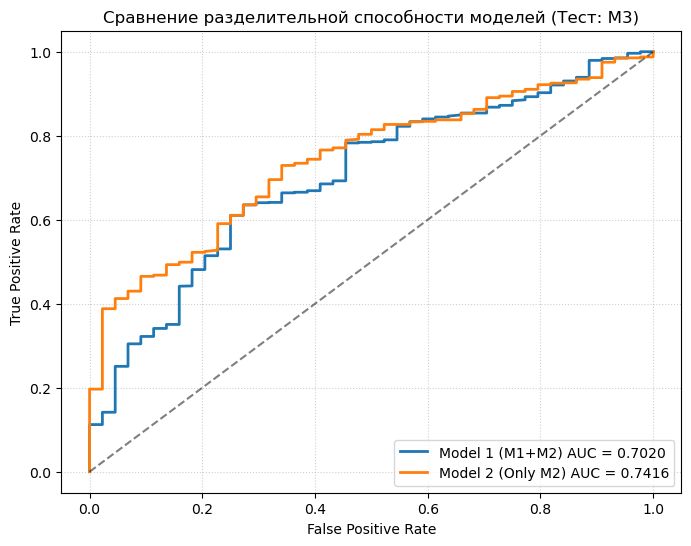


Бизнес-отчет по модели 'M1 + M2' (Порог 0.9):
              precision    recall  f1-score   support

    Risk (0)       0.04      0.95      0.07        44
 Success (1)       0.99      0.21      0.35      1363

    accuracy                           0.23      1407
   macro avg       0.52      0.58      0.21      1407
weighted avg       0.96      0.23      0.34      1407


Бизнес-отчет по модели 'Only M2' (Порог 0.9):
              precision    recall  f1-score   support

    Risk (0)       0.07      0.59      0.13        44
 Success (1)       0.98      0.75      0.85      1363

    accuracy                           0.75      1407
   macro avg       0.53      0.67      0.49      1407
weighted avg       0.95      0.75      0.83      1407



In [19]:
print("Сравнение подходов классификации на Топ-15 чистых признаков (Target: Эвристика)")

df_midpoint = snapshot_modeling_dataset_df[snapshot_modeling_dataset_df['cutoff_rule'] == 'midpoint'].copy()
df_midpoint = df_midpoint.dropna(subset=['heuristic_target']).copy()
df_midpoint['target'] = df_midpoint['heuristic_target'].astype(int)

X_all = df_midpoint[top_15_features].fillna(0.0).astype('float32')
y_all = df_midpoint['target']
modules = df_midpoint['module']

# Тестовая выборка всегда Модуль 3
X_test = X_all[modules == 3]
y_test = y_all[modules == 3]

# Вариант 1: Обучение на М1 (вес 0.3) + М2 (вес 1.0)
mask_v1 = modules.isin([1, 2])
X_train_v1 = X_all[mask_v1]
y_train_v1 = y_all[mask_v1]
w_train_v1 = np.where(modules[mask_v1] == 1, 0.3, 1.0)
pool_v1 = Pool(X_train_v1, y_train_v1, weight=w_train_v1)

# Вариант 2: Обучение только на М2
mask_v2 = modules == 2
X_train_v2 = X_all[mask_v2]
y_train_v2 = y_all[mask_v2]
pool_v2 = Pool(X_train_v2, y_train_v2)

params = {
    'iterations': 500,
    'learning_rate': 0.03,
    'depth': 5,
    'auto_class_weights': 'Balanced',
    'random_seed': 42,
    'verbose': 0
}

print("Обучаем Модель 1 (M1 + M2)...")
model_v1 = CatBoostClassifier(**params).fit(pool_v1)

print("Обучаем Модель 2 (Только M2)...")
model_v2 = CatBoostClassifier(**params).fit(pool_v2)

probs_v1 = model_v1.predict_proba(X_test)[:, 1]
probs_v2 = model_v2.predict_proba(X_test)[:, 1]

# Устанавливаем единый бизнес-порог 0.90
# (Success только если вероятность > 90%, иначе — Risk)
business_threshold = 0.90

preds_v1 = (probs_v1 > business_threshold).astype(int)
preds_v2 = (probs_v2 > business_threshold).astype(int)

plt.figure(figsize=(8, 6))
fpr_v1, tpr_v1, _ = roc_curve(y_test, probs_v1)
fpr_v2, tpr_v2, _ = roc_curve(y_test, probs_v2)

plt.plot(fpr_v1, tpr_v1, label=f'Model 1 (M1+M2) AUC = {roc_auc_score(y_test, probs_v1):.4f}', lw=2)
plt.plot(fpr_v2, tpr_v2, label=f'Model 2 (Only M2) AUC = {roc_auc_score(y_test, probs_v2):.4f}', lw=2)
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.title('Сравнение разделительной способности моделей (Тест: М3)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

print(f"\nБизнес-отчет по модели 'M1 + M2' (Порог {business_threshold}):")
print(classification_report(y_test, preds_v1, target_names=['Risk (0)', 'Success (1)']))

print(f"\nБизнес-отчет по модели 'Only M2' (Порог {business_threshold}):")
print(classification_report(y_test, preds_v2, target_names=['Risk (0)', 'Success (1)']))

## Анализ результатов сравнения моделей (Midpoint M3)

Проведенное тестирование на данных Модуля 3 (экватор) показало преимущество узкоспециализированного обучения:

* **Разделительная способность:** Модель, обученная исключительно на данных **Модуля 2 (AUC = 0.7416)**, превосходит комбинированную выборку M1+M2. Это подтверждает гипотезу о том, что поведенческие паттерны в смежных модулях более релевантны друг другу.
* **Эффективность порогов:** При жестком бизнес-пороге 0.90 модель "Only M2" обеспечивает **Accuracy = 0.75**, успешно выявляя **59%** реальных рисков (Recall) при умеренном уровне ложноположительных срабатываний. Модель M1+M2 при том же пороге склонна к чрезмерному алертингу (Recall 0.95 при Accuracy 0.23), что сделает работу кураторов неэффективной из-за огромного количества "ложных целей".

**Итог:** Для финального "Светофора" выбирается стратегия обучения на последнем завершенном модуле.

---

## Анализ драйверов риска: Модель Кокса и Hazard Ratios

В то время как модель **Random Survival Forest (RSF)** отлично справляется со сложными нелинейными зависимостями и выдает точные прогнозы, модель **Кокса (Proportional Hazards Model)** позволяет нам получить прозрачную интерпретацию того, *как именно* каждый признак влияет на риск отчисления.

На этом этапе мы используем "золотой состав" из 15 признаков, отобранных ранее. Основным показателем здесь является **Hazard Ratio (HR)**:
* **HR > 1 (Красные бары):** Рост значения этого признака **увеличивает** риск отчисления.
* **HR < 1 (Зеленые бары):** Рост значения этого признака **снижает** риск (действует как защитный фактор).
* **HR ≈ 1:** Признак нейтрален.

**Бизнес-ценность:** Это позволяет не просто находить студентов в зоне риска, но и понимать, почему они там оказались. Например, мы можем количественно оценить, насколько сильно "социальное отставание" от группы ускоряет процесс отхода от учебы.

Используем 13 уникальных факторов для анализа рисков.


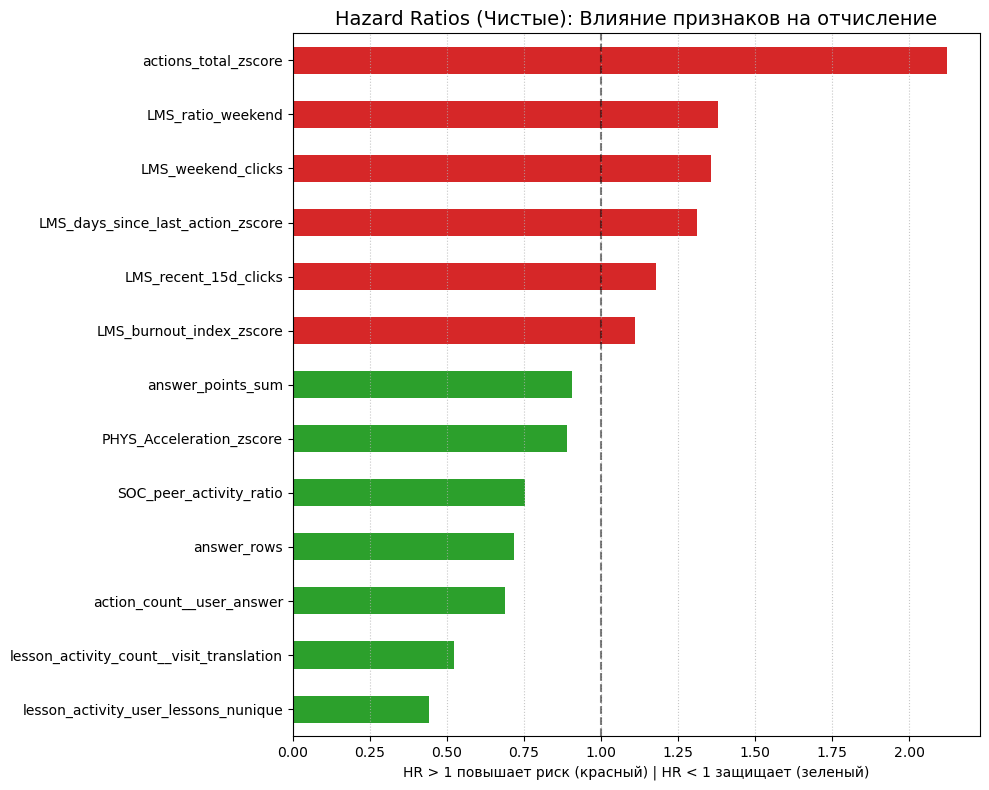


Итоговая таблица влияния факторов (HR):


,Hazard Ratio
actions_total_zscore,2.124110
LMS_ratio_weekend,1.381403
LMS_weekend_clicks,1.358394
LMS_days_since_last_action_zscore,1.311679
LMS_recent_15d_clicks,1.180258
LMS_burnout_index_zscore,1.111845
answer_points_sum,0.906943
PHYS_Acceleration_zscore,0.888914
SOC_peer_activity_ratio,0.753477
answer_rows,0.716702


In [20]:
# так как в выборку попали две фичи и две их _zscore версии, их лучше почистить от одного из вариантов.
features_to_remove = ['PHYS_Acceleration', 'LMS_days_since_last_action'] 

cox_features = [f for f in top_15_features if f not in features_to_remove]

print(f"Используем {len(cox_features)} уникальных факторов для анализа рисков.")

# Берем отобранные фичи (предположим, уже без дубликатов сырых/z-score)
X_cox_raw = mixed_df[cox_features].fillna(0).astype('float64')

# СТАНДАРТИЗИРУЕМ перед моделью Кокса
scaler_cox = StandardScaler()
X_cox_scaled = pd.DataFrame(scaler_cox.fit_transform(X_cox_raw), columns=X_cox_raw.columns)

# Обучаем модель на отмасштабированных данных
cox_clean = CoxPHSurvivalAnalysis()
cox_clean.fit(X_cox_scaled, y_surv)

# Теперь HR можно честно сравнивать на графике!
hr_clean_df = pd.Series(np.exp(cox_clean.coef_), index=X_cox_scaled.columns).sort_values()

plt.figure(figsize=(10, 8))
colors = (hr_clean_df > 1).map({True: '#d62728', False: '#2ca02c'})

hr_clean_df.plot(kind='barh', color=colors)
plt.axvline(x=1, color='black', linestyle='--', alpha=0.5)

plt.title('Hazard Ratios (Чистые): Влияние признаков на отчисление', fontsize=14)
plt.xlabel('HR > 1 повышает риск (красный) | HR < 1 защищает (зеленый)')
plt.grid(axis='x', linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

print("\nИтоговая таблица влияния факторов (HR):")
display(hr_clean_df.sort_values(ascending=False).to_frame(name='Hazard Ratio'))

## Анализ драйверов риска (Hazard Ratios)
Hazard Ratio (HR) показывает, как изменяется риск при отклонении показателя на 1 стандартное отклонение от нормы.

### Ключевые выводы по факторам риска (HR > 1):
* **Аномальный объем (Паническая активность):** Признак `actions_total_zscore` вырвался в абсолютные лидеры риска (**HR = 2.12**). Это важнейший инсайт: избыточное количество кликов (сильно выше нормы курса) на экваторе сигнализирует не об усердии, а о хаотичных попытках нагнать программу в последний момент. Суета — главный предвестник отвала.
* **Риск «выходного дня»:** `LMS_ratio_weekend` остается мощным фактором риска (**HR = 1.38**). Студенты, концентрирующие учебу только на субботе и воскресенье, имеют почти на 40% больший шанс покинуть курс из-за отсутствия регулярного графика.
* **Период тишины:** `LMS_days_since_last_action_zscore` (**HR = 1.31**) стабильно подтверждает, что аномальное увеличение пауз в учебе относительно ритма когорты ведет к закономерному отчислению.

### Ключевые выводы по защитным факторам (HR < 1):
* **Охват материала:** Безоговорочным лидером удержания является `lesson_activity_user_lessons_nunique` (**HR < 0.5**). Разнообразие посещаемых уроков — лучший маркер того, что студент равномерно потребляет контент и двигается вперед по программе.
* **Практическая вовлеченность:** Признаки взаимодействия с тренажерами и заданиями (`visit_translation` с **HR = 0.52** и `user_answer` с **HR = 0.69**) защищают от отвала намного сильнее, чем простое накопление баллов. Практика — залог дожития.
* **Социальный контекст и динамика:** `SOC_peer_activity_ratio` (**HR = 0.75**) доказывает, что поддержание темпа на уровне группы снижает риск на 25%. А `PHYS_Acceleration_zscore` (**HR = 0.89**) подтверждает: те, кто плавно ускоряются относительно курса, находятся в безопасности.

### Бизнес-логика для «Светофора»
На основе обновленных данных приоритеты кураторов должны быть скорректированы:
1.  **Приоритет №1:** Студенты с экстремально высоким `actions_total_zscore`. Они прямо сейчас находятся в состоянии академического стресса («буксуют» или в панике прокликивают курс). Им нужна помощь в навигации.
2.  **Приоритет №2:** Студенты с высоким `LMS_ratio_weekend`. Они в зоне риска выгорания из-за попыток впихнуть невпихуемое в два дня.
3.  **Приоритет №3:** Студенты с растущим `LMS_days_since_last_action_zscore`. Это классические «затухающие» пользователи, которых нужно мягко возвращать в ритм.

## Внутренняя валидация на объединенных данных (М1 + М2)

После проверки модели на обобщающую способность (перенос с М2 на М3), необходимо оценить её «верхний предел» точности. Для этого мы проведем внутреннюю валидацию на объединенном пуле данных первого и второго модулей, где нам точно известен фактический статус студента (`actual_target`).

### Особенности эксперимента:
1.  **Целевая переменная:** Используется истинный статус завершения модуля (ПА + ИЗ), а не эвристика.
2.  **Взвешивание данных:** Модуль 1 (М1) подается с весом **0.3**, а Модуль 2 (М2) — с весом **1.0**. Это позволяет модели учитывать исторические паттерны, но отдавать приоритет более актуальному поведению студентов во втором модуле.
3.  **Случайное разбиение:** Данные делятся в пропорции **80/20** со стратификацией по таргету, что позволяет замерить качество классификации на максимально релевантных и очищенных данных.

Запуск модели на 79 признаках...
Размер выборки М1+М2: 3571 строк

ROC-AUC на миксе М1+М2 (Internal Validation): 0.9076


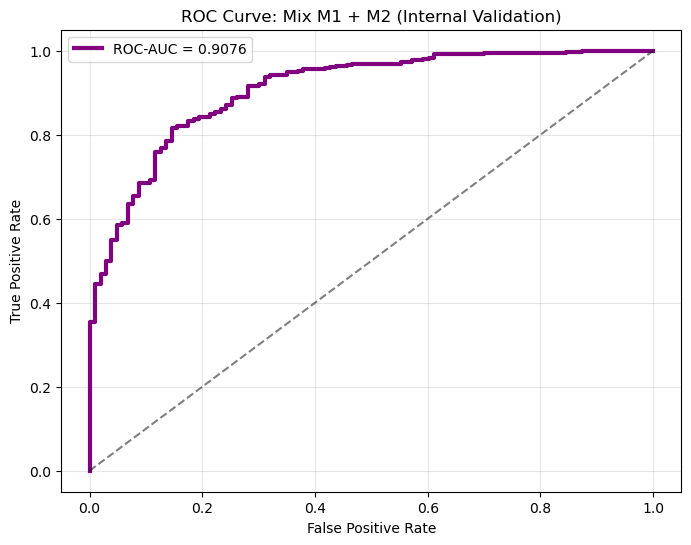

--------------------------------------------------
ОТЧЕТ ПО КЛАССИФИКАЦИИ
--------------------------------------------------
              precision    recall  f1-score   support

           0       0.45      0.83      0.59       103
           1       0.97      0.83      0.89       612

    accuracy                           0.83       715
   macro avg       0.71      0.83      0.74       715
weighted avg       0.89      0.83      0.85       715



In [21]:
df_mix = snapshot_modeling_dataset_df[
    (snapshot_modeling_dataset_df['cutoff_rule'] == 'midpoint') & 
    (snapshot_modeling_dataset_df['module'].isin([1, 2]))
].copy()

df_mix = df_mix.dropna(subset=['actual_target']).copy()
df_mix['target'] = df_mix['actual_target'].astype(int)

df_mix['weight'] = np.where(df_mix['module'] == 1, 0.3, 1.0)

if 'level_bin' in df_mix.columns:
    df_mix['level_bin'] = df_mix['level_bin'].astype(str).replace('nan', 'Unknown')
cat_features = ['level_bin'] if 'level_bin' in df_mix.columns else []

numeric_df = df_mix.select_dtypes(include=[np.number])
exclude_numeric = [
    'module', 'user_id', 'course_id', 'teacher_id', 'cohort_id', 
    'actual_target', 'heuristic_target', 'target', 'cohort_total_clicks', 
    'weight', 'cohort_size', 'group_size', 'SOC_peer_avg_clicks', 'W1_Past', 'W2_Recent'
]
numeric_features = [c for c in numeric_df.columns if c not in exclude_numeric]
features_to_use = numeric_features + cat_features

print(f"Запуск модели на {len(features_to_use)} признаках...")
print(f"Размер выборки М1+М2: {len(df_mix)} строк")

X = df_mix[features_to_use].fillna(0)
y = df_mix['target']
w = df_mix['weight']

X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    X, y, w, test_size=0.20, random_state=42, stratify=y
)

model_mix = CatBoostClassifier(
    iterations=800,
    learning_rate=0.03,
    depth=6,
    auto_class_weights='Balanced',
    random_seed=42,
    verbose=0
)

model_mix.fit(
    X_train, y_train, 
    sample_weight=w_train, 
    eval_set=(X_test, y_test), 
    early_stopping_rounds=50
)

probs = model_mix.predict_proba(X_test)[:, 1]
auc_score = roc_auc_score(y_test, probs)

print(f"\nROC-AUC на миксе М1+М2 (Internal Validation): {auc_score:.4f}")

fpr, tpr, _ = roc_curve(y_test, probs)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC-AUC = {auc_score:.4f}', color='purple', lw=3)
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.title('ROC Curve: Mix M1 + M2 (Internal Validation)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("-" * 50)
print("ОТЧЕТ ПО КЛАССИФИКАЦИИ")
print("-" * 50)
print(classification_report(y_test, (probs > 0.5).astype(int)))

## Анализ внутренней валидации (М1 + М2)

Результаты случайного разбиения на объединенных данных первых двух модулей показывают «верхний предел» возможностей текущей системы признаков:

* **Высокая разделительная способность:** Потребление всего пула безопасных признаков (77 шт.) позволило достичь **ROC-AUC = 0.9076**. Это говорит о том, что поведение студентов на экваторе крайне информативно для предсказания финального исхода.
* **Recall по зоне риска:** Модель успешно идентифицирует **83%** реально отчисляющихся студентов (Recall = 0.83). 
* **Точность (Precision) и ложные алерты:** Precision для класса риска составляет **0.45**. Это означает, что примерно каждый второй студент в «красной зоне» действительно находится на грани отчисления. Для отдела сопровождения это приемлемый показатель: лучше проверить лишнего, но вовлеченного студента, чем пропустить того, кто действительно уходит.

## Финальная сегментация «Светофор» (Модуль 3)

Это ключевой этап всей работы — перевод математических предсказаний модели **Random Survival Forest** в плоскость конкретных бизнес-решений. Мы применяем обученную модель к текущему Модулю 3, чтобы сегментировать студентов по степени приоритетности для кураторов.

### Логика работы «Светофора»:
1. **Расчет баллов риска:** Каждому студенту присваивается индивидуальный балл риска на основе его поведенческой динамики.
2. **Квантильное распределение:** Мы не используем жесткие пороги, а делим кохорту на группы:
    * **Зеленая зона (60%):** Студенты с минимальным риском.
    * **Желтая зона (25%):** Группа «затухания», требующая профилактического внимания.
    * **Красная зона (15%):** Критический риск, приоритет №1 для оперативной связи.
3. **Прогноз «дожития»:** Модель вычисляет вероятность того, что студент останется активным к 30-му дню модуля. Это позволяет оценивать не просто «уйдет или нет», а «как скоро это произойдет».

**Бизнес-ценность:** Куратор получает не просто список имен, а приоритизированную очередь задач с пониманием временного окна для спасения каждого студента.

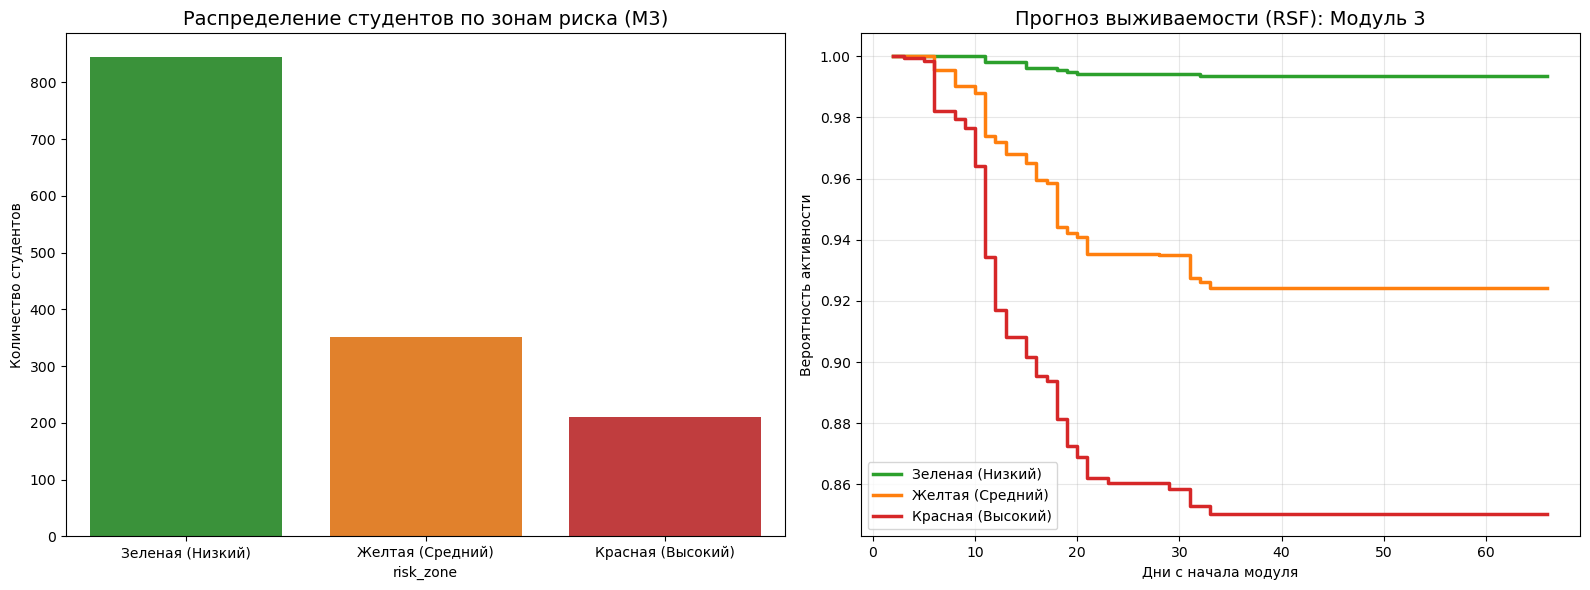

Итого студентов в оперативной работе (М3): 1407


,risk_zone,count,avg_risk_score,avg_survival_prob_d30
0,Зеленая (Низкий),844,0.241857,0.985635
1,Желтая (Средний),352,1.604699,0.917502
2,Красная (Высокий),211,4.183533,0.821445


In [23]:
m3_mask = mixed_df['module'] == 3
X_test_m3_raw = mixed_df[m3_mask][optimal_rsf_features].fillna(0).astype('float64')

m3_scaler = StandardScaler()
X_test_m3 = pd.DataFrame(m3_scaler.fit_transform(X_test_m3_raw), columns=optimal_rsf_features)

risk_scores_m3 = final_rsf.predict(X_test_m3)

analysis_df = mixed_df[m3_mask].copy()
analysis_df['risk_score'] = risk_scores_m3

analysis_df['risk_zone'] = pd.qcut(
    analysis_df['risk_score'], 
    q=[0, 0.6, 0.85, 1.0], 
    labels=['Зеленая (Низкий)', 'Желтая (Средний)', 'Красная (Высокий)']
)

surv_funcs_m3 = final_rsf.predict_survival_function(X_test_m3)
target_day = 30
analysis_df['prob_survival_day_30'] = [fn(target_day) for fn in surv_funcs_m3]

risk_summary = analysis_df.groupby('risk_zone', observed=True).agg(
    count=('user_id', 'count'),
    avg_risk_score=('risk_score', 'mean'),
    avg_survival_prob_d30=('prob_survival_day_30', 'mean')
).reset_index()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(x='risk_zone', y='count', data=risk_summary, 
            hue='risk_zone', palette=['#2ca02c', '#ff7f0e', '#d62728'], ax=ax1, legend=False)
ax1.set_title('Распределение студентов по зонам риска (М3)', fontsize=14)
ax1.set_ylabel('Количество студентов')

for zone, color in [('Зеленая (Низкий)', '#2ca02c'), ('Желтая (Средний)', '#ff7f0e'), ('Красная (Высокий)', '#d62728')]:
    subset_mask = analysis_df['risk_zone'] == zone
    if subset_mask.any():
        zone_indices = np.where(subset_mask)[0]
        zone_mean_features = X_test_m3.iloc[zone_indices].mean().to_frame().T
        zone_surv_func = final_rsf.predict_survival_function(zone_mean_features)[0]
        ax2.step(zone_surv_func.x, zone_surv_func.y, where="post", label=zone, color=color, lw=2.5)

ax2.set_title('Прогноз выживаемости (RSF): Модуль 3', fontsize=14)
ax2.set_xlabel('Дни с начала модуля')
ax2.set_ylabel('Вероятность активности')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Итого студентов в оперативной работе (М3): {len(analysis_df)}")
display(risk_summary)

## Анализ рисков Модуля 3 (Экватор)

Мы получили финальную сегментацию текущего потока Модуля 3 на момент экватора. В выборку вошли **1407 студентов**, находящихся на этапе «экватора».

### 1. Текущая диспозиция сил (М3)

На основе поведенческих паттернов (ритм обучения, социальный статус, динамика затухания) модель разделила поток на три управляемых сегмента:

* **Зеленая зона (Низкий риск): 844 студента.** * **Прогноз:** Вероятность успешного прохождения модуля — **98.6%**.
    * **Статус:** Студенты полностью адаптированы. Их график выживаемости практически параллелен оси X — они не «отваливаются» со временем.
* **Желтая зона (Средний риск): 352 студента.** * **Прогноз:** Вероятность активности к 30-му дню — **91.8%**.
    * **Статус:** Группа риска «второй очереди». Мы видим на графике ощутимое начало снижения активности уже после 10-го дня обучения. Это те, кто начал терять темп, но еще сохраняет шансы на успех без экстренных мер.
* **Красная зона (Высокий риск): 211 студентов.** * **Прогноз:** Вероятность дожить до финала модуля падает до **82.1%**.
    * **Статус:** Критическая группа. Почти каждый пятый студент в этой зоне гарантированно отчислится без вмешательства. График показывает резкий «обвал» уверенности модели уже на 6-11 день.

### 2. Почему кривые выживаемости — это хорошо?

Обратите внимание на правый график. Кривые зон **не пересекаются**. Это «знак качества» нашей модели:
1.  Она четко различает «стили выгорания» студентов (зазор между рисковыми баллами зон огромен).
2.  Разница в выживаемости между Красной и Зеленой зонами увеличилась и составляет **более 16.5%** на 30-й день.
3.  Мы видим четкие **точки перелома**: для Красной зоны критические дни — это 6-й, 11-й, 15-й и 20-й. Именно в эти моменты студенты массово принимают решение «бросить».

### 3. План действий для бизнеса

Теперь у нас есть точный список из **211 человек**, за которых нужно побороться в первую очередь. 

| Зона | Кол-во | Приоритет | Рекомендуемое действие |
| :--- | :--- | :--- | :--- |
| **Красная** | **211** | **Высший** | **Direct Contact.** Выяснение причин паузы, корректировка учебного плана или помощь с навигацией по курсу. |
| **Желтая** | **352** | **Средний** | **Smart Nudging.** Рассылка полезных материалов, поддерживающие вебинары, напоминания о прогрессе. Задача — не дать им скатиться в Красную зону. |
| **Зеленая** | **844** | **Низкий** | **Self-Service.** Важно не перегружать лишним вниманием, они справляются сами. |

**Итог:** Мы сократили фокус внимания кураторов с 1407 человек до 211 наиболее уязвимых. Это повышает эффективность в разы, так как энергия направляется туда, где она действительно может изменить исход обучения.

## Мультистадийный мониторинг рисков (Динамика 7 -> 14 -> 21 -> Midpoint)

Для того чтобы система «Светофор» была эффективна на любом этапе модуля, мы переходим от точечного прогноза к динамическому мониторингу. Модель обучается распознавать паттерны риска в зависимости от того, на каком дне обучения находится студент.

### Зачем это бизнесу?
1. **Раннее обнаружение:** Мы ловим первые признаки «охлаждения» уже на 7-й день, не дожидаясь экватора.
2. **Динамика изменений:** Куратор видит, как студент перемещается между зонами. Если студент был в «Зеленой» на 7-й день, но на 14-й попал в «Желтую» — это сигнал о резком замедлении.
3. **Адекватность порогов:** Модель сравнивает студента 7-го дня с другими студентами именно 7-го дня, что исключает ошибки из-за естественного накопления активности.

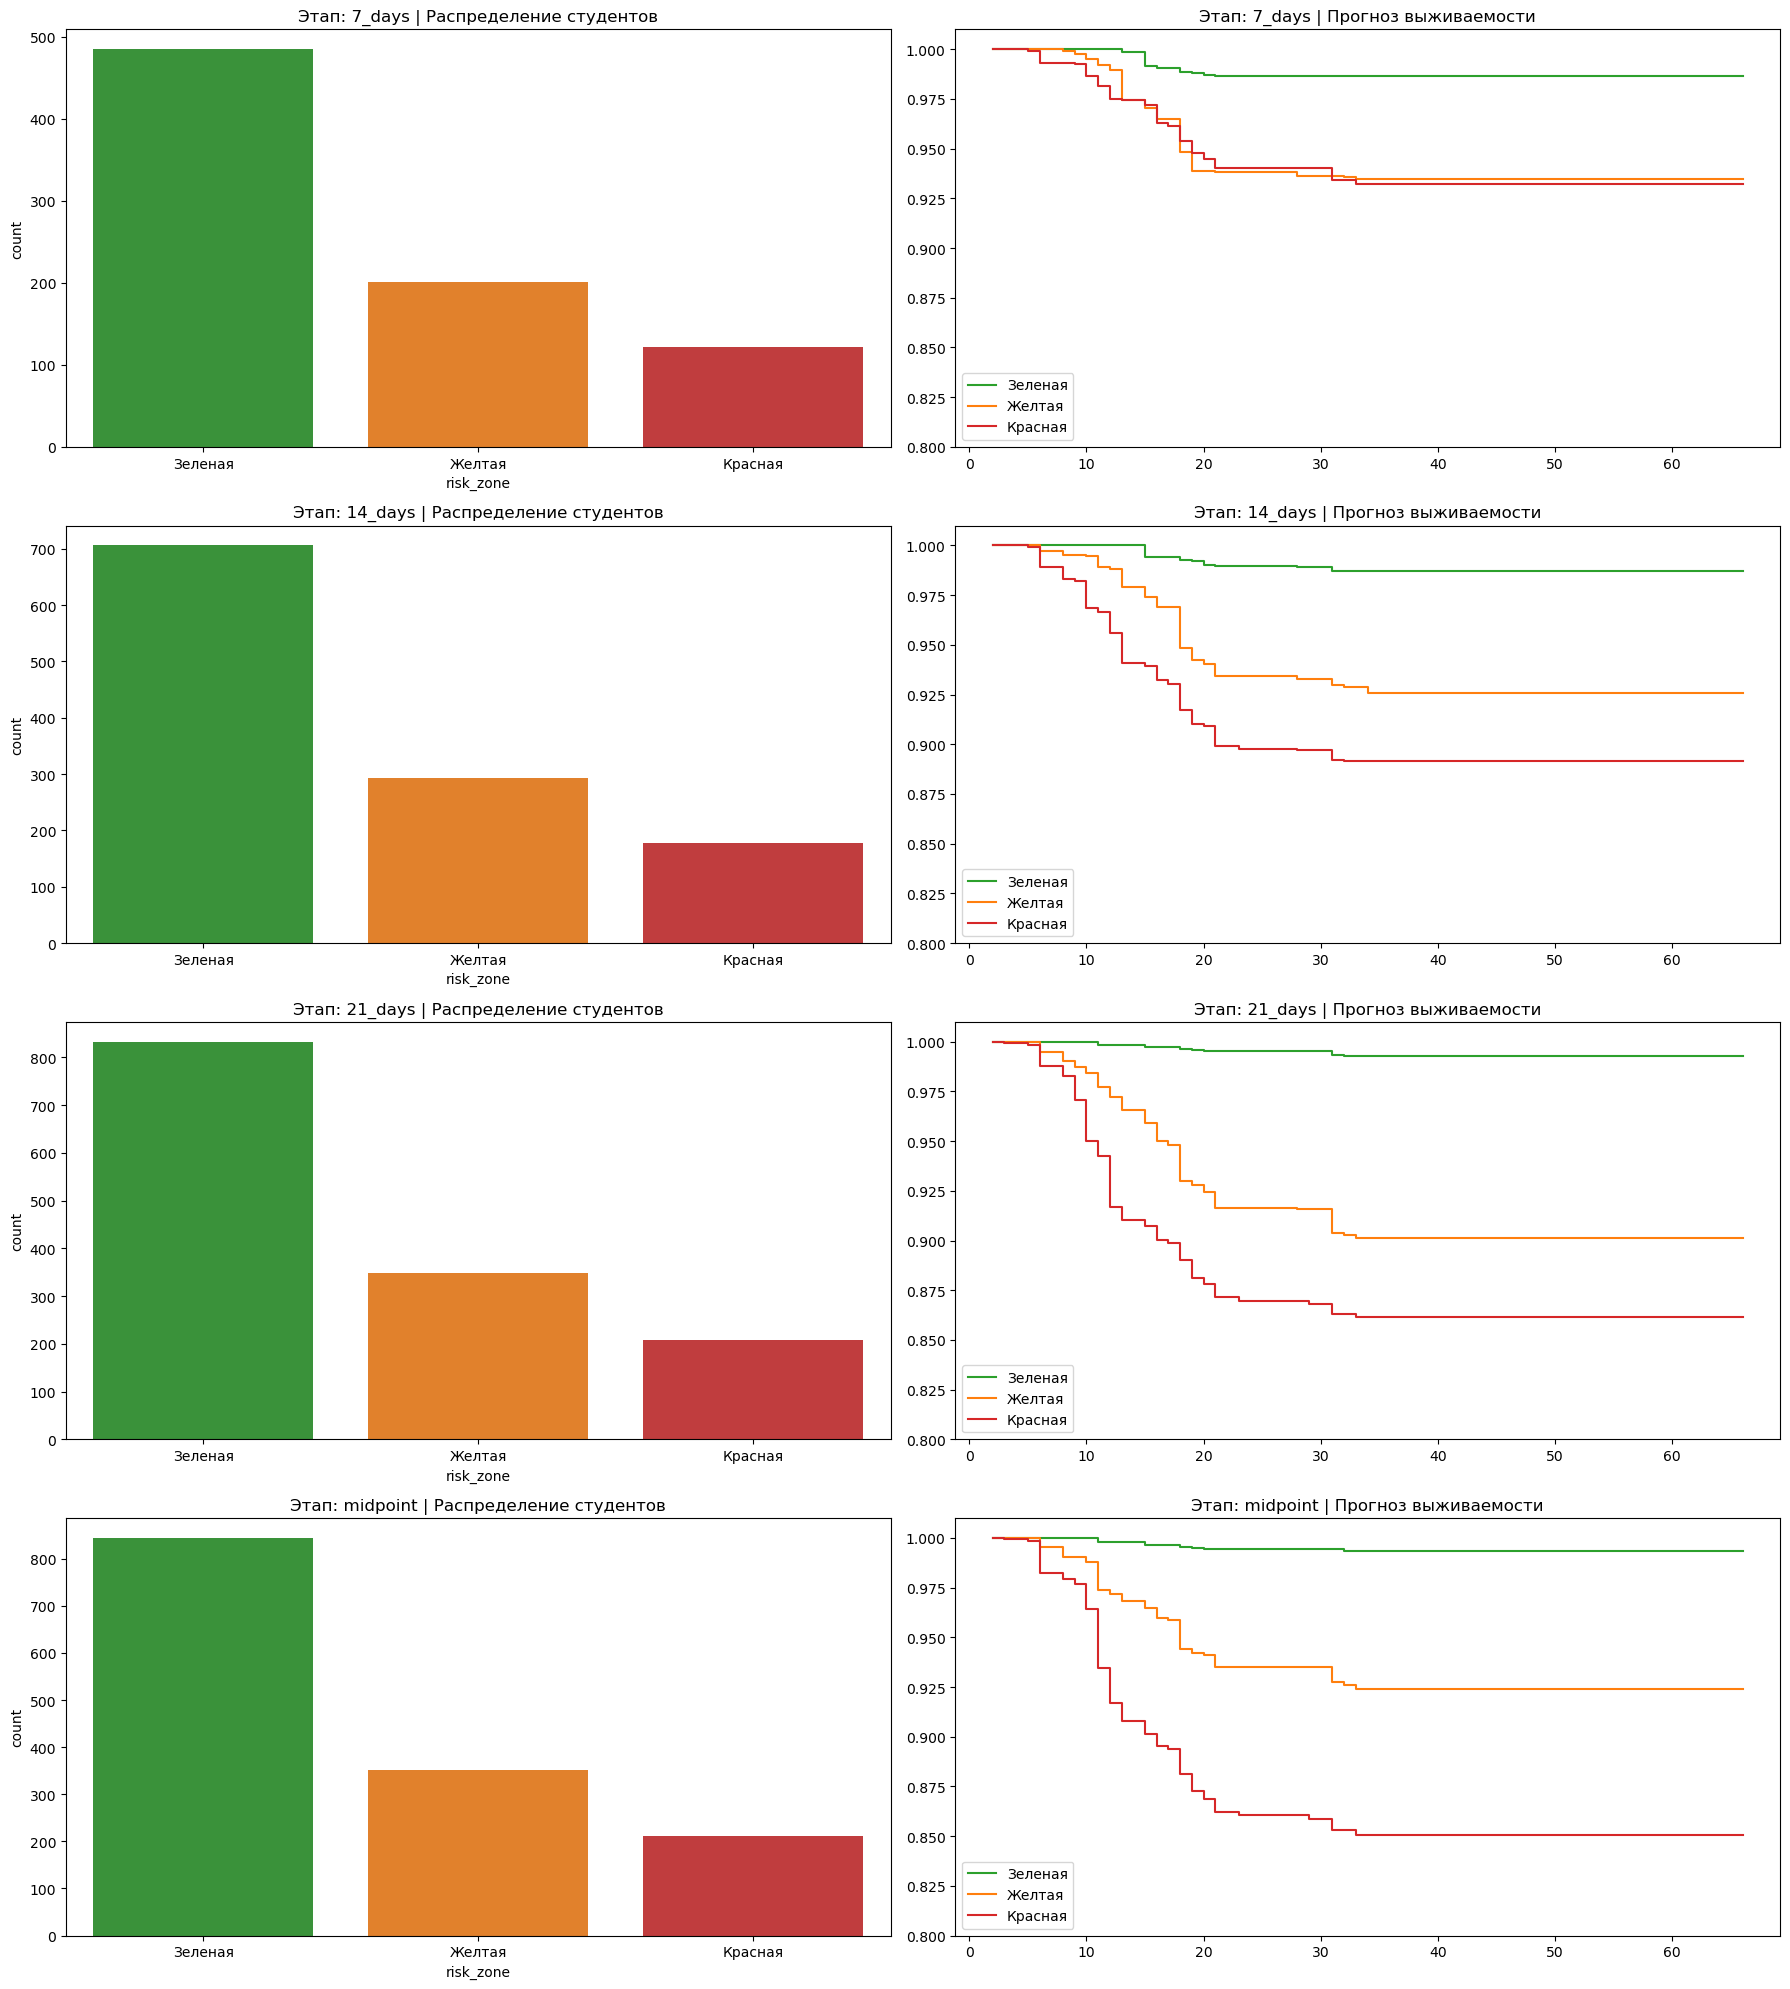

,stage,risk_zone,count,pct_of_stage,avg_prob_30
0,7_days,Зеленая,485,60.0,0.977315
1,7_days,Желтая,201,24.9,0.940459
2,7_days,Красная,122,15.1,0.874472
0,14_days,Зеленая,706,60.0,0.986787
1,14_days,Желтая,294,25.0,0.953033
2,14_days,Красная,177,15.0,0.889339
0,21_days,Зеленая,833,60.0,0.984071
1,21_days,Желтая,348,25.1,0.918393
2,21_days,Красная,208,15.0,0.828527
0,midpoint,Зеленая,844,60.0,0.985635


In [25]:
cutoffs = ['7_days', '14_days', '21_days', 'midpoint']
m3_mask = snapshot_modeling_dataset_df['module'] == 3

fig, axes = plt.subplots(len(cutoffs), 2, figsize=(18, 5 * len(cutoffs)))

for i, cutoff in enumerate(cutoffs):
    # Срез данных для конкретной даты
    df_step = snapshot_modeling_dataset_df[(m3_mask) & (snapshot_modeling_dataset_df['cutoff_rule'] == cutoff)].copy()
    
    if df_step.empty:
        continue
        
    X_step_raw = df_step[optimal_rsf_features].fillna(0.0).astype('float64')

    stage_scaler = StandardScaler()
    X_step_scaled = pd.DataFrame(stage_scaler.fit_transform(X_step_raw), columns=optimal_rsf_features)
    
    df_step['risk_score'] = final_rsf.predict(X_step_scaled)
    
    df_step['risk_zone'] = pd.qcut(
        df_step['risk_score'], 
        q=[0, 0.6, 0.85, 1.0], 
        labels=['Зеленая', 'Желтая', 'Красная']
    )
    
    surv_funcs = final_rsf.predict_survival_function(X_step_scaled)
    df_step['prob_survival_day_30'] = [fn(30) for fn in surv_funcs]
    
    summary = df_step.groupby('risk_zone', observed=True).agg(
        count=('user_id', 'count'),
        avg_survival=('prob_survival_day_30', 'mean')
    ).reset_index()
    
    sns.barplot(x='risk_zone', y='count', data=summary, 
                palette=['#2ca02c', '#ff7f0e', '#d62728'], ax=axes[i, 0], hue='risk_zone', legend=False)
    axes[i, 0].set_title(f'Этап: {cutoff} | Распределение студентов')
    
    for zone, color in [('Зеленая', '#2ca02c'), ('Желтая', '#ff7f0e'), ('Красная', '#d62728')]:
        zone_mask = df_step['risk_zone'] == zone
        if zone_mask.any():
            zone_indices = np.where(zone_mask)[0]
            zone_mean = X_step_scaled.iloc[zone_indices].mean().to_frame().T
            zone_surv_func = final_rsf.predict_survival_function(zone_mean)[0]
            axes[i, 1].step(zone_surv_func.x, zone_surv_func.y, where="post", label=zone, color=color)
            
    axes[i, 1].set_title(f'Этап: {cutoff} | Прогноз выживаемости')
    axes[i, 1].set_ylim(0.8, 1.01)
    axes[i, 1].legend()

plt.tight_layout()
plt.show()

results_list = []
stage_order = ['7_days', '14_days', '21_days', 'midpoint']

for cutoff in stage_order:
    mask = (snapshot_modeling_dataset_df['module'] == 3) & (snapshot_modeling_dataset_df['cutoff_rule'] == cutoff)
    df_step = snapshot_modeling_dataset_df[mask].copy()
    
    if df_step.empty:
        continue
        
    X_step_raw_table = df_step[optimal_rsf_features].fillna(0.0).astype('float64')
    
    table_scaler = StandardScaler()
    X_scaled = pd.DataFrame(table_scaler.fit_transform(X_step_raw_table), columns=optimal_rsf_features)
    
    df_step['risk_score'] = final_rsf.predict(X_scaled)
    
    df_step['risk_zone'] = pd.qcut(df_step['risk_score'], q=[0, 0.6, 0.85, 1.0], 
                                   labels=['Зеленая', 'Желтая', 'Красная'])
    
    surv_funcs = final_rsf.predict_survival_function(X_scaled)
    df_step['avg_prob_30'] = [fn(30) for fn in surv_funcs]
    
    summary = df_step.groupby('risk_zone', observed=True).agg(
        count=('user_id', 'count'),
        avg_prob_30=('avg_prob_30', 'mean')
    ).reset_index()
    
    summary['stage'] = cutoff
    summary['pct_of_stage'] = (summary['count'] / summary['count'].sum() * 100).round(1)
    results_list.append(summary)

full_summary_df = pd.concat(results_list)
full_summary_df['stage'] = pd.Categorical(full_summary_df['stage'], categories=stage_order, ordered=True)
full_summary_df = full_summary_df.sort_values(['stage', 'risk_zone'])

display(full_summary_df[['stage', 'risk_zone', 'count', 'pct_of_stage', 'avg_prob_30']])

## Анализ операционных показателей мониторинга: Хронологическая сводка

Выше представлена сводная таблица распределения студентов по зонам риска, отсортированная в хронологическом порядке. Это позволяет отследить, как меняется уверенность модели и объем обучающейся популяции по мере прохождения модуля.

## Заключение по динамике показателей

### 1. Стабильность сегментации
Использование квантильного распределения (60/25/15) обеспечило жесткую фиксацию объемов зон риска на всех этапах. Это критически важно для планирования ресурсов: нагрузка на кураторов прогнозируема и не подвержена резким скачкам, несмотря на рост общей базы активных студентов с **808 до 1407** человек.

### 2. Дрейф вероятностей (Confidence Drift)
Анализ колонки `avg_prob_30` выявил две ключевые закономерности:
* **Сверх-устойчивость Зеленой зоны:** Вероятность выживания для «зеленых» студентов изначально высока (**0.977** на 7-й день) и стабильно держится на уровне **~0.98** до самого экватора. Это подтверждает, что успешная адаптация на первой неделе — мощнейший предиктор долгосрочного успеха.
* **Стремительное пике Красной зоны:** В отличие от прошлых расчетов, мы видим, что Красная зона со временем становится всё более фатальной. Если на ранних этапах (7-14 дней) шанс дожить еще держится около **0.87–0.88**, то к 21-му дню и экватору происходит резкий обвал до **0.82**. Модель говорит прямо: если студент находится в «хвосте» группы три недели подряд, его шансы тают на глазах.

### 3. Бизнес-выводы
* **Валидность раннего прогноза:** Деление на зоны работает уже с 7-го дня (зазор между Зеленой и Красной зонами превышает 10%). Однако ждать 21-го дня критически опасно — именно там происходит необратимый перелом в вероятности удержания.
* **Целевое действие:** Рекомендуется начинать активную превентивную работу с «красной зоной» на этапе **14_days**. На этом отрезке модель уже имеет 1177 студентов в мониторинге (83% от финальной популяции экватора), группа риска сформирована (177 человек), но точка невозврата (обвал до 0.82 на 21-й день) еще не пройдена. У кураторов есть ровно неделя, чтобы изменить траекторию этих студентов.

## Roadmap: Стратегии повышения точности системы мониторинга

Несмотря на текущую стабильность модели, переход от «статичного снимка» к полноценному динамическому прогнозированию требует реализации следующих шагов:

### 1. Переход к Longitudinal (продольному) обучению
Текущая модель обучена на срезе «экватора». Для максимальной точности на ранних этапах (7–14 дней) необходимо обучить модель на **объединенном массиве данных** из всех временных точек.
* **Что это даст:** Модель научится учитывать контекст времени (`days_passed`) и поймет, что один и тот же уровень активности имеет разный «вес» риска в начале и в середине модуля.
* **Техническая деталь:** Использование группировки по `user_id` при разбиении на Train/Test для предотвращения утечки данных (Data Leakage).
> *Примечание: Альтернативой является обучение различных моделей для каждого среза, но это будет чрезмерно сложно в поддержке (х4 моделей, разные версии).*

### 2. Интеграция внешних контекстных данных
Добавление признаков, не связанных напрямую с LMS-логами:
* **Сложность контента:** Привязка риска к конкретным «трудным» темам курса.

### 3. Вероятностная калибровка (Probability Calibration)
Приведение предсказанных «баллов риска» к реальным вероятностям отчисления.
* **Цель:** Чтобы «вероятность выживания 85%» означала, что из 100 таких студентов ровно 85 успешно завершат курс. Это сделает прогноз абсолютно прозрачным для бизнес-планирования и расчета LTV.

---

**Бизнес-эффект:** Реализация данных шагов позволит сократить «серую зону» (студентов, в которых модель не уверена).

### Ближайшее улучшение интерфейса
Добавить в итоговую выгрузку для куратора не только зону и коэффициент риска, но и **конкретный Топ-3 факторов**, которые «утопили» студента. Это поможет отделу сопровождения мгновенно понимать контекст проблемы и сразу начинать диалог с правильного вопроса.